##Data Loading

In [ ]:
!pip install hdbscan

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.6 MB/s eta 0:00:00


In [ ]:
#@title Fix Dependency Issue
# Uninstall potentially conflicting versions first
# !pip uninstall -y numpy scipy gensim fasttext bertopic laserembeddings sentence-transformers

# !pip install numpy==1.26.4 scipy=
# !pip install gensim
# !pip install fasttext
# !pip install laserembeddings
!pip install bertopic
!pip install sentence-transformers
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 35.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
#@title Install Packages
# !pip install arabic-reshaper python-bidi
# !pip install ar_wordcloud
# !pip install transformers
# !pip install stanza
# !pip install -U bertopic
# !pip install -U sentence-transformers
# !pip install -U scikit-learn
# !pip install -U arabert

# import nltk
# # import stanza

# nltk.download('stopwords')
# from nltk.corpus import stopwords

# arabic_stopwords = set(stopwords.words('arabic'))

# english_stopwords = set(stopwords.words('english'))
# combined_stopwords = arabic_stopwords.union(english_stopwords)

# # Download Arabic model once
# # stanza.download('ar', verbose=False)

# # Initialize pipeline for Arabic with NER
# # nlp = stanza.Pipeline('ar', processors='tokenize,ner', use_gpu=True)


In [ ]:
#@title import packages
import numpy as np
import requests
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import DBSCAN
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score
import re
import ast

# For reproducibility
np.random.seed(42)

import pandas as pd
#@title import packages
import numpy as np
import requests
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import random
# import arabic_reshaper
# from bidi.algorithm import get_display
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.cluster import DBSCAN
import numpy as np

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
# import arabic_reshaper
# from bidi.algorithm import get_display
from collections import Counter
import ast
# import arabic_reshaper
# from bidi.algorithm import get_display
# from ar_wordcloud import ArabicWordCloud

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import random
import networkx as nx


In [ ]:
#@title uitlities
import re

def clean_tweet(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+', '', text)            # remove URLs
    text = re.sub(r'@\w+', '', text)                # remove mentions
    text = re.sub(r'#\w+', '', text)                # remove hashtags
    text = re.sub(r'[^ء-يa-zA-Z0-9\s]', ' ', text) # keep Arabic letters, Latin letters, numbers, and spaces only
    text = re.sub(r'\s+', ' ', text)                 # remove extra whitespace
    return text.strip()

def extract_entities_stanza(text):
    if not isinstance(text, str) or text.strip() == "":
        return []
    doc = nlp(text)
    entities = [ent.text for ent in doc.ents]
    return entities


# Save results DataFrame to CSV file
def save_results(results_df, model_name):
    filename = f"{model_name}.csv"
    results_df.to_csv(filename, index=False)
    print(f"Results saved to {filename}")

def print_results_tables(models_results_dict, metric_names=['nmi', 'ami', 'ari']):
    """
    models_results_dict: dict of {model_name: pd.DataFrame with columns ['date', 'nmi', 'ami', 'ari', ...]}
    metric_names: list of metric columns to show
    """
    for model_name, df in models_results_dict.items():
        # Make sure date is datetime.date type
        df['date'] = pd.to_datetime(df['date']).dt.date

        # Pivot each metric to have dates as columns
        metrics_data = {}
        for metric in metric_names:
            metric_series = df.set_index('date')[metric]
            metrics_data[metric] = metric_series

        table_df = pd.DataFrame(metrics_data).T  # transpose for metric rows

        print(f"\n=== Metrics Table for {model_name} ===")
        print(table_df.round(4))




In [ ]:
# @title Define Constants
urls = [
    "https://raw.githubusercontent.com/HasanKhadd0ur/SocialED_datasets/main/npy_data/Event2012.npy"
]
from google.colab import drive
drive.mount('/content/drive')

columns=[ 'tweet_id', 'text', 'event_id', 'words', 'filtered_words', 'entities', 'user_id', 'created_at', 'urls', 'hashtags', 'user_mentions']

Mounted at /content/drive


In [ ]:
#@title process data
# import os
# import pandas as pd

# # Define folder path in your Drive
# folder_path = '/content/drive/MyDrive/Events'

# # List CSV files only
# csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
# dataframes = []

# for label, filename in enumerate(csv_files):
#     file_path = os.path.join(folder_path, filename)
#     try:
#         df = pd.read_csv(file_path)
#         df['event_label'] = label  # Numeric label for each file
#         df['event_filename'] = filename  # Optional: store filename
#         dataframes.append(df)
#     except Exception as e:
#         print(f"Error reading {filename}: {e}")
# merged_df = pd.concat(dataframes, ignore_index=True)

# # Optional: Save to Drive or download
# merged_df.to_csv('/content/drive/MyDrive/merged_labeled_events.csv', index=False)

In [ ]:
#@title Load dataset
df = pd.read_csv("/content/drive/MyDrive/cleaned_merged_labeled_events.csv")

In [ ]:
#@title Data Columns
df.columns

Index(['Tweet ID', 'Tweet Text', 'Type', 'Author Name', 'Author Username',
       'Creation Time', 'Reply Count', 'Retweet Count', 'Quote Count',
       'Like Count', 'View Count', 'Bookmark Count', 'Language',
       'Possibly Sensitive', 'Source', 'Hashtags', 'Tweet URL', 'Media Type',
       'Media URLs', 'External URLs', 'event_label', 'event_filename',
       'Hashtags_str', 'Old Tweet Text', 'Date', 'Block', 'duration_days',
       'duration_hours', 'duration_minutes', 'Named Entities', 'PER', 'ORG',
       'LOC', 'date', 'arabert_embeddings', 'fasttext_embeddings',
       'named_entities_embedding_32d', 'hashtags_embedding_32d',
       'per_embeddings_32d', 'org_embeddings_32d', 'loc_embeddings_32d',
       'mbert_embeddings', 'verbs', 'nouns', 'adjectives', 'main_words'],
      dtype='object')

In [ ]:
# @title Ensure Type
# Ensure datetime format
df['Creation Time'] = pd.to_datetime(df['Creation Time'])
# Extract just the date part
df['date'] = df['Creation Time'].dt.date

import ast

def entities_to_list(entities_str):
    if isinstance(entities_str, str):
        try:
            # Safely evaluate the string to a Python list
            entities = ast.literal_eval(entities_str)
            # Ensure it's a list and strip whitespace from each entity
            if isinstance(entities, list):
                return [e.strip() for e in entities]
            else:
                return []
        except (ValueError, SyntaxError):
            return []
    else:
        return []
# convert the embedding fro type str to type ndarray
df['arabert_embeddings']=df['arabert_embeddings'].apply(lambda x: np.fromstring(x.strip('[]'), sep=' '))

# Apply to the Named Entities column
# df['Named Entities'] = df['Named Entities'].apply(entities_to_list)

def clean_hashtag_entry(entry):
    try:
        # Step 1: Flatten if it’s a nested list like [[...]]
        if isinstance(entry, list) and len(entry) == 1 and isinstance(entry[0], list):
            entry = entry[0]

        # Step 2: Join everything into one string
        if isinstance(entry, list):
            entry = ''.join(entry)

        # Step 3: Remove outer brackets and unescape
        entry = entry.strip()

        # Step 4: Use regex to extract valid Arabic hashtags (words)
        # This captures Arabic words, hashtags, or unicode escapes
        words = re.findall(r'[\u0600-\u06FF#\w]+', entry)
        return words
    except Exception as e:
        return []
# Apply cleaning function
df['Hashtags'] = df['Hashtags'].apply(clean_hashtag_entry)


In [ ]:
#@title Ensure hashtags are stored as lists instead of comma-separated strings
# def convert_hashtags_to_list(value):
#     if isinstance(value, str):
#         return [tag.strip() for tag in value.split(',') if tag.strip()]
#     return []

# df['Hashtags'] = df['Hashtags'].apply(convert_hashtags_to_list)
# Convert the string of hashtags separated by commas into a list, handling NaN

def hashtags_to_list(hstring):
    if isinstance(hstring, str):
        # Split by comma, strip whitespace
      return [tag.strip().lstrip('#') for tag in hstring.split(',') if tag.strip()]

    else:
        # For NaN or missing values
        return []
df['Hashtags_str'] = df['Hashtags']

# Apply conversion to your hashtag column, e.g., 'Hashtags_str'
df['Hashtags'] = df['Hashtags'].apply(hashtags_to_list)



In [ ]:
# @title Data shape
print(df.shape)


(6998, 46)


In [ ]:
#@title Clean the tweet texts
df['Old Tweet Text'] = df['Tweet Text']
df['Tweet Text'] = df['Tweet Text'].apply(clean_tweet)


In [ ]:
#@title Split the Dataset
from datetime import date

# Define the split date
split_date = date(2025, 5, 7)

# Split the dataset
tuning_df = df[df['date'] < split_date].copy()
evaluation_df = df[df['date'] >= split_date].copy()

# Show the sizes
print(f"🧪 Tuning Set Size     : {tuning_df.shape[0]} messages")
print(f"📈 Evaluation Set Size : {evaluation_df.shape[0]} messages")


🧪 Tuning Set Size     : 934 messages
📈 Evaluation Set Size : 6064 messages


## run this

In [ ]:
#@title Split the Dataset
from datetime import date

# Define the split date
split_date = date(2025, 5, 7)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Split the dataset
tuning_df = df[df['date'] < split_date].copy()
evaluation_df = df[df['date'] >= split_date].copy()


daily_blocks = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))

# Show the sizes
print(f"🧪 Tuning Set Size     : {tuning_df.shape[0]} messages")
print(f"📈 Evaluation Set Size : {evaluation_df.shape[0]} messages")


🧪 Tuning Set Size     : 934 messages
📈 Evaluation Set Size : 6064 messages


In [ ]:
#@title blocks
# Daily blocks from evaluation set (each day = one message block)
daily_blocks = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))

# Show block summary table
block_stats = evaluation_df.groupby(evaluation_df['Date'].dt.date).agg(
    Block_Size=('Tweet ID', 'count'),
    Num_Events=('event_filename', pd.Series.nunique)
).reset_index().rename(columns={'Date': 'Block (Date)'})

print("\n📊 Daily Block Summary:\n")
print(block_stats.to_string(index=False))



📊 Daily Block Summary:

Block (Date)  Block_Size  Num_Events
  2025-05-07          57           8
  2025-05-08          85          10
  2025-05-09          16           7
  2025-05-10          81           8
  2025-05-11          33           8
  2025-05-12         294          10
  2025-05-13         211           8
  2025-05-14         287           8
  2025-05-15         127          10
  2025-05-16          47           9
  2025-05-17         171          12
  2025-05-18         164          12
  2025-05-19         180          16
  2025-05-20         265          19
  2025-05-21        1005          20
  2025-05-22         231          14
  2025-05-23         417          14
  2025-05-24         394          15
  2025-05-25         384          19
  2025-05-26         387           8
  2025-05-27         209           9
  2025-05-28         225           8
  2025-05-29         277          14
  2025-05-30         352          11
  2025-05-31         165           4


In [ ]:
#@title Messages Blocks
from datetime import date

# Ensure Date column is datetime type in original df
df['Date'] = pd.to_datetime(df['Date'])

# Define split date
split_date = pd.to_datetime("2025-05-07")

# Split original dataset
original_tuning_df = df[df['Date'] < split_date].copy()
original_evaluation_df = df[df['Date'] >= split_date].copy()

# Create daily blocks dictionary (group by date)
daily_blocks_original = dict(tuple(original_evaluation_df.groupby(original_evaluation_df['Date'].dt.date)))

# Show sizes
print(f"Original Tuning Set Size   : {original_tuning_df.shape[0]} messages")
print(f"Original Evaluation Set Size : {original_evaluation_df.shape[0]} messages")

# Show some info about blocks
print(f"Number of daily blocks in original evaluation set: {len(daily_blocks_original)}")


Original Tuning Set Size   : 934 messages
Original Evaluation Set Size : 6064 messages
Number of daily blocks in original evaluation set: 25


In [ ]:
#@title  HDBSCAN Sliding Window
from datetime import timedelta
from hdbscan import HDBSCAN
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import numpy as np
import pandas as pd
from tqdm import tqdm

def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='arabert_embeddings'):
    """
    Run HDBSCAN in a sliding window over daily blocks.

    Args:
        daily_blocks (dict): {date: DataFrame}
        window_size (int): Max number of tweets in window
        time_window_days (int): Time-based cutoff in days
        min_cluster_size (int): HDBSCAN min_cluster_size
        min_samples (int): HDBSCAN min_samples
        initial_df (DataFrame): Optional tuning data to preload
        embedding_column (str): Column name with embeddings

    Returns:
        DataFrame with date, NMI, ARI, AMI scores
    """

    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    # Preload window with tuning data
    if initial_df is not None:
        window_embeddings = list(np.vstack(initial_df[embedding_column].apply(np.array).values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = list(pd.to_datetime(initial_df['Date']).tolist())

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].apply(np.array).values)
        block_labels = block['event_label'].values
        block_dates = pd.to_datetime(block['Date']).tolist()

        window_embeddings += list(block_embeddings)
        window_labels += list(block_labels)
        window_dates += list(block_dates)

        # Time filter
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        # Truncate window size
        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        # Clustering
        if len(set(window_labels)) > 1:
            clusterer = HDBSCAN(min_cluster_size=min_cluster_size,
                                min_samples=min_samples,
                                metric='cosine',
                                algorithm='generic')
            predicted = clusterer.fit_predict(np.array(window_embeddings))

            if len(set(predicted)) > 1 and (predicted != -1).any():
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi = ari = ami = 0.0
        else:
            nmi = ari = ami = 0.0

        results.append({
            'date': date,
            'nmi': nmi,
            'ari': ari,
            'ami': ami,
            'num_tweets': len(block)
        })

    return pd.DataFrame(results).sort_values(by='date')


In [ ]:
#@title DBSCAN Sldig Window
from sklearn.cluster import DBSCAN
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
from tqdm import tqdm
import numpy as np
import pandas as pd
from datetime import timedelta

def run_dbscan_sliding(daily_blocks, window_size, time_window_days,
                       eps=0.5, min_samples=5, initial_df=None):
    window_embeddings = []
    window_labels = []
    window_dates = []
    results = []

    # --- Preload window with tuning data ---
    if initial_df is not None:
        window_embeddings = list(np.vstack(initial_df['arabert_embeddings'].apply(np.array).values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = list(pd.to_datetime(initial_df['Date']).to_list())

    # --- Process day by day ---
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running DBSCAN Sliding Window"):
        block_embeddings = np.vstack(block['arabert_embeddings'].apply(np.array).values)
        block_labels = block['event_label'].values
        block_dates = pd.to_datetime(block['Date']).to_list()

        # Add today's data
        window_embeddings += list(block_embeddings)
        window_labels += list(block_labels)
        window_dates += list(block_dates)

        # Filter by time window
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        # Truncate by size
        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        # Run clustering
        if len(set(window_labels)) > 1:
            clusterer = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
            predicted = clusterer.fit_predict(np.array(window_embeddings))

            if len(set(predicted)) > 1 and (predicted != -1).any():
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi = ari = ami = 0.0
        else:
            nmi = ari = ami = 0.0

        results.append({
            'date': date,
            'nmi': nmi,
            'ari': ari,
            'ami': ami,
            'num_tweets': len(block)
        })

    return pd.DataFrame(results).sort_values(by='date')


In [ ]:
#@title 🎨 t-SNE Plot with Clustering Up to a Given Date
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from hdbscan import HDBSCAN
import seaborn as sns
import numpy as np
import pandas as pd

def plot_tsne_hdbscan_clusters_up_to_date(daily_blocks,
                                          date_key,
                                          embedding_column='arabert_embeddings',
                                          min_cluster_size=5,
                                          min_samples=3,
                                          perplexity=30):
    """
    Run HDBSCAN on all tweets up to a given date and visualize t-SNE on tweets of that date.

    Args:
        daily_blocks: dict of {date: DataFrame}
        date_key: datetime.date object for the block to visualize
        embedding_column: which embedding to use
        min_cluster_size: HDBSCAN parameter
        min_samples: HDBSCAN parameter
        perplexity: t-SNE perplexity
    """

    # Filter and combine data from all dates up to the given date
    up_to_date_blocks = {
        d: block for d, block in daily_blocks.items()
        if d <= date_key
    }

    if not up_to_date_blocks:
        print(f"❌ No data found up to {date_key}")
        return

    # Combine all data up to the date
    full_df = pd.concat(up_to_date_blocks.values())
    full_embeddings = np.vstack(full_df[embedding_column].apply(np.array).values)

    # Run HDBSCAN on all embeddings up to this date
    clusterer = HDBSCAN(min_cluster_size=min_cluster_size,
                        min_samples=min_samples,
                        metric='cosine',
                        algorithm='generic')
    full_cluster_ids = clusterer.fit_predict(full_embeddings)

    # Get the indices of the tweets from the target date only
    block_today = daily_blocks.get(date_key)
    if block_today is None or block_today.empty:
        print(f"❌ No tweets found for {date_key}")
        return

    today_indices = full_df.index.get_indexer(block_today.index)
    today_embeddings = full_embeddings[today_indices]
    today_cluster_ids = np.array(full_cluster_ids)[today_indices]

    # Run t-SNE only on today's embeddings
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    tsne_proj = tsne.fit_transform(today_embeddings)

    # Plot
    plt.figure(figsize=(10, 8))
    unique_clusters = np.unique(today_cluster_ids)
    palette = sns.color_palette('tab20', len(unique_clusters))

    sns.scatterplot(x=tsne_proj[:, 0], y=tsne_proj[:, 1],
                    hue=today_cluster_ids,
                    palette=palette,
                    style=today_cluster_ids == -1,
                    s=60,
                    edgecolor='gray')

    plt.title(f"t-SNE: Clusters on {date_key} (up to this day)")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Model

In [ ]:
#@title Create 'filtered_words' Column
import nltk
from nltk.corpus import stopwords
import re

print("Preparing to create the 'filtered_words' column...")

# --- 1. Download and prepare stop words lists ---
try:
    stopwords.words('arabic')
    stopwords.words('english')
    print("✅ Stopwords already available.")
except LookupError:
    print("Downloading stopwords from NLTK...")
    nltk.download('stopwords')
    print("✅ Stopwords downloaded.")

arabic_stopwords = set(stopwords.words('arabic'))
english_stopwords = set(stopwords.words('english'))
combined_stopwords = arabic_stopwords.union(english_stopwords)

# --- 2. Define the filtering function ---
def create_filtered_words(text, stopwords_set):
    """Takes text and returns a list of meaningful words after removing stop words."""
    if not isinstance(text, str):
        return []

    words = text.split()
    # Filter out stop words and very short words (like single letters)
    filtered = [word for word in words if word.lower() not in stopwords_set and len(word) > 1]

    return filtered

# --- 3. Apply the function to your DataFrame ---
print("\nApplying the filter to the 'Tweet Text' column...")
df['filtered_words'] = df['Tweet Text'].apply(lambda text: create_filtered_words(text, combined_stopwords))

print("\n✅ 'filtered_words' column successfully created.")
# Display the first few rows to show the result
print(df[['Tweet Text', 'filtered_words']].head().to_string())

Preparing to create the 'filtered_words' column...
✅ Stopwords already available.

Applying the filter to the 'Tweet Text' column...

✅ 'filtered_words' column successfully created.
                                                                                                                                                                                                                                                                     Tweet Text                                                                                                                                                                                                                                                                                   filtered_words
0                                                                                                                                                                          تصاعد في حوادث الخطف والقتل بحق مدنيين من الطائفة العلوية منذ 13 أيار عقب الإعلان عن ر

In [ ]:
#@title Install Libraries and Import
# Install the Hugging Face transformers library
!pip install transformers -q
import torch
from transformers import BertTokenizer, BertModel
from tqdm import tqdm
import numpy as np


In [ ]:

#@title Load M-BERT Model and Create Embedding Function
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import torch

print("Loading  model...")
# This model is specifically fine-tuned for producing high-quality sentence embeddings
model = SentenceTransformer('sentence-transformers/LaBSE')

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"✅ Model loaded and running on {device}.")


# --- 3. Apply the Function to Your DataFrame ---
# The model.encode() function handles tokenization, batching, and pooling automatically.

# Ensure the 'Tweet Text' column contains strings and handle any missing values
df['Tweet Text'] = df['Tweet Text'].astype(str).fillna('')

# Generate the embeddings
tweet_texts = df['Tweet Text'].tolist()
print(f"Generating mBert embeddings for {len(tweet_texts)} tweets...")
labse_embeddings = model.encode(tweet_texts, show_progress_bar=True, batch_size=64)

# Add the new embeddings as a new column in your dataframe
df['mbert_embeddings'] = list(labse_embeddings)

print("\n✅ M-BERT embeddings have been generated and added to the DataFrame.")
print(f"Shape of the embeddings array: {df['mbert_embeddings'].iloc[0].shape}")


Loading  model...


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2_Dense/pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

✅ Model loaded and running on cpu.
Generating mBert embeddings for 6998 tweets...


Batches:   0%|          | 0/110 [00:00<?, ?it/s]


✅ M-BERT embeddings have been generated and added to the DataFrame.
Shape of the embeddings array: (768,)


In [ ]:
#@title Load Distilled Model and Generate Embeddings
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import torch

# --- 1. Load the Pre-trained Distilled Model ---
model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
print(f"Loading distilled model: {model_name}...")
model = SentenceTransformer(model_name)

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"✅ Model loaded and running on {device}.")


# --- 2. Apply the Model to Your DataFrame ---
# The model.encode() function handles everything automatically.

# Ensure the 'Tweet Text' column contains strings
df['Tweet Text'] = df['Tweet Text'].astype(str).fillna('')

# Generate the embeddings
tweet_texts = df['Tweet Text'].tolist()
print(f"Generating distilled embeddings for {len(tweet_texts)} tweets...")
distilled_embeddings = model.encode(tweet_texts, show_progress_bar=True, batch_size=64)

# Add the new embeddings as a new column to your dataframe
df['distilled_embeddings'] = list(distilled_embeddings)

print("\n✅ Distilled embeddings have been generated and added to the DataFrame.")
print(f"Shape of the embeddings array: {df['distilled_embeddings'].iloc[0].shape}")
# df[['Tweet Text', 'distilled_embeddings']].head()

In [ ]:

#@title Load tuned-BERT Model and Create Embedding Function
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import torch

print("Loading  model...")
# This model is specifically fine-tuned for producing high-quality sentence embeddings
model = SentenceTransformer('/content/drive/MyDrive/models/fine-tuned-labse-event-f')

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"✅ Model loaded and running on {device}.")


# --- 3. Apply the Function to Your DataFrame ---
# The model.encode() function handles tokenization, batching, and pooling automatically.

# Ensure the 'Tweet Text' column contains strings and handle any missing values
df['Tweet Text'] = df['Tweet Text'].astype(str).fillna('')

# Generate the embeddings
tweet_texts = df['Tweet Text'].tolist()
print(f"Generating tBert embeddings for {len(tweet_texts)} tweets...")
labse_embeddings = model.encode(tweet_texts, show_progress_bar=True, batch_size=64)

# Add the new embeddings as a new column in your dataframe
df['tbert_embeddings'] = list(labse_embeddings)

print("\n✅ tuned-BERT embeddings have been generated and added to the DataFrame.")
print(f"Shape of the embeddings array: {df['tbert_embeddings'].iloc[0].shape}")


In [ ]:
#@title fix tweet id issue
print("Adding new 'simple_id' to dataframes...")

# Ensure a clean, sequential index for the new IDs
tuning_df.reset_index(drop=True, inplace=True)
evaluation_df.reset_index(drop=True, inplace=True)

# Create the new simple ID column
tuning_df['Tweet ID'] = tuning_df.index
evaluation_df['Tweet ID'] = evaluation_df.index

print("✅ New IDs added.")
print(f"Tuning df shape: {tuning_df.shape}")
print(f"Evaluation df shape: {evaluation_df.shape}")

Adding new 'simple_id' to dataframes...
✅ New IDs added.
Tuning df shape: (934, 47)
Evaluation df shape: (6064, 47)


In [ ]:
#@title utils
import argparse

import torch
import torch.nn as nn
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
from datetime import datetime
import torch.nn.functional as F

def currentTime():
    return datetime.now().strftime('%Y-%m-%d %H:%M:%S')


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--result_path", type=str, default='res.txt', help="Path for saving experimental results. Default is res.txt.")
    parser.add_argument("--task", type=str, default='DRL', help="Name of the task. Supported names are: DRL, random, semi-supervised, traditional. Default is DRL.")
    parser.add_argument("--layers", nargs='?', default='[256]', help="The number of units of each layer of the GNN. Default is [256]")
    parser.add_argument("--N_pred_hid", type=int, default=64, help="The number of hidden units of layer of the predictor. Default is 512")
    parser.add_argument("--G_pred_hid", type=int, default=16, help="The number of hidden units of layer of the predictor. Default is 512")

    parser.add_argument("--eval_freq", type=float, default=5, help="The frequency of model evaluation")
    parser.add_argument("--mad", type=float, default=0.9, help="Moving Average Decay for Teacher Network")

    parser.add_argument("--Glr", type=float, default=0.0000001, help="learning rate")
    parser.add_argument("--Nlr", type=float, default=0.00001, help="learning rate")
    # To a smaller value, e.g.,
    parser.add_argument("--Ges", type=int, default=50, help="Early Stopping Criterion")
    parser.add_argument("--Nes", type=int, default=2000, help="Early Stopping Criterion")
    parser.add_argument("--device", type=int, default=0)
    parser.add_argument("--Gepochs", type=int, default=50)
    parser.add_argument("--Nepochs", type=int, default=400)

    return parser.parse_known_args()

class EMA:  #Exponential Moving Average
    def __init__(self, beta, epochs):
        super().__init__()
        self.beta = beta
        self.step = 0
        self.total_steps = epochs

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

def get_task(strs):
    tasks = ["DRL","random","semi-supervised","traditional"]
    if len(strs) == 1:
        return "DRL"
    if ("--task" in strs) and len(strs) == 2:
        return "DRL"
    if ("--task" not in strs) or len(strs)!=3:
        return False
    elif strs[-1] not in tasks:
        return False
    else:
        return strs[-1]

def init_weights(m):  #Model parameter initialization
    if type(m) == nn.Linear:
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

def sim(z1, z2):
    z1 = F.normalize(z1)
    z2 = F.normalize(z2)
    return torch.mm(z1, z2.t())

def semi_loss(z1, z2):
    f = lambda x: torch.exp(x / 0.1)
    refl_sim = f(sim(z1, z1))
    between_sim = f(sim(z1, z2))

    return -torch.log(between_sim.diag() / (refl_sim.sum(1) + between_sim.sum(1) - refl_sim.diag()))

def get_loss(h1, h2):
    l1 = semi_loss(h1, h2)
    l2 = semi_loss(h2, h1)

    ret = (l1 + l2) * 0.5
    ret = ret.mean()

    return ret

def update_moving_average(ema_updater, ma_model, current_model):
    for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
        old_weight, up_weight = ma_params.data, current_params.data
        ma_params.data = ema_updater.update_average(old_weight, up_weight)


def set_requires_grad(model, val):
    #set require_grad
    for p in model.parameters():
        p.requires_grad = val

def enumerateConfig(args):
    args_names = []
    args_vals = []
    for arg in vars(args):
        args_names.append(arg)
        args_vals.append(getattr(args, arg))

    return args_names, args_vals


def config2string(args):
    args_names, args_vals = enumerateConfig(args)
    st = ''
    for name, val in zip(args_names, args_vals):
        if val == False:
            continue
        if name not in ['device','root','epochs','isAnneal','dropout','warmup_step','clus_num_iters']:
            st_ = "{}_{}_".format(name, val)
            st += st_

    return st[:-1]


def printConfig(args):
    args_names, args_vals = enumerateConfig(args)
    print(args_names)
    print(args_vals)


In [ ]:
#@title embedder
import numpy as np


import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

# To fix the random seed
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False


class embedder:
    def __init__(self, args):
        self.args = args
        self.hidden_layers = eval(args.layers)

class Encoder(nn.Module):

    def __init__(self, layer_config):
        super().__init__()
        self.stacked_gnn = nn.ModuleList(
            [GCNConv(layer_config[i - 1], layer_config[i]) for i in range(1, len(layer_config))])
        self.stacked_bns = nn.ModuleList(
            [nn.BatchNorm1d(layer_config[i], momentum=0.01) for i in range(1, len(layer_config))])
        self.stacked_prelus = nn.ModuleList([nn.PReLU() for _ in range(1, len(layer_config))])

    def forward(self, x, edge_index):
        for i, gnn in enumerate(self.stacked_gnn):
            x = gnn(x, edge_index, edge_weight=None)
            x = self.stacked_bns[i](x)
            x = self.stacked_prelus[i](x)

        return x

In [ ]:
#@title Craph level
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
np.random.seed(0)
from torch import optim
# To fix the random seed

from scipy.sparse import csr_matrix
import os
import copy
from torch_geometric.nn import global_add_pool, global_mean_pool, global_max_pool, GlobalAttention, Set2Set

class Graph_ModelTrainer(embedder):

    def __init__(self, args, block_num, df, embedding_column='arabert_embeddings'): # Add df parameter
        self.block_num = block_num
        embedder.__init__(self, args)
        self._args = args
        self.df = df # Store the DataFrame
        self.embedding_column = embedding_column
        self._init()

    def _init(self):
        args = self._args
        block_num = self.block_num
        os.environ["CUDA_VISIBLE_DEVICES"] = str(args.device)
        self._device = f'cuda:{args.device}' if torch.cuda.is_available() else "cpu"
        # Check if CUDA is available before setting the device
        if torch.cuda.is_available():
            # torch.cuda.set_device(self._device)
            print("using cuda")
        else:
            print("CUDA not available, using cpu")

         # --- FIX 1: Dynamically get the embedding dimension ---
        if not self.df[self.embedding_column].dropna().empty:
            input_dim = self.df[self.embedding_column].dropna().iloc[0].shape[0]
            print(f"Detected Graph-Level input embedding dimension: {input_dim}")
        else:
            print("Warning: Could not detect embedding dimension, defaulting to 768.")
            input_dim = 768

        layers = [input_dim] + self.hidden_layers # Changed from 300 to 768
        #load data
        self._model = GraphLevel(layers, args).to(self._device)
        self._model.to(self._device)
        self._optimizer = optim.AdamW(params=self._model.parameters(), lr=args.Glr, weight_decay=1e-5)

        # self._loader,self.true_label = get_Graph_Dataset(block_num, self.df) # Pass df to get_Graph_Dataset
        self._loader,self.true_label = get_Node_Dataset(
            self.block_num, self.df, embedding_column=self.embedding_column
        )
        self.train()

        # Normalize the final embeddings if they exist
        if self.all_embeddings.nelement() > 0:
            self.all_embeddings = F.normalize(self.all_embeddings, dim=-1, p=2).detach().cpu().numpy()
        else:
            self.all_embeddings = self.all_embeddings.detach().cpu().numpy()


    def get_embedding(self):
        return self.all_embeddings,self.true_label

    def train(self):
        h_loss = 1e10
        cnt_wait = 0
        # Start Model Training
        print("----Graph-Level Training Start! ----\n")
        self._model.train() # Set model to training mode
        for epoch in range(self._args.Gepochs):
            losses = []
            embs = []
            for batch in self._loader:
                batch = batch.to(self._device)
                emb,loss = self._model(batch)

                # Check for nan loss before backpropagation
                if torch.isnan(loss):
                    print(f"Warning: NaN loss detected at epoch {epoch}. Stopping training for this model.")
                    # Set embeddings to empty and break loops
                    embs = []
                    losses.append(float('nan'))
                    break

                self._optimizer.zero_grad()
                loss.backward()
                self._optimizer.step()
                self._model.update_moving_average()
                losses.append(loss.item())
                embs.extend(emb) # emb is a tensor, extend adds its rows to the list

            if not embs: # If training was stopped due to nan loss
                break

            # # Print loss for monitoring
            # st = '[{}][Epoch {}/{}] Loss: {:.4f}'.format(currentTime(), epoch, self._args.Gepochs, np.mean(np.array(losses)))
            # print(st)

            #Early Stopping Criterion
            if np.mean(np.array(losses)) < h_loss:
                h_loss = np.mean(np.array(losses))
            elif np.mean(np.array(losses)) > h_loss:
                cnt_wait = cnt_wait + 1
            if cnt_wait > 5:
                print("Early stopping triggered.")
                break

        # --- FIX: Use torch.stack for robust tensor creation ---
        if embs: # Check if the list is not empty
            self.all_embeddings = torch.stack(embs)
        else:
            # Handle case where no embeddings were generated
            emb_dim = self.hidden_layers[-1] if self.hidden_layers else 256
            self.all_embeddings = torch.empty((0, emb_dim))

        print("\n----Graph-Level Training Done! ----")

class GraphLevel(nn.Module):
    def __init__(self, layer_config, args):

        self.args = args
        super().__init__()
        self._device = f'cuda:0' if torch.cuda.is_available() else "cpu"
        # self._device = f'cuda:{args.device}' if torch.cuda.is_available() else "cpu"
        #encoder
        # NOTE: Ensure your Encoder class is also using LayerNorm instead of BatchNorm1d
        self.student_encoder = Encoder(layer_config)
        self.teacher_encoder = copy.deepcopy(self.student_encoder)
        self.student_encoder.to(self._device)
        self.teacher_encoder.to(self._device)
        set_requires_grad(self.teacher_encoder, False)
        self.teacher_ema_updater = EMA(args.mad, args.Gepochs)

        rep_dim = layer_config[-1]

        # --- FIX: Replaced BatchNorm1d with LayerNorm for stability ---
        #projection head
        self.student_projector = nn.Sequential(nn.Linear(rep_dim, args.G_pred_hid), nn.LayerNorm(args.G_pred_hid),
                                               nn.PReLU(), nn.Linear(args.G_pred_hid, rep_dim))
        self.student_projector.to(self._device)
        self.student_projector.apply(init_weights)
        self.teacher_projector = copy.deepcopy(self.student_projector)
        set_requires_grad(self.teacher_projector, False)
        #pooling
        self.pool = GlobalAttention(gate_nn=nn.Sequential(
                nn.Linear(rep_dim, rep_dim), nn.LayerNorm(rep_dim), nn.ReLU(), nn.Linear(rep_dim, 1)))

    def reset_moving_average(self):
        del self.teacher_encoder
        self.teacher_encoder = None

    def update_moving_average(self):
        assert self.teacher_encoder is not None, 'teacher encoder has not been created yet'
        update_moving_average(self.teacher_ema_updater, self.teacher_encoder, self.student_encoder)
        update_moving_average(self.teacher_ema_updater, self.teacher_projector, self.student_projector)

    def forward(self,batch):

        batch.to(self._device)
        if torch.isnan(batch.x).any():
          raise ValueError("NaN detected in input features!")

        student = self.student_encoder(batch.x1.to(self._device),batch.edge_index1.to(self._device))

        h1 = self.pool(student,batch.batch)
        h1 = self.student_projector(h1)

        with torch.no_grad(): #stop gradient
            teacher = self.teacher_encoder(batch.x2.to(self._device),batch.edge_index2.to(self._device))
        h2 = self.pool(teacher,batch.batch)
        with torch.no_grad(): #stop gradient
            h2 = self.teacher_projector(h2)

        emb = self.student_encoder(batch.x.to(self._device),batch.edge_index.to(self._device))
        emb = self.pool(emb,batch.batch)

        # --- FIX: Return the raw tensor, do not convert to a list ---
        res_emb = emb
        loss = get_loss(h1,h2)

        return res_emb,loss

In [ ]:
#@title node level
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
np.random.seed(0)
from torch import optim
# from tensorboardX import SummaryWriter
# To fix the random seed
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import os
import copy

class Node_ModelTrainer(embedder):

    def __init__(self, args, block_num, df, embedding_column='arabert_embeddings'): # Add df parameter
        embedder.__init__(self, args)
        self._args = args
        self.block_num = block_num
        self.df = df # Store the DataFrame
        self.embedding_column = embedding_column
        self._init()

    def _init(self):
        block_num = self.block_num
        args = self._args
        os.environ["CUDA_VISIBLE_DEVICES"] = str(args.device)
        self._device = f'cuda:{args.device}' if torch.cuda.is_available() else "cpu"
        # Check if CUDA is available before setting the device
        if torch.cuda.is_available():
            # torch.cuda.set_device(self._device)
            print("using cuda")
        else:
            print("CUDA not available, using cpu")


        if block_num == 0 or block_num == 1:
            args.Nes = 200
        else:
            args.Nes = 2000
        self.true_label = []
         # --- FIX 1: Dynamically get the embedding dimension ---
        if not self.df[self.embedding_column].dropna().empty:
            input_dim = self.df[self.embedding_column].dropna().iloc[0].shape[0]
            print(f"Detected Node-Level input embedding dimension: {input_dim}")
        else:
            print("Warning: Could not detect embedding dimension, defaulting to 768.")
            input_dim = 768

        #load data
        # self._loader,self.true_label = get_Node_Dataset(block_num, self.df) # Pass df to get_Node_Dataset
        self._loader,self.true_label = get_Graph_Dataset(
            self.block_num, self.df, embedding_column=self.embedding_column
        )

        layers = [input_dim] + self.hidden_layers # Changed from 302 to 768
        self._model = NodeLevel(layers, args)
        self._model.to(self._device) # Ensure model is moved to device

        self._optimizer = optim.AdamW(params=self._model.parameters(), lr=args.Nlr, weight_decay=1e-5)
        self.train()
        self.all_embeddings = F.normalize(self.all_embeddings, dim=-1, p=2).detach().cpu().numpy()

    def get_embedding(self):
        return self.all_embeddings,self.true_label

    def train(self):

        loss_t = 1e10
        cnt_wait = 0
        # Start Model Training
        print("----Node-Level Training Start! ----\n")
        self._model.train() # Set model to training mode
        for epoch in range(self._args.Nepochs):
            losses = []
            embs = []
            for batch in self._loader:

                emb,loss = self._model(batch)
                self._optimizer.zero_grad()
                loss.backward()
                self._optimizer.step()
                self._model.update_moving_average()
                losses.append(loss.item())
                embs.extend(emb) # Use extend for list of lists

            # st = '[{}][Epoch {}/{}] Loss: {:.4f}'.format(currentTime(),
                                                        #  epoch, self._args.Nepochs, np.mean(np.array(losses)))
            # print(st)
            #Early Stopping Criterion
            if  np.mean(np.array(losses)) < loss_t:
                loss_t = np.mean(np.array(losses))
            else:
                cnt_wait = cnt_wait + 1
            if cnt_wait > self._args.Nes:
                print("Early Stopping Criterion")
                break

        self.all_embeddings  = torch.tensor(embs)
        print("\n----Node-Level Training Done! ----\n")


class NodeLevel(nn.Module):
    def __init__(self, layer_config, args):
        super().__init__()

        self._device = f'cuda:{args.device}' if torch.cuda.is_available() else "cpu"
        #encoder
        self.student_encoder = Encoder(layer_config=layer_config)
        self.teacher_encoder = copy.deepcopy(self.student_encoder)
        self.student_encoder = self.student_encoder.to(self._device)
        self.teacher_encoder = self.teacher_encoder.to(self._device)
        set_requires_grad(self.teacher_encoder, False)
        self.teacher_ema_updater = EMA(args.mad, args.Nepochs)

        rep_dim = layer_config[-1]

        #projection head
        self.student_projector = nn.Sequential(nn.Linear(rep_dim, args.N_pred_hid), nn.BatchNorm1d(args.N_pred_hid),
                                               nn.PReLU(), nn.Linear(args.N_pred_hid, rep_dim))

        self.student_projector = self.student_projector.to(self._device)

        self.student_projector.apply(init_weights)
        self.teacher_projector = copy.deepcopy(self.student_projector)
        set_requires_grad(self.teacher_projector, False)

    def reset_moving_average(self):
        del self.teacher_encoder
        self.teacher_encoder = None

    def update_moving_average(self):
        assert self.teacher_encoder is not None, 'teacher encoder has not been created yet'
        update_moving_average(self.teacher_ema_updater, self.teacher_encoder, self.student_encoder)
        update_moving_average(self.teacher_ema_updater, self.teacher_projector, self.student_projector)

    def forward(self, batch):
        batch.to(self._device)
        student = self.student_encoder(batch.x1.to(torch.float32).to(self._device),batch.edge_index1.to(self._device))

        h1 = self.student_projector(student)

        with torch.no_grad(): #stop gradient
            teacher = self.teacher_encoder(batch.x2.to(torch.float32).to(self._device),
                                           batch.edge_index2.to(self._device))
        with torch.no_grad(): #stop gradient
            h2 = self.teacher_projector(teacher)

        emb = self.student_encoder(batch.x.to(torch.float32).to(self._device),batch.edge_index.to(self._device))

        emb = emb.detach().cpu().numpy().tolist()

        loss = get_loss(h1,h2)

        return emb,loss

In [ ]:
#@title M
M = [
    85, # 2025-05-08
    101, # 2025-05-09
    182, # 2025-05-10
    215, # 2025-05-11
    509, # 2025-05-12
    720, # 2025-05-13
    1007, # 2025-05-14
    1134, # 2025-05-15
    1181, # 2025-05-16
    1352, # 2025-05-17
    1516, # 2025-05-18
    1696, # 2025-05-19
    1961, # 2025-05-20
    2966, # 2025-05-21
    3197, # 2025-05-22
    3614, # 2025-05-23
    4008, # 2025-05-24
    4392, # 2025-05-25
    4779, # 2025-05-26
    4988, # 2025-05-27
    5213, # 2025-05-28
    5490, # 2025-05-29
    5842, # 2025-05-30
    6007 # 2025-05-31
]

print(M)

[85, 101, 182, 215, 509, 720, 1007, 1134, 1181, 1352, 1516, 1696, 1961, 2966, 3197, 3614, 4008, 4392, 4779, 4988, 5213, 5490, 5842, 6007]


In [ ]:
df.columns

Index(['Tweet ID', 'Tweet Text', 'Type', 'Author Name', 'Author Username',
       'Creation Time', 'Reply Count', 'Retweet Count', 'Quote Count',
       'Like Count', 'View Count', 'Bookmark Count', 'Language',
       'Possibly Sensitive', 'Source', 'Hashtags', 'Tweet URL', 'Media Type',
       'Media URLs', 'External URLs', 'event_label', 'event_filename',
       'Hashtags_str', 'Old Tweet Text', 'Date', 'Block', 'duration_days',
       'duration_hours', 'duration_minutes', 'Named Entities', 'PER', 'ORG',
       'LOC', 'date', 'arabert_embeddings', 'fasttext_embeddings',
       'named_entities_embedding_32d', 'hashtags_embedding_32d',
       'per_embeddings_32d', 'org_embeddings_32d', 'loc_embeddings_32d',
       'mbert_embeddings', 'verbs', 'nouns', 'adjectives', 'main_words',
       'filtered_words'],
      dtype='object')

In [ ]:
#@title process
import numpy as np
import pandas as pd
import networkx as nx
import re
import random
import torch
from torch_geometric.data import Data
from torch_geometric import loader
import time
import copy

def construct_graph_from_df(df, G=None):
    """Constructs a heterogeneous graph using the reliable 'simple_id'."""
    if G is None:
        G = nx.Graph()
    for _, row in df.iterrows():
        # Use simple_id for creating tweet nodes
        tid = 't_' + str(row['simple_id'])
        G.add_node(tid)

        # # Use only the author as the user node
        user_nodes = []
        if pd.notna(row['Author Username']):
            user_nodes.append('u_' + str(row['Author Username']))
        # G.add_nodes_from(user_nodes)

        # Add other node types
        word_nodes = [('w_' + str(each)).lower() for each in row.get('verbs', [])]
        G.add_nodes_from(word_nodes)

        # Add other node types
        nouns_nodes = [('n_' + str(each)).lower() for each in row.get('nouns', [])]
        G.add_nodes_from(nouns_nodes)

        hashtag_nodes = [('h_' + str(each)).lower() for each in row.get('Hashtags', [])]
        G.add_nodes_from(hashtag_nodes)

        # entity_nodes = [('e_' + str(ent)).lower().replace(" ", "_") for ent in row.get('Named Entities', [])]
        # G.add_nodes_from(entity_nodes)

        per_nodes = [('p_' + str(ent)).lower().replace(" ", "_") for ent in row.get('PER', [])]
        G.add_nodes_from(per_nodes)

        loc_nodes = [('l_' + str(ent)).lower().replace(" ", "_") for ent in row.get('LOC', [])]
        # G.add_nodes_from(loc_nodes)

        org_nodes = [('o_' + str(ent)).lower().replace(" ", "_") for ent in row.get('ORG', [])]
        G.add_nodes_from(org_nodes)

        # Add edges from the tweet to all its attributes
        edges = []
        # edges.extend([(tid, each) for each in user_nodes])
        edges.extend([(tid, each) for each in word_nodes])
        edges.extend([(tid, each) for each in nouns_nodes])
        edges.extend([(tid, each) for each in hashtag_nodes])
        # edges.extend([(tid, each) for each in entity_nodes])

        edges.extend([(tid, each) for each in org_nodes])
        # edges.extend([(tid, each) for each in loc_nodes])
        edges.extend([(tid, each) for each in per_nodes])
        G.add_edges_from(edges)
    return G

def get_edge_index(adj):
    """Gets edge set from an adjacency matrix efficiently."""
    rows, cols = np.where(np.triu(adj, 1))
    return [rows.tolist(), cols.tolist()]

def aug_edge_robust(adj, drop_percent=0.1):
    """Perturbs a percentage of edges by removing some and adding others."""
    adj_np, num_nodes = np.array(adj), adj.shape[0]
    if num_nodes <= 1: return adj_np.copy(), adj_np.copy()

    rows, cols = np.where(np.triu(adj_np, 1))
    edges = list(zip(rows, cols))
    num_to_perturb = int(len(edges) * drop_percent)
    if num_to_perturb == 0: return adj_np.copy(), adj_np.copy()

    def perturb(a):
        a_copy = a.copy()
        # Remove edges
        edges_to_remove = random.sample(edges, k=min(num_to_perturb, len(edges)))
        for u, v in edges_to_remove: a_copy[u, v] = a_copy[v, u] = 0
        # Add new random edges
        added_count = 0
        while added_count < num_to_perturb:
            u, v = np.random.randint(0, num_nodes, size=2)
            if u != v and a_copy[u, v] == 0:
                a_copy[u, v] = a_copy[v, u] = 1
                added_count += 1
        return a_copy

    return perturb(adj_np), perturb(adj_np)

def get_data(df_chunk, embedding_column='arabert_embeddings'):
    """Processes a dataframe chunk to create the full graph data structure."""
    if embedding_column not in df_chunk.columns or df_chunk[embedding_column].isnull().any():
        print(f"Warning: Embedding column '{embedding_column}' not found or has nulls. Skipping chunk.")
        return None

    ini_df = df_chunk.set_index('simple_id', drop=False)
    G = construct_graph_from_df(ini_df)

    tweet_nodes = sorted([n for n in G.nodes() if n.startswith('t_')], key=lambda x: int(x[2:]))
    if not tweet_nodes: return None

    tweet_ids = [int(n[2:]) for n in tweet_nodes]
    final_df = ini_df.loc[tweet_ids]

    X = torch.tensor(np.vstack(final_df[embedding_column].values), dtype=torch.float32)
    true_y = torch.tensor(final_df['event_label'].values)

    subgraph = G.subgraph(tweet_nodes)
    adj = nx.to_numpy_array(subgraph, nodelist=tweet_nodes)

    edge_index = get_edge_index(adj)
    aug_adj1, aug_adj2 = aug_edge_robust(adj)
    edge_index1, edge_index2 = get_edge_index(aug_adj1), get_edge_index(aug_adj2)

    return {'x': X, 'y': true_y, 'edge_index': torch.tensor(edge_index, dtype=torch.int64),
            'edge_index1': torch.tensor(edge_index1, dtype=torch.int64),
            'edge_index2': torch.tensor(edge_index2, dtype=torch.int64)}

def getData(df, M_num, embedding_column='arabert_embeddings'):
    """Slices the main dataframe and processes it in chunks."""
    block_df = df if M_num == 0 else df.iloc[M[M_num-1]:M[M_num]] if M_num > 0 and M_num <= len(M) else pd.DataFrame()
    if block_df.empty: return []

    data_chunks, chunk_size = [], 500
    for i in range(0, len(block_df), chunk_size):
        chunk = block_df.iloc[i:i+chunk_size].copy()
        if 'simple_id' not in chunk.columns:
            chunk.reset_index(drop=True, inplace=True)
            chunk['simple_id'] = chunk.index

        processed_chunk = get_data(chunk, embedding_column=embedding_column)
        if processed_chunk: data_chunks.append(processed_chunk)
    return data_chunks

def create_dataloader(message_number, df, data_type, embedding_column='arabert_embeddings'):
    print(f"\nBuilding {data_type}-level social network for message block {message_number}...")
    start_time = time.time()
    data_list = getData(df, message_number, embedding_column=embedding_column)
    dataset, labels = [], []

    if not data_list:
        print(f"Warning: No data chunks were processed for this block.")
        return loader.DataLoader([]), []

    for d in data_list:
        dataset.append(Data(x=d['x'], x1=d['x'], x2=d['x'],
                            edge_index=d['edge_index'], edge_index1=d['edge_index1'],
                            edge_index2=d['edge_index2']))
        labels.extend(d['y'].tolist())

    batch_size = len(dataset) if len(dataset) > 0 else 1
    dataloader = loader.DataLoader(dataset, batch_size=batch_size)
    print(f"Done! It takes {int(time.time() - start_time)} seconds.")
    return dataloader, labels

def get_Graph_Dataset(m_num, df, embedding_column='arabert_embeddings'):
    return create_dataloader(m_num, df, 'graph', embedding_column=embedding_column)

def get_Node_Dataset(m_num, df, embedding_column='arabert_embeddings'):
    return create_dataloader(m_num, df, 'node', embedding_column=embedding_column)

In [ ]:
#@title evaluate
import numpy as np
import os
import time
import random

from sklearn.metrics import normalized_mutual_info_score,adjusted_mutual_info_score,adjusted_rand_score,silhouette_score

def DRL_cluster(all_embeddings,block_num,pred_label):
    para = 0.1
    if block_num == 0:
        print("Evaluating initial message block...")
        start_time = time.time()
        sp = SinglePass(0.87, all_embeddings, 0, pred_label, M[0], None, para, 0, sim=False)
        end_time = time.time()
        run_time = end_time - start_time
        print("Done! " + "It takes "+str(int(run_time))+" seconds.\n")
    else:
        print("Using DRL-Single-Pass to learn threshold...")
        global_step = 0
        agent = PPO([5], 1, continuous=True)
        sp_sim = SinglePass(0.6, all_embeddings, 1, pred_label, M[block_num] - M[block_num - 1], agent, para, M[block_num-1]-2000, sim=True)

        global_step = sp_sim.global_step
        sp = SinglePass(0.6, all_embeddings, 1, pred_label, M[block_num] - M[block_num - 1], agent, para, M[block_num-1]-2000, sim=False)

    return sp.cluster_result,sp.sim_threshold

def random_cluster(all_embeddings,block_num,pred_label):
    threshold = random.uniform(0.6,0.8)
    if block_num == 0:
        print("Evaluating initial message block...")
        start_time = time.time()
        sp = SinglePass(0.87, all_embeddings, 0, pred_label, M[0], None, 0, 0, sim=False)
        end_time = time.time()
        run_time = end_time - start_time
        print("Done! " + "It takes "+str(int(run_time))+" seconds.\n")
        threshold = 0.87
    else:
        print("Evaluating message block...")
        start_time = time.time()
        sp = SinglePass(threshold, all_embeddings, 2, pred_label, M[block_num] - M[block_num - 1], None, 0, 0, sim=False)
        end_time = time.time()
        run_time = end_time - start_time
        print("Done! " + "It takes "+str(int(run_time))+" seconds.\n")
    return sp.cluster_result,threshold

def semi_cluster(all_embeddings,label,block_num,pred_label):
    if block_num == 0:
        print("Evaluating initial message block...")
        start_time = time.time()
        sp = SinglePass(0.87, all_embeddings, 0, pred_label, M[0], None, 0, 0, sim=False)
        end_time = time.time()
        run_time = end_time - start_time
        print("Done! " + "It takes "+str(int(run_time))+" seconds.\n")
        threshold = 0.87
    else:
        print("Evaluating message block...")
        start_time = time.time()
        embeddings = all_embeddings.tolist()
        size = M[block_num] - M[block_num - 1]
        embeddings = embeddings[0:len(embeddings)-int(size*0.9)]
        pre_label = pred_label[0:len(embeddings)]

        size = len(embeddings) - M[block_num - 1]
        embeddings = np.array(embeddings)
        thresholds = [0.6,0.65,0.7,0.75,0.8]
        s1s = []
        for t in thresholds:
            sp = SinglePass(t, embeddings, 2, pre_label, size, None, 0, 0, sim=False)
            true_label = label[0:len(sp.cluster_result)]
            s1 = normalized_mutual_info_score(true_label, sp.cluster_result, average_method='arithmetic')
            s1s.append(s1)
        index = s1s.index(max(s1s))
        sp = SinglePass(thresholds[index], all_embeddings, 2, pred_label, M[block_num] - M[block_num - 1], None, 0, 0, sim=False)
        end_time = time.time()
        run_time = end_time - start_time
        print("Done! " + "It takes "+str(int(run_time))+" seconds.\n")
        threshold = thresholds[index]
    return sp.cluster_result,threshold

def NMI_cluster(all_embeddings,label,block_num,pred_label):
    if block_num == 0:
        print("Evaluating initial message block...")
        start_time = time.time()
        sp = SinglePass(0.87, all_embeddings, 0, pred_label, M[0], None, 0, 0, sim=False)
        end_time = time.time()
        run_time = end_time - start_time
        print("Done! " + "It takes "+str(int(run_time))+" seconds.\n")
        threshold = 0.87
    else:
        print("Evaluating message block...")
        start_time = time.time()
        thresholds = [0.6,0.65,0.7,0.75,0.8]
        s1s = []
        for t in thresholds:
            sp = SinglePass(t, all_embeddings, 2, pred_label, M[block_num] - M[block_num - 1], None, 0, 0, sim=False)
            s1 = normalized_mutual_info_score(label, sp.cluster_result, average_method='arithmetic')
            s1s.append(s1)
        index = s1s.index(max(s1s))
        sp = SinglePass(thresholds[index], all_embeddings, 2, pred_label, M[block_num] - M[block_num - 1], None, 0, 0, sim=False)
        end_time = time.time()
        run_time = end_time - start_time
        print("Done! " + "It takes "+str(int(run_time))+" seconds.\n")
        threshold = thresholds[index]
    return sp.cluster_result,threshold

def evaluate(all_embeddings,label,block_num,pred_label,result_path,task):
    if task == "DRL":
        y_pred,threshold = DRL_cluster(all_embeddings,block_num,pred_label)
    elif task == "random":
        y_pred,threshold = random_cluster(all_embeddings,block_num,pred_label)
    elif task == "semi-supervised":
        y_pred,threshold = semi_cluster(all_embeddings,label,block_num,pred_label)
    elif task == "traditional":
        y_pred,threshold = NMI_cluster(all_embeddings,label,block_num,pred_label)

    #NMI
    s1 = normalized_mutual_info_score(label, y_pred, average_method='arithmetic')
    #AMI
    s2 = adjusted_mutual_info_score(label, y_pred, average_method='arithmetic')
    #ARI
    s3 = adjusted_rand_score(label, y_pred)

    print('** Theta:{:.2f} **\n'.format(threshold))
    print('** NMI: {:.2f} **\n'.format(s1))
    print('** AMI: {:.2f} **\n'.format(s2))
    print('** ARI: {:.2f} **\n'.format(s3))
    result = '\nmessage_block_'+str(block_num)+'\nthreshold: {:.2f} '.format(threshold)+'\n** NMI: {:.2f} **\n'.format(s1) + '** AMI: {:.2f} **\n'.format(s2) + '** ARI: {:.2f} **\n'.format(s3)

    if not os.path.exists(result_path) :
        pass
    else:
        with open(result_path,encoding='utf-8') as file:
            content=file.read()
        result = content.rstrip() + result
    file = open(result_path, mode='w')
    file.write(result)
    file.close()
    return y_pred
    import hdbscan
import numpy as np

def run_hdbscan_clustering(embeddings, min_cluster_size=15, min_samples=5):
    """
    Performs clustering using the HDBSCAN algorithm.

    Args:
        embeddings (np.ndarray): The embeddings to cluster.
        min_cluster_size (int): The minimum size of a cluster. This is the most
                                important parameter to tune.
        min_samples (int): A measure of how conservative the clustering is.

    Returns:
        np.ndarray: An array of predicted cluster labels.
    """
    print(f"\nRunning HDBSCAN with min_cluster_size={min_cluster_size}...")

    # For high-dimensional embeddings, 'euclidean' distance on normalized
    # vectors works well and is related to cosine similarity.
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='cosine',
        algorithm='generic',
        core_dist_n_jobs=-1  # Use all available CPU cores for speed
    )

    predicted_labels = clusterer.fit_predict(embeddings)

    # Report the results
    num_clusters = len(np.unique(predicted_labels)) - (1 if -1 in predicted_labels else 0)
    noise_points = np.sum(predicted_labels == -1)
    print(f"✅ HDBSCAN found {num_clusters} clusters ")#aubmindlab/bert-base-arabertv2-sentime

    return predicted_labels

In [ ]:
#@title singlee pass
# coding:utf-8

import numpy as np
import os
import torch.nn.functional as F
import torch
import copy
from sklearn.metrics import silhouette_score,calinski_harabasz_score
import time
# from easy_drl.utils import make_transition


class SinglePass:
    def __init__(self, sim_threshold, data, flag, label, size, agent, para, sim_init, sim=False, global_step=0):
        self.device = torch.device('cuda:0')
        self.text_vec = None  #
        self.topic_serial = None
        self.topic_cnt = 0
        self.sim_threshold = sim_threshold

        self.done_data = data[0:data.shape[0] - size]
        self.new_data = data[data.shape[0] - size:]
        self.done_label = label

        if flag == 0 or flag == 2:
            self.cluster_result = self.run_cluster(flag, size)
        else:
            self.agent = agent
            self.scheme = ["state", "action", "reward", "done", "log_prob"]
            self.global_step = global_step
            self.sim = sim
            if self.sim:
                start_time = time.time()
                self.cluster_result = self.run_cluster_sim(flag, size, para, sim_init, sim, data)
                end_time = time.time()
                self.time = end_time - start_time
                print("Creating Environment Done! " + "It takes "+str(int(self.time))+" seconds.")
            else:
                start_time = time.time()
                self.pseudo_labels = self.run_cluster_init(0.6, size)
                if flag == 1:
                    self.text_vec = self.done_data
                    self.topic_serial = copy.deepcopy(self.done_label)
                    self.topic_cnt = max(self.topic_serial)
                state = self.get_state(sim, sim_init, data)
                action, action_log_prob = self.agent.select_action(state)
                # action projection
                sim_threshold = torch.clamp(action, -1, 1).detach()
                sim_threshold += 7
                sim_threshold /=10
                self.sim_threshold = sim_threshold.item()
                end_time = time.time()
                self.time = end_time - start_time
                print("Getting Threshold Done! " + "It takes "+str(int(self.time))+" seconds. ")
                print("Threshold is "+str(self.sim_threshold)+".\n")
                print("Evaluating message block...")
                start_time = time.time()
                self.cluster_result = self.run_cluster(flag, size)  # clustering
                end_time = time.time()
                self.time = end_time - start_time
                print("Done! " + "It takes "+str(int(self.time))+" seconds.\n")

    def clustering(self, sen_vec):
        if self.topic_cnt == 0:
            self.text_vec = sen_vec
            self.topic_cnt += 1
            self.topic_serial = [self.topic_cnt]
        else:
            sim_vec = np.dot(sen_vec, self.text_vec.T)
            max_value = np.max(sim_vec)

            topic_ser = self.topic_serial[np.argmax(sim_vec)]
            self.text_vec = np.vstack([self.text_vec, sen_vec])

            if max_value >= self.sim_threshold:
                self.topic_serial.append(topic_ser)
            else:
                self.topic_cnt += 1
                self.topic_serial.append(self.topic_cnt)

    def clustering_init(self, t, sen_vec):
        if self.topic_cnt_init == 0:
            self.text_vec_init = sen_vec
            self.topic_cnt_init += 1
            self.topic_serial_init = [self.topic_cnt_init]
        else:
            sim_vec = np.dot(sen_vec, self.text_vec_init.T)
            max_value = np.max(sim_vec)

            topic_ser = self.topic_serial_init[np.argmax(sim_vec)]
            self.text_vec_init = np.vstack([self.text_vec_init, sen_vec])

            if max_value >= t:
                self.topic_serial_init.append(topic_ser)
            else:
                self.topic_cnt_init += 1
                self.topic_serial_init.append(self.topic_cnt_init)

    def run_cluster_init(self, t, size):
        self.text_vec_init = []
        self.topic_serial_init = []
        self.topic_cnt_init = 0
        for vec in self.new_data:
            self.clustering_init(t,vec)
        return self.topic_serial_init

    def run_cluster_sim(self, flag, size, para, sim_init, sim, data):
        self.text_vec = []
        self.topic_serial = []
        self.topic_cnt = 0
        if flag == 1:
            self.text_vec = self.done_data
            self.topic_serial = copy.deepcopy(self.done_label)
            self.topic_cnt = max(self.topic_serial)
        for i, vec in enumerate(self.new_data):
            self.global_step += 1
            if i > 200:
                break
            if i > self.new_data.shape[0] * para:
                break
            state = self.get_state(sim, sim_init, data)

            action, action_log_prob = self.agent.select_action(state)
            self.sim_threshold = action.item()
            self.clustering(vec)

            reward = self.get_reward(sim_init, data)
            done = False
            transition = make_transition(self.scheme, state, action, reward, done, action_log_prob)
            self.agent.add_buffer(transition)
            if self.global_step % 200==0:
                self.agent.learn()

        return self.topic_serial[len(self.topic_serial) - size:]

    def run_cluster(self, flag, size):
        self.text_vec = []
        self.topic_serial = []
        self.topic_cnt = 0
        if flag == 1 or flag == 2:
            self.text_vec = self.done_data
            self.topic_serial = copy.deepcopy(self.done_label)
            self.topic_cnt = max(self.topic_serial)
        for i, vec in enumerate(self.new_data):
            self.clustering(vec)
        return self.topic_serial[len(self.topic_serial) - size:]

    def get_center(self,label,data):
        centers = []
        indexs_per_cluster = []
        label_u = list(set(label))
        for i in range(len(label_u)):
            indexs = [False] * data.shape[0]
            tmp_indexs_text = []
            for j in range(len(indexs)):
                if label[j] == label_u[i]:
                    indexs[j] = True
                    tmp_indexs_text.append(j)
            center = np.mean(data[indexs], 0).tolist()
            centers.append(center)
            indexs_per_cluster.append(tmp_indexs_text)
        return centers,indexs_per_cluster

    def get_info_cluster(self,text_vec,indexs_per_cluster):  # Get detailed clustering results
        res = []
        for i in range(len(indexs_per_cluster)):
            tmp_vec = []
            for j in range(len(indexs_per_cluster[i])):
                tmp_vec.append(text_vec[indexs_per_cluster[i][j]])
            tmp_vec = np.array(tmp_vec)
            res.append(tmp_vec)
        return res

    def get_state(self, sim, sim_init, data):  # get state of RL
        state = []
        if sim:
            data = data[sim_init:len(self.topic_serial)]
            topic_serial = self.topic_serial[sim_init:]
        else:
            data = self.new_data
            topic_serial = self.pseudo_labels
        centers,indexs_per_cluster = self.get_center(topic_serial, data)

        centers = np.array(centers)
        neighbor_dists = np.dot(centers, centers.T)

        neighbor_dists = np.nan_to_num(neighbor_dists, 0.0001)
        # the minimum neighbor distance
        state.append(neighbor_dists.min())
        # the average separation distance
        state.append((neighbor_dists.mean() * max(topic_serial) - 1) / max(topic_serial))
        info_of_cluster = self.get_info_cluster(data,indexs_per_cluster)

        coh_dists = 0
        for cluster in info_of_cluster:
            if cluster.shape[0] == 1:
                continue
            else:
                sums = cluster.shape[0] * (cluster.shape[0] - 1) / 2
            tmp_vec = np.array(cluster)
            cohdist = np.dot(tmp_vec, tmp_vec.T)
            if cohdist.max() > coh_dists:
                coh_dists = cohdist.max()
#         Dunn index
        state.append(neighbor_dists.min()/coh_dists)

        #Sum of intra-group error squares
        SSE = 0
        SSEE = 0
        for i in range(len(indexs_per_cluster)):
            sumtmp = 0
            for j in range(len(indexs_per_cluster[i])):
                tmp = np.dot(data[indexs_per_cluster[i][j]].T,centers[i])
                SSE = SSE + (tmp)**2
                sumtmp = sumtmp + (tmp)**2
            SSEE = SSEE + sumtmp/len(indexs_per_cluster[i])
#         state.append(SSE)

        # Sum of squared errors between groups
        SSR = 0
        SSRR = 0
        for i in range(len(centers)):
            SSR = SSR + np.dot(centers[i].T,centers.mean(axis=0))
            SSRR = SSRR + np.dot(centers[i].T,centers.mean(axis=0))**2
        SSRR = SSRR / max(topic_serial)
#         state.append(SSR)
        #the average cohesion distance
        coh_dists = 0
        for cluster in info_of_cluster:
            if cluster.shape[0] == 1:
                continue
            else:
                sums = cluster.shape[0] * (cluster.shape[0] - 1) / 2
            tmp_vec = np.array(cluster)
            cohdist = np.dot(tmp_vec, tmp_vec.T)
            cohdist = np.maximum(cohdist, -cohdist)
            coh_dists = coh_dists + (cohdist.sum() - cluster.shape[0]) / (2 * sums + 0.0001)
        state.append(coh_dists / max(topic_serial))

        state.append(silhouette_score(data, topic_serial, metric='euclidean'))
        return np.array(state)

    def get_reward(self, sim_init, data):  # get reward of RL

        data = data[sim_init:len(self.topic_serial)]
        topic_serial = self.topic_serial[sim_init:]

        return calinski_harabasz_score(data, topic_serial)

In [ ]:
#@title utilities
import hdbscan
import numpy as np
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

# Helper function for the Node-Level model
def get_node_embeddings_from_trained_model(model, df_to_infer, embedding_column='arabert_embeddings'):
    """Applies a pre-trained Node-Level model to a dataframe to get embeddings."""
    print(f"   Node-level inference running on {len(df_to_infer)} rows...")
    model.eval()
    dataloader, true_labels = get_Node_Dataset(0, df_to_infer,embedding_column=embedding_column)
    all_embeddings = []
    with torch.no_grad():
        for batch in dataloader:
            emb, _ = model(batch)
            all_embeddings.extend(emb)
    return np.array(all_embeddings), np.array(true_labels)

# Replace the old get_graph_embeddings_from_trained_model with this new version

def get_graph_embeddings_from_trained_model(model, df_to_infer,embedding_column='arabert_embeddings'):
    """
    Applies a pre-trained Graph-Level model and expands the embeddings
    so there is one for each tweet (node).
    """
    print(f"   Graph-level inference running on {len(df_to_infer)} rows...")
    model.eval()
    dataloader, true_labels = get_Graph_Dataset(0, df_to_infer,embedding_column=embedding_column)

    expanded_embeddings = []
    with torch.no_grad():
        for batch in dataloader:
            # emb is shape [num_graphs_in_this_batch, embedding_dim]
            graph_embeddings_for_batch, _ = model(batch)

            # Get the number of nodes (tweets) in each graph of the batch
            node_counts = (batch.ptr[1:] - batch.ptr[:-1]).cpu().tolist()

            # Assign the corresponding graph embedding to each node
            for i, graph_emb in enumerate(graph_embeddings_for_batch):
                num_nodes_in_graph = node_counts[i]
                expanded_embeddings.extend([graph_emb] * num_nodes_in_graph)

    return np.array(expanded_embeddings), np.array(true_labels)



## HCRC

### HCRC

In [ ]:
#@title Find Best SinglePass Threshold with Cross-Validation
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

print("🚀 Starting Threshold Tuning with 5-Fold Cross-Validation...")

# --- 1. Define Parameters ---
EMBEDDING_CHOICE = 'mbert_embeddings'
# A range of thresholds to test for SinglePass
thresholds_to_test = np.arange(0.1, 1.0, 0.05)

kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store the NMI scores for each threshold
threshold_scores = {thresh: [] for thresh in thresholds_to_test}

# --- 2. Run Cross-Validation Loop ---
for fold, (train_index, val_index) in enumerate(kf.split(tuning_df)):
    print(f"\n--- Processing Fold {fold + 1}/3 ---")

    # Split the data for this fold
    train_fold_df = tuning_df.iloc[train_index]
    val_fold_df = tuning_df.iloc[val_index]

    # a. Train HCRC models on the training part of the fold
    args, _ = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model

    trainer_G = Graph_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model

    # b. Generate hybrid embeddings for the validation part of the fold
    node_val_embeddings, val_true_labels = get_node_embeddings_from_trained_model(trained_node_model, val_fold_df, EMBEDDING_CHOICE)
    graph_val_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, val_fold_df, EMBEDDING_CHOICE)

    if len(graph_val_embeddings) != len(node_val_embeddings):
        print(f"Warning: Embedding size mismatch in fold {fold+1}. Skipping this fold.")
        continue

    hybrid_val_embeddings = np.concatenate((graph_val_embeddings, node_val_embeddings), axis=1)
    hybrid_val_embeddings = F.normalize(torch.tensor(hybrid_val_embeddings), p=2, dim=1).numpy()

    # c. Test each threshold on the validation embeddings
    for threshold in thresholds_to_test:
        sp_clusterer = SinglePass(
            sim_threshold=threshold,
            data=hybrid_val_embeddings,
            flag=0, # flag=0 for clustering from scratch
            label=val_true_labels,
            size=len(hybrid_val_embeddings),
            agent=None, para=0, sim_init=0, sim=False
        )
        predicted_labels = sp_clusterer.cluster_result
        nmi = normalized_mutual_info_score(val_true_labels, predicted_labels)
        threshold_scores[threshold].append(nmi)

# --- 3. Calculate Average Scores and Find the Best Threshold ---
avg_scores = {thresh: np.mean(scores) for thresh, scores in threshold_scores.items()}
best_threshold = max(avg_scores, key=avg_scores.get)
best_nmi = avg_scores[best_threshold]



🚀 Starting Threshold Tuning with 5-Fold Cross-Validation...

--- Processing Fold 1/3 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 312 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 312 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

--- Processing Fold 2/3 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message blo

🚀 Starting Threshold Tuning with 5-Fold Cross-Validation...

--- Processing Fold 1/5 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 187 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 187 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

--- Processing Fold 2/5 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message blo

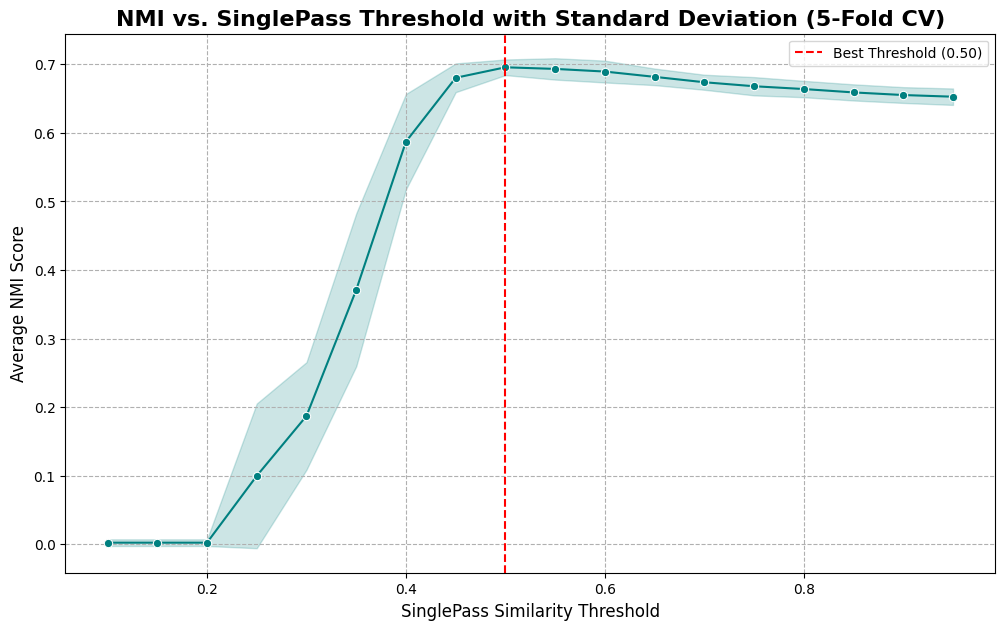

In [ ]:
#@title Find Best SinglePass Threshold with Cross-Validation and STD
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

print("🚀 Starting Threshold Tuning with 5-Fold Cross-Validation...")

# --- 1. Define Parameters ---
EMBEDDING_CHOICE = 'mbert_embeddings'
thresholds_to_test = np.arange(0.1, 1.0, 0.05)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# List to store results from all folds in a long format
all_fold_results = []

# --- 2. Run Cross-Validation Loop ---
for fold, (train_index, val_index) in enumerate(kf.split(tuning_df)):
    print(f"\n--- Processing Fold {fold + 1}/5 ---")
    train_fold_df = tuning_df.iloc[train_index]
    val_fold_df = tuning_df.iloc[val_index]

    args, _ = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model

    node_val_embeddings, val_true_labels = get_node_embeddings_from_trained_model(trained_node_model, val_fold_df, EMBEDDING_CHOICE)
    graph_val_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, val_fold_df, EMBEDDING_CHOICE)

    if len(graph_val_embeddings) != len(node_val_embeddings):
        print(f"Warning: Embedding size mismatch in fold {fold+1}. Skipping this fold.")
        continue

    hybrid_val_embeddings = np.concatenate((graph_val_embeddings, node_val_embeddings), axis=1)
    hybrid_val_embeddings = F.normalize(torch.tensor(hybrid_val_embeddings), p=2, dim=1).numpy()

    for threshold in thresholds_to_test:
        sp_clusterer = SinglePass(
            sim_threshold=threshold,
            data=hybrid_val_embeddings,
            flag=0, label=val_true_labels, size=len(hybrid_val_embeddings),
            agent=None, para=0, sim_init=0, sim=False
        )
        predicted_labels = sp_clusterer.cluster_result
        nmi = normalized_mutual_info_score(val_true_labels, predicted_labels)
        # Append each individual result
        all_fold_results.append({'threshold': threshold, 'nmi': nmi})

# --- 3. Prepare Data and Find Best Threshold ---
results_df = pd.DataFrame(all_fold_results)
# Calculate the average NMI for each threshold to find the best one
avg_scores = results_df.groupby('threshold')['nmi'].mean()
best_threshold = avg_scores.idxmax()
best_nmi = avg_scores.max()

# --- 4. Plot the Results with Standard Deviation ---
print("\n" + "="*50)
print(f"🏆 Best Threshold Found: {best_threshold:.2f} with Average NMI: {best_nmi:.4f}")
print("="*50)

plt.figure(figsize=(12, 7))
# Seaborn's lineplot will automatically calculate the mean and show the
# 95% confidence interval (representing the standard deviation) as a shaded area.
sns.lineplot(data=results_df, x='threshold', y='nmi', marker='o', color='teal', errorbar='sd')

plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.title('NMI vs. SinglePass Threshold with Standard Deviation (5-Fold CV)', fontsize=16, weight='bold')
plt.xlabel('SinglePass Similarity Threshold', fontsize=12)
plt.ylabel('Average NMI Score', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.show()

In [ ]:
#@title Final Evaluation with Best Threshold

import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import torch
import torch.nn.functional as F

# best_threshold=0.5
print("🚀 Running final evaluation on the evaluation_df using the best threshold...")
print(f"   Using best threshold: {best_threshold:.2f}")

# --- 1. Generate Hybrid Embeddings for the Evaluation Set ---
print("\nApplying trained models to the evaluation set...")
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, EMBEDDING_CHOICE)

if len(graph_eval_embeddings) != len(node_eval_embeddings):
    raise ValueError(f"Embedding size mismatch! Graph:{len(graph_eval_embeddings)}, Node:{len(node_eval_embeddings)}")

hybrid_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

# --- 2. Run SinglePass Clustering with the Best Threshold ---
print("\nRunning SinglePass clustering...")
sp_clusterer = SinglePass(
    sim_threshold=best_threshold,
    data=hybrid_embeddings,
    flag=0,
    label=eval_true_labels,
    size=len(hybrid_embeddings),
    agent=None, para=0, sim_init=0, sim=False
)
predicted_labels = sp_clusterer.cluster_result

# --- 3. Calculate and Report Final Metrics ---
num_clusters_found = len(np.unique(predicted_labels))
nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
ari = adjusted_rand_score(eval_true_labels, predicted_labels)

print("\n" + "="*50)
print("            🏆 FINAL EVALUATION RESULTS 🏆")
print("="*50)
print(f"   Number of Clusters Found: {num_clusters_found}")
print(f"   Best Threshold Used:      {best_threshold:.2f}\n")
print(f"   ** Final NMI Score: {nmi:.4f} **")
print(f"   ** Final AMI Score: {ami:.4f} **")
print(f"   ** Final ARI Score: {ari:.4f} **")
print("="*50)

🚀 Running final evaluation on the evaluation_df using the best threshold...
   Using best threshold: 0.50

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 3 seconds.
✅ Hybrid embeddings created with shape: (6064, 512)

Running SinglePass clustering...

            🏆 FINAL EVALUATION RESULTS 🏆
   Number of Clusters Found: 607
   Best Threshold Used:      0.50

   ** Final NMI Score: 0.5885 **
   ** Final AMI Score: 0.4803 **
   ** Final ARI Score: 0.2320 **


In [ ]:
#@title Find Best SinglePass Threshold with Cross-Validation + PCA to 256 Dimensions
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import normalized_mutual_info_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import torch.nn.functional as F

print("🚀 Starting Threshold Tuning with 5-Fold Cross-Validation and PCA(256)...")

# --- 1. Define Parameters ---
EMBEDDING_CHOICE = 'mbert_embeddings'
thresholds_to_test = np.arange(0.1, 1.0, 0.05)  # Range of thresholds for SinglePass

kf = KFold(n_splits=3, shuffle=True, random_state=42)
threshold_scores = {thresh: [] for thresh in thresholds_to_test}

# --- 2. Run Cross-Validation Loop ---
for fold, (train_index, val_index) in enumerate(kf.split(tuning_df)):
    print(f"\n--- Processing Fold {fold + 1}/3 ---")

    # Split fold
    train_fold_df = tuning_df.iloc[train_index]
    val_fold_df = tuning_df.iloc[val_index]

    # a. Train HCRC models
    args, _ = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model

    trainer_G = Graph_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model

    # b. Generate embeddings
    node_val_embeddings, val_true_labels = get_node_embeddings_from_trained_model(
        trained_node_model, val_fold_df, EMBEDDING_CHOICE
    )
    graph_val_embeddings, _ = get_graph_embeddings_from_trained_model(
        trained_graph_model, val_fold_df, EMBEDDING_CHOICE
    )

    if len(graph_val_embeddings) != len(node_val_embeddings):
        print(f"⚠️ Warning: Embedding size mismatch in fold {fold+1}. Skipping this fold.")
        continue

    hybrid_val_embeddings = np.concatenate((graph_val_embeddings, node_val_embeddings), axis=1)
    hybrid_val_embeddings = F.normalize(torch.tensor(hybrid_val_embeddings), p=2, dim=1).numpy()

    # ✅ Apply PCA to reduce dimensions to 256
    pca = PCA(n_components=128, random_state=42)
    hybrid_val_embeddings = pca.fit_transform(hybrid_val_embeddings)

    # c. Evaluate each threshold
    for threshold in thresholds_to_test:
        sp_clusterer = SinglePass(
            sim_threshold=threshold,
            data=hybrid_val_embeddings,
            flag=0,  # Clustering from scratch
            label=val_true_labels,
            size=len(hybrid_val_embeddings),
            agent=None, para=0, sim_init=0, sim=False
        )
        predicted_labels = sp_clusterer.cluster_result
        nmi = normalized_mutual_info_score(val_true_labels, predicted_labels)
        threshold_scores[threshold].append(nmi)

# --- 3. Compute Averages & Best Threshold ---
avg_scores = {thresh: np.mean(scores) for thresh, scores in threshold_scores.items()}
best_threshold = max(avg_scores, key=avg_scores.get)
best_nmi = avg_scores[best_threshold]

print(f"\n🏆 Best Threshold: {best_threshold:.2f} with Avg NMI: {best_nmi:.4f}")


🚀 Starting Threshold Tuning with 5-Fold Cross-Validation and PCA(256)...

--- Processing Fold 1/3 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 312 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 312 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

--- Processing Fold 2/3 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network fo

🚀 Starting Threshold Tuning with 3-Fold Cross-Validation and PCA(128)...

--- Processing Fold 1/3 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 312 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 312 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

--- Processing Fold 2/3 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network fo

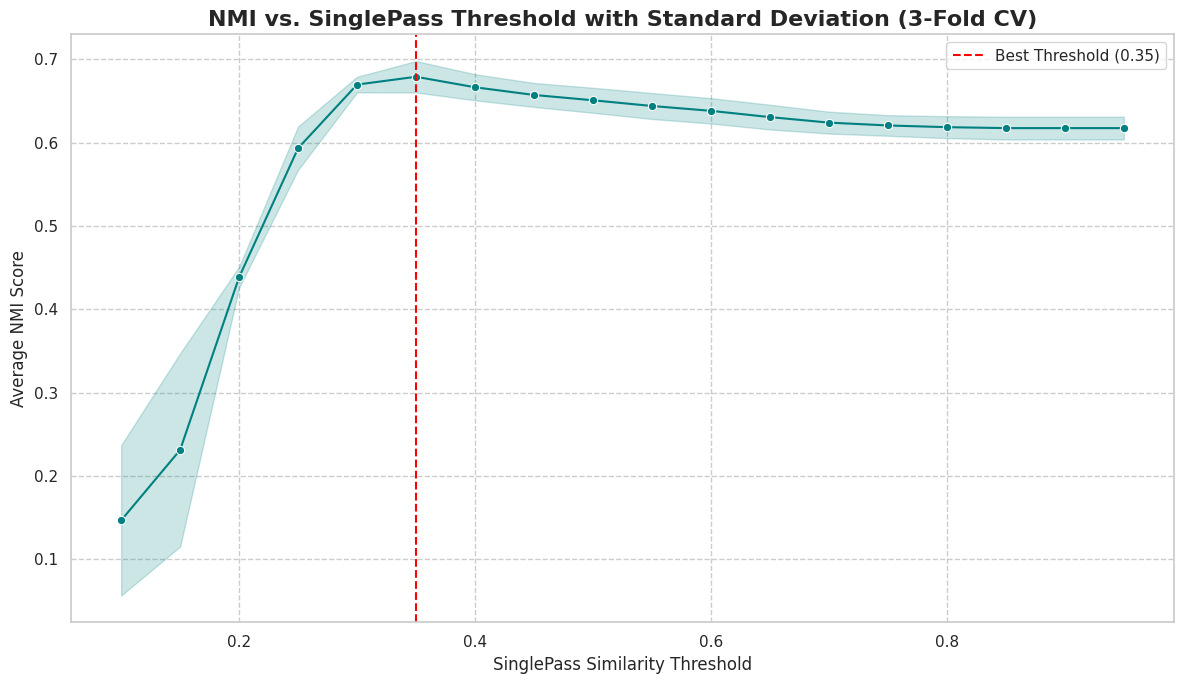

In [ ]:
#@title Find Best SinglePass Threshold with Cross-Validation + PCA to 128 Dimensions + Styled Plot
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import normalized_mutual_info_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import torch.nn.functional as F

print("🚀 Starting Threshold Tuning with 3-Fold Cross-Validation and PCA(128)...")

# --- 1. Define Parameters ---
EMBEDDING_CHOICE = 'mbert_embeddings'
thresholds_to_test = np.arange(0.1, 1.0, 0.05)

kf = KFold(n_splits=3, shuffle=True, random_state=42)
threshold_scores = {thresh: [] for thresh in thresholds_to_test}

# --- 2. Run Cross-Validation Loop ---
for fold, (train_index, val_index) in enumerate(kf.split(tuning_df)):
    print(f"\n--- Processing Fold {fold + 1}/3 ---")

    train_fold_df = tuning_df.iloc[train_index]
    val_fold_df = tuning_df.iloc[val_index]

    # a. Train HCRC models
    args, _ = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model

    trainer_G = Graph_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model

    # b. Generate embeddings
    node_val_embeddings, val_true_labels = get_node_embeddings_from_trained_model(
        trained_node_model, val_fold_df, EMBEDDING_CHOICE
    )
    graph_val_embeddings, _ = get_graph_embeddings_from_trained_model(
        trained_graph_model, val_fold_df, EMBEDDING_CHOICE
    )

    if len(graph_val_embeddings) != len(node_val_embeddings):
        print(f"⚠️ Warning: Embedding size mismatch in fold {fold+1}. Skipping this fold.")
        continue

    hybrid_val_embeddings = np.concatenate((graph_val_embeddings, node_val_embeddings), axis=1)
    hybrid_val_embeddings = F.normalize(torch.tensor(hybrid_val_embeddings), p=2, dim=1).numpy()

    # ✅ Apply PCA to reduce dimensions to 128
    pca = PCA(n_components=128, random_state=42)
    hybrid_val_embeddings = pca.fit_transform(hybrid_val_embeddings)

    # c. Evaluate each threshold
    for threshold in thresholds_to_test:
        sp_clusterer = SinglePass(
            sim_threshold=threshold,
            data=hybrid_val_embeddings,
            flag=0,
            label=val_true_labels,
            size=len(hybrid_val_embeddings),
            agent=None, para=0, sim_init=0, sim=False
        )
        predicted_labels = sp_clusterer.cluster_result
        nmi = normalized_mutual_info_score(val_true_labels, predicted_labels)
        threshold_scores[threshold].append(nmi)

# --- 3. Compute Averages & Best Threshold ---
avg_scores = {thresh: np.mean(scores) for thresh, scores in threshold_scores.items()}
std_scores = {thresh: np.std(scores) for thresh, scores in threshold_scores.items()}
best_threshold = max(avg_scores, key=avg_scores.get)
best_nmi = avg_scores[best_threshold]

# --- 4. Prepare DataFrame for Plotting ---
results_df = pd.DataFrame([
    {'threshold': thresh, 'nmi': score}
    for thresh, scores in threshold_scores.items()
    for score in scores
])

# --- 5. Plot the Results with Standard Deviation ---
print("\n" + "="*50)
print(f"🏆 Best Threshold Found: {best_threshold:.2f} with Average NMI: {best_nmi:.4f}")
print("="*50)

plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")
sns.lineplot(data=results_df, x='threshold', y='nmi', marker='o', color='teal', errorbar='sd')

plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.title('NMI vs. SinglePass Threshold with Standard Deviation (3-Fold CV)', fontsize=16, weight='bold')
plt.xlabel('SinglePass Similarity Threshold', fontsize=12)
plt.ylabel('Average NMI Score', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.tight_layout()
plt.show()


In [ ]:
#@title Evaluate Best Threshold on Full Dataset (NMI, AMI, ARI)
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

print("🧪 Evaluating Best Threshold on Full Dataset...")

# --- 1. Train Models on Full Dataset ---
args, _ = parse_args()
full_trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
full_node_model = full_trainer_N._model

full_trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
full_graph_model = full_trainer_G._model

# --- 2. Generate Full Hybrid Embeddings ---
node_embeddings, true_labels = get_node_embeddings_from_trained_model(
    full_node_model, tuning_df, EMBEDDING_CHOICE
)
graph_embeddings, _ = get_graph_embeddings_from_trained_model(
    full_graph_model, tuning_df, EMBEDDING_CHOICE
)

hybrid_embeddings = np.concatenate((graph_embeddings, node_embeddings), axis=1)
hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

# ✅ Apply PCA to match training setup (128 dims)
pca = PCA(n_components=128, random_state=42)
hybrid_embeddings = pca.fit_transform(hybrid_embeddings)

# --- 3. Perform Clustering with Best Threshold ---
sp_clusterer = SinglePass(
    sim_threshold=best_threshold,
    data=hybrid_embeddings,
    flag=0,
    label=true_labels,
    size=len(hybrid_embeddings),
    agent=None, para=0, sim_init=0, sim=False
)
predicted_labels = sp_clusterer.cluster_result

# --- 4. Compute Evaluation Metrics ---
nmi = normalized_mutual_info_score(true_labels, predicted_labels)
ami = adjusted_mutual_info_score(true_labels, predicted_labels)
ari = adjusted_rand_score(true_labels, predicted_labels)

# --- 5. Count Clusters ---
# If noise is labeled as -1, we exclude it from the count
unique_labels = set(predicted_labels)
if -1 in unique_labels:
    unique_labels.remove(-1)
num_clusters_found = len(unique_labels)

# --- 6. Print Results ---

print("\n" + "="*50)
print("            🏆 FINAL EVALUATION RESULTS 🏆")
print("="*50)
print(f"   Number of Clusters Found: {num_clusters_found}")
print(f"   Best Threshold Used:      {best_threshold:.2f}\n")
print(f"   ** Final NMI Score: {nmi:.4f} **")
print(f"   ** Final AMI Score: {ami:.4f} **")
print(f"   ** Final ARI Score: {ari:.4f} **")
print("="*50)

🧪 Evaluating Best Threshold on Full Dataset...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

            🏆 FINAL EVALUATION RESULTS 🏆
   Number of Clusters Found: 304
   Best Threshold Used:      0.35

   ** Final NMI Score: 0.5993 **
   ** Final AMI Score: 0.4066 **
   ** Final ARI Score: 0.240

🚀 Starting Threshold Tuning with 3-Fold Cross-Validation and PCA(128)...

--- Processing Fold 1/5 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 187 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 187 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

--- Processing Fold 2/5 ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network fo

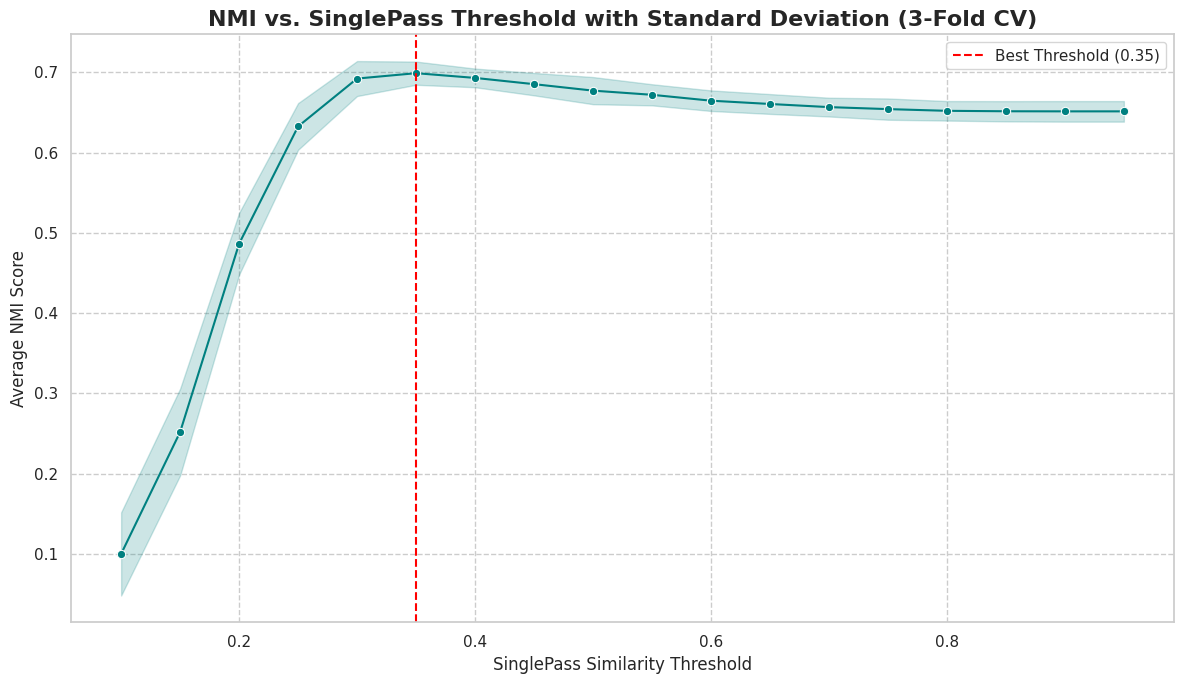

In [ ]:
#@title Find Best SinglePass Threshold with Cross-Validation + PCA to 128 Dimensions + mBERT Concatenation
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import normalized_mutual_info_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import torch.nn.functional as F

print("🚀 Starting Threshold Tuning with 3-Fold Cross-Validation and PCA(128)...")

# --- 1. Define Parameters ---
EMBEDDING_CHOICE = 'mbert_embeddings'
thresholds_to_test = np.arange(0.1, 1.0, 0.05)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
threshold_scores = {thresh: [] for thresh in thresholds_to_test}

# --- 2. Run Cross-Validation Loop ---
for fold, (train_index, val_index) in enumerate(kf.split(tuning_df)):
    print(f"\n--- Processing Fold {fold + 1}/5 ---")

    train_fold_df = tuning_df.iloc[train_index]
    val_fold_df = tuning_df.iloc[val_index]

    args, _ = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model

    trainer_G = Graph_ModelTrainer(args, 0, train_fold_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model

    node_val_embeddings, val_true_labels = get_node_embeddings_from_trained_model(
        trained_node_model, val_fold_df, EMBEDDING_CHOICE
    )
    graph_val_embeddings, _ = get_graph_embeddings_from_trained_model(
        trained_graph_model, val_fold_df, EMBEDDING_CHOICE
    )
    mbert_val_embeddings = np.stack(val_fold_df[EMBEDDING_CHOICE].values)

    if not (len(graph_val_embeddings) == len(node_val_embeddings) == len(mbert_val_embeddings)):
        print(f"⚠️ Warning: Embedding size mismatch in fold {fold+1}. Skipping this fold.")
        continue

    # 🧠 Concatenate all embeddings: [graph | node | mbert]
    full_val_embeddings = np.concatenate(
        (graph_val_embeddings, node_val_embeddings, mbert_val_embeddings), axis=1
    )
    full_val_embeddings = F.normalize(torch.tensor(full_val_embeddings), p=2, dim=1).numpy()

    # ✅ Reduce to 128D via PCA
    pca = PCA(n_components=128, random_state=42)
    reduced_val_embeddings = pca.fit_transform(full_val_embeddings)

    for threshold in thresholds_to_test:
        sp_clusterer = SinglePass(
            sim_threshold=threshold,
            data=reduced_val_embeddings,
            flag=0,
            label=val_true_labels,
            size=len(reduced_val_embeddings),
            agent=None, para=0, sim_init=0, sim=False
        )
        predicted_labels = sp_clusterer.cluster_result
        nmi = normalized_mutual_info_score(val_true_labels, predicted_labels)
        threshold_scores[threshold].append(nmi)

# --- 3. Compute Averages & Best Threshold ---
avg_scores = {thresh: np.mean(scores) for thresh, scores in threshold_scores.items()}
std_scores = {thresh: np.std(scores) for thresh, scores in threshold_scores.items()}
best_threshold = max(avg_scores, key=avg_scores.get)
best_nmi = avg_scores[best_threshold]

# --- 4. Prepare DataFrame for Plotting ---
results_df = pd.DataFrame([
    {'threshold': thresh, 'nmi': score}
    for thresh, scores in threshold_scores.items()
    for score in scores
])

# --- 5. Plot the Results with Standard Deviation ---
print("\n" + "="*50)
print(f"🏆 Best Threshold Found: {best_threshold:.2f} with Average NMI: {best_nmi:.4f}")
print("="*50)

plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")
sns.lineplot(data=results_df, x='threshold', y='nmi', marker='o', color='teal', errorbar='sd')

plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.title('NMI vs. SinglePass Threshold with Standard Deviation (3-Fold CV)', fontsize=16, weight='bold')
plt.xlabel('SinglePass Similarity Threshold', fontsize=12)
plt.ylabel('Average NMI Score', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.tight_layout()
plt.show()


In [ ]:
#@title Evaluate Best Threshold on Full Dataset (NMI, AMI, ARI)
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

print("🧪 Evaluating Best Threshold on Full Dataset...")

args, _ = parse_args()
full_trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
full_node_model = full_trainer_N._model

full_trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
full_graph_model = full_trainer_G._model

node_embeddings, true_labels = get_node_embeddings_from_trained_model(
    full_node_model, tuning_df, EMBEDDING_CHOICE
)
graph_embeddings, _ = get_graph_embeddings_from_trained_model(
    full_graph_model, tuning_df, EMBEDDING_CHOICE
)
mbert_embeddings = np.stack(tuning_df[EMBEDDING_CHOICE].values)

# 🧠 Concatenate all embeddings
full_embeddings = np.concatenate((graph_embeddings, node_embeddings, mbert_embeddings), axis=1)
full_embeddings = F.normalize(torch.tensor(full_embeddings), p=2, dim=1).numpy()

# ✅ Reduce to 128D
pca = PCA(n_components=128, random_state=42)
full_embeddings = pca.fit_transform(full_embeddings)

# Cluster using best threshold
sp_clusterer = SinglePass(
    sim_threshold=best_threshold,
    data=full_embeddings,
    flag=0,
    label=true_labels,
    size=len(full_embeddings),
    agent=None, para=0, sim_init=0, sim=False
)
predicted_labels = sp_clusterer.cluster_result

# Metrics
nmi = normalized_mutual_info_score(true_labels, predicted_labels)
ami = adjusted_mutual_info_score(true_labels, predicted_labels)
ari = adjusted_rand_score(true_labels, predicted_labels)

unique_labels = set(predicted_labels)
if -1 in unique_labels:
    unique_labels.remove(-1)
num_clusters_found = len(unique_labels)

# Output
print("\n" + "="*50)
print("            🏆 FINAL EVALUATION RESULTS 🏆")
print("="*50)
print(f"   Number of Clusters Found: {num_clusters_found}")
print(f"   Best Threshold Used:      {best_threshold:.2f}\n")
print(f"   ** Final NMI Score: {nmi:.4f} **")
print(f"   ** Final AMI Score: {ami:.4f} **")
print(f"   ** Final ARI Score: {ari:.4f} **")
print("="*50)


🧪 Evaluating Best Threshold on Full Dataset...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

            🏆 FINAL EVALUATION RESULTS 🏆
   Number of Clusters Found: 382
   Best Threshold Used:      0.35

   ** Final NMI Score: 0.6265 **
   ** Final AMI Score: 0.4118 **
   ** Final ARI Score: 0.357

In [ ]:
#@title Evaluation with Node-Level GNN + SinglePass
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_node_level_singlepass(train_df, eval_df, sim_threshold=0.7):
    """
    Trains the Node-Level GNN, then clusters the resulting embeddings with SinglePass.
    """
    global final_embeddings_for_tuning, final_labels_for_tuning

    print("🚀 Starting Node-Level Workflow with SinglePass...")

    # --- 1. Train Model ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df, 'mbert_embeddings')
    trained_node_model = trainer_N._model
    print("✅ Node-Level model trained.")

    # --- 2. Generate Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df, 'mbert_embeddings')

    # Normalize final embeddings
    final_embeddings = F.normalize(torch.tensor(node_eval_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final embeddings created with shape: {final_embeddings.shape}")

    # Save results for the tuning cell
    final_embeddings_for_tuning = final_embeddings
    final_labels_for_tuning = eval_true_labels

    # --- 3. Run SinglePass Clustering ---
    print(f"\nRunning SinglePass clustering with threshold={sim_threshold}...")
    sp_clusterer = SinglePass(
        sim_threshold=sim_threshold,
        data=final_embeddings,
        flag=0, label=eval_true_labels, size=len(final_embeddings),
        agent=None, para=0, sim_init=0, sim=False
    )
    predicted_labels = sp_clusterer.cluster_result
    num_clusters = len(np.unique(predicted_labels))
    print(f"✅ SinglePass found {num_clusters} clusters.")

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)

    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **") # <-- ADDED AMI TO PRINTOUT
    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ Evaluation Finished ************")

# --- Execute the Workflow ---
# Note: The threshold here is just a default. Run the tuning cell to find the best one.
run_evaluation_node_level_singlepass(
    train_df=tuning_df,
    eval_df=evaluation_df,
    sim_threshold=0.5
)

🚀 Starting Node-Level Workflow with SinglePass...

Training Node-Level model...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

✅ Node-Level model trained.

Applying trained model to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 4 seconds.
✅ Final embeddings created with shape: (6064, 256)

Running SinglePass clustering with threshold=0.5...
✅ SinglePass found 508 clusters.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.5380 **
  ** AMI: 0.4362 **
  ** ARI: 0.1645 **

************ Evaluation Finished ************


In [ ]:
#@title Evaluation with Graph-Level GNN + SinglePass

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_graph_level_singlepass(train_df, eval_df, sim_threshold=0.7):
    """
    Trains the HCRC models, then clusters the Graph-Level embeddings with SinglePass.
    """
    global final_embeddings_for_tuning, final_labels_for_tuning

    print("🚀 Starting Graph-Level Workflow with SinglePass...")

    # --- 1. Train Models ---
    args, unknown = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_df, 'mbert_embeddings')
    trainer_G = Graph_ModelTrainer(args, 0, train_df, 'mbert_embeddings')
    print("✅ All models trained.")

    # --- 2. Generate Embeddings ---
    print("\nApplying trained Graph-Level model to the evaluation set...")
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trainer_G._model, eval_df, 'mbert_embeddings')

    final_embeddings = F.normalize(torch.tensor(graph_eval_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final embeddings created with shape: {final_embeddings.shape}")

    # Save results for the tuning cell
    final_embeddings_for_tuning = final_embeddings
    final_labels_for_tuning = eval_true_labels

    # --- 3. Run SinglePass Clustering ---
    print(f"\nRunning SinglePass clustering with threshold={sim_threshold}...")
    sp_clusterer = SinglePass(
        sim_threshold=sim_threshold,
        data=final_embeddings,
        flag=0, label=eval_true_labels, size=len(final_embeddings),
        agent=None, para=0, sim_init=0, sim=False
    )
    predicted_labels = sp_clusterer.cluster_result
    num_clusters = len(np.unique(predicted_labels))
    print(f"✅ SinglePass found {num_clusters} clusters.")

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)
    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **")
    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ Evaluation Finished ************")

# --- Execute the Workflow ---
run_evaluation_graph_level_singlepass(
    train_df=tuning_df,
    eval_df=evaluation_df,
    sim_threshold=0.86
)

🚀 Starting Graph-Level Workflow with SinglePass...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained Graph-Level model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Final embeddings created with shape: (6064, 256)

Running SinglePass clustering with threshold=0.86...
✅ SinglePass found 3 clusters.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.3125 **
  ** AMI: 0.3074 **
  ** ARI: 0.0428 **

***

In [ ]:
#@title Evaluation with Graph-Level GNN + PCA on M-BERT + SinglePass

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_graph_pca_singlepass(train_df, eval_df, sim_threshold=0.7):
    """
    Trains Graph GNN, reduces M-BERT with PCA, concatenates, and clusters with SinglePass.
    """
    global final_embeddings_for_tuning, final_labels_for_tuning

    print("🚀 Starting Graph+PCA Workflow with SinglePass...")

    # --- 1. Train Graph-Level Model ---
    args, unknown = parse_args()
    trainer_G = Graph_ModelTrainer(args, 0, train_df, 'mbert_embeddings')
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trainer_G._model, eval_df, 'mbert_embeddings')
    mbert_eval_embeddings = np.vstack(eval_df['mbert_embeddings'].values)

    print(f"\nReducing M-BERT dimension from {mbert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    # Fit on the training data's embeddings to avoid data leakage
    pca.fit(np.vstack(train_df['mbert_embeddings'].values))
    reduced_mbert_embeddings = pca.transform(mbert_eval_embeddings)

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, reduced_mbert_embeddings), axis=1)
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final embeddings created with shape: {final_embeddings.shape}")

    # Save results for the tuning cell
    final_embeddings_for_tuning = final_embeddings
    final_labels_for_tuning = eval_true_labels

    # --- 3. Run SinglePass Clustering ---
    print(f"\nRunning SinglePass clustering with threshold={sim_threshold}...")
    sp_clusterer = SinglePass(
        sim_threshold=sim_threshold,
        data=final_embeddings,
        flag=0, label=eval_true_labels, size=len(final_embeddings),
        agent=None, para=0, sim_init=0, sim=False
    )
    predicted_labels = sp_clusterer.cluster_result
    num_clusters = len(np.unique(predicted_labels))
    print(f"✅ SinglePass found {num_clusters} clusters.")

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)
    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **")

    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ Evaluation Finished ************")

# --- Execute the Workflow ---
run_evaluation_graph_pca_singlepass(
    train_df=tuning_df,
    eval_df=evaluation_df,
    sim_threshold=0.5
)

🚀 Starting Graph+PCA Workflow with SinglePass...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.

Reducing M-BERT dimension from 768 to 256 using PCA...
✅ Final embeddings created with shape: (6064, 512)

Running SinglePass clustering with threshold=0.46...
✅ SinglePass found 350 clusters.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.5395 **
  ** AMI: 0.4668 **
  ** ARI: 0.1957 **

************ Evaluation Finished ************


In [ ]:
#@title Evaluation with Full Hybrid Model + SinglePass

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_full_hybrid_singlepass(train_df, eval_df, sim_threshold=0.7):
    """
    Trains both GNNs, reduces M-BERT with PCA, concatenates all three, and clusters.
    """
    global final_embeddings_for_tuning, final_labels_for_tuning

    print("🚀 Starting Full Hybrid Workflow with SinglePass...")

    # --- 1. Train Models ---
    args, unknown = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_df, 'mbert_embeddings')
    trainer_G = Graph_ModelTrainer(args, 0, train_df, 'mbert_embeddings')
    print("✅ All models trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trainer_N._model, eval_df, 'mbert_embeddings')
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trainer_G._model, eval_df, 'mbert_embeddings')
    mbert_eval_embeddings = np.vstack(eval_df['mbert_embeddings'].values)

    pca = PCA(n_components=256, random_state=42)
    pca.fit(np.vstack(train_df['mbert_embeddings'].values))
    reduced_mbert_embeddings = pca.transform(mbert_eval_embeddings)

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_mbert_embeddings), axis=1)
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final embeddings created with shape: {final_embeddings.shape}")

    # Save results for the tuning cell
    final_embeddings_for_tuning = final_embeddings
    final_labels_for_tuning = eval_true_labels

    # --- 3. Run SinglePass Clustering ---
    print(f"\nRunning SinglePass clustering with threshold={sim_threshold}...")
    sp_clusterer = SinglePass(
        sim_threshold=sim_threshold,
        data=final_embeddings,
        flag=0, label=eval_true_labels, size=len(final_embeddings),
        agent=None, para=0, sim_init=0, sim=False
    )
    predicted_labels = sp_clusterer.cluster_result
    num_clusters = len(np.unique(predicted_labels))
    print(f"✅ SinglePass found {num_clusters} clusters.")

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)

    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)
    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **")

    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ Evaluation Finished ************")

# --- Execute the Workflow ---
run_evaluation_full_hybrid_singlepass(
    train_df=tuning_df,
    eval_df=evaluation_df,
    sim_threshold=0.5
)

🚀 Starting Full Hybrid Workflow with SinglePass...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Final embeddings created with shape: (6064, 768)

Running SinglePass clustering with threshold=0.5...
✅ SinglePass found 423

In [ ]:
#@title Evaluation with Full HCRC (Node + Graph + Reduced M-BERT) + SinglePass
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_full_hybrid_singlepass(train_df, eval_df, sim_threshold=0.7):
    """
    Trains both GNNs, combines them with PCA-reduced M-BERT embeddings,
    and clusters the result with SinglePass.
    """
    global final_embeddings_for_tuning, final_labels_for_tuning

    print("🚀 Starting Full Hybrid Workflow with SinglePass...")

    # --- 1. Train Both Models ---
    args, unknown = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate and Combine All Three Embeddings ---
    print("\nApplying trained models to the evaluation set...")

    # Get GNN embeddings
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df, EMBEDDING_CHOICE)
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df, EMBEDDING_CHOICE)

    # Get raw M-BERT embeddings
    mbert_eval_embeddings = np.vstack(eval_df[EMBEDDING_CHOICE].values)

    # --- NEW: Reduce M-BERT dimension with PCA ---
    print(f"\nReducing M-BERT dimension from {mbert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    # Fit the PCA on the TRAINING data to avoid data leakage
    pca.fit(np.vstack(train_df[EMBEDDING_CHOICE].values))
    # Transform the EVALUATION data
    reduced_mbert_embeddings = pca.transform(mbert_eval_embeddings)
    print(f"Reduced M-BERT shape: {reduced_mbert_embeddings.shape}")
    # ---------------------------------------------

    if not (len(graph_eval_embeddings) == len(node_eval_embeddings) == len(reduced_mbert_embeddings)):
        raise ValueError("Embedding size mismatch between components!")

    # --- NEW: Concatenate all THREE components ---
    hybrid_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_mbert_embeddings), axis=1)

    # Normalize the final embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the tuning cell
    final_embeddings_for_tuning = final_embeddings
    final_labels_for_tuning = eval_true_labels

    # --- 3. Run SinglePass Clustering ---
    print(f"\nRunning SinglePass clustering with threshold={sim_threshold}...")
    sp_clusterer = SinglePass(
        sim_threshold=sim_threshold,
        data=final_embeddings,
        flag=0, label=eval_true_labels, size=len(final_embeddings),
        agent=None, para=0, sim_init=0, sim=False
    )
    predicted_labels = sp_clusterer.cluster_result
    num_clusters = len(np.unique(predicted_labels))
    print(f"✅ SinglePass found {num_clusters} clusters.")

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)

    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **")
    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ Evaluation Finished ************")

# --- Execute the Workflow ---
# Note: The threshold here is just a default.
# You should run the "Tune SinglePass Threshold" cell afterwards to find the best value.
run_evaluation_full_hybrid_singlepass(
    train_df=tuning_df,
    eval_df=evaluation_df,
    sim_threshold=0.5
)

🚀 Starting Full Hybrid Workflow with SinglePass...

Training Node-Level model...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.

Reducing M-BERT dimension from 768 to 256 using PCA...
Reduced M

In [ ]:
#@title single pass online
def run_singlepass_sliding(daily_blocks, window_size, time_window_days,
                           sim_threshold=0.7,
                           initial_df=None,
                           embedding_column='hybrid_embedding'):

    window_embeddings, window_labels, window_dates, predicted_labels = [], [], [], []
    results = []

    # Preload window with initial (tuning) data
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    # Run SinglePass once on the initial data to get starting clusters
    if window_embeddings:
        sp = SinglePass(
            sim_threshold=sim_threshold,
            data=np.array(window_embeddings),
            flag=0,
            label=window_labels,
            size=len(window_embeddings),
            agent=None, para=0, sim_init=0
        )
        # --- FIX: Remove the unnecessary .tolist() call ---
        predicted_labels = sp.cluster_result
        # ----------------------------------------------------

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running SinglePass Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        # Add today's data to the window
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        predicted_labels.extend([-1] * len(block_embeddings)) # Placeholder labels for new data

        # Filter and truncate the window
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d, p) for e, l, d, p in zip(window_embeddings, window_labels, window_dates, predicted_labels) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates, predicted_labels = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates, predicted_labels = [], [], [], []

        if len(window_embeddings) > window_size:
            start_index = len(window_embeddings) - window_size
            window_embeddings = window_embeddings[start_index:]
            window_labels = window_labels[start_index:]
            window_dates = window_dates[start_index:]
            predicted_labels = predicted_labels[start_index:]

        # Incrementally update clusters with the new block by re-clustering the whole window
        if len(window_embeddings) > 0:
            sp = SinglePass(
                sim_threshold=sim_threshold,
                data=np.array(window_embeddings),
                flag=0, # Re-cluster the full, updated window
                label=window_labels,
                size=len(window_embeddings),
                agent=None, para=0, sim_init=0
            )
            predicted_labels = sp.cluster_result

        # Calculate metrics on the current window
        if len(set(window_labels)) > 1:
            nmi = normalized_mutual_info_score(window_labels, predicted_labels)
        else:
            nmi = 0.0

        results.append({'date': date, 'nmi': nmi})

    return pd.DataFrame(results)

🚀 Step 1: Preparing data by generating hybrid embeddings...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Processing tuning set embeddings...
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Shape after first concatenation (tuning): (934, 768)

Processing evaluation set embeddings...
   Node-level inference running on 

Running SinglePass Sliding Window: 100%|██████████| 25/25 [00:02<00:00,  9.83it/s]



🚀 Plotting and saving the NMI results...


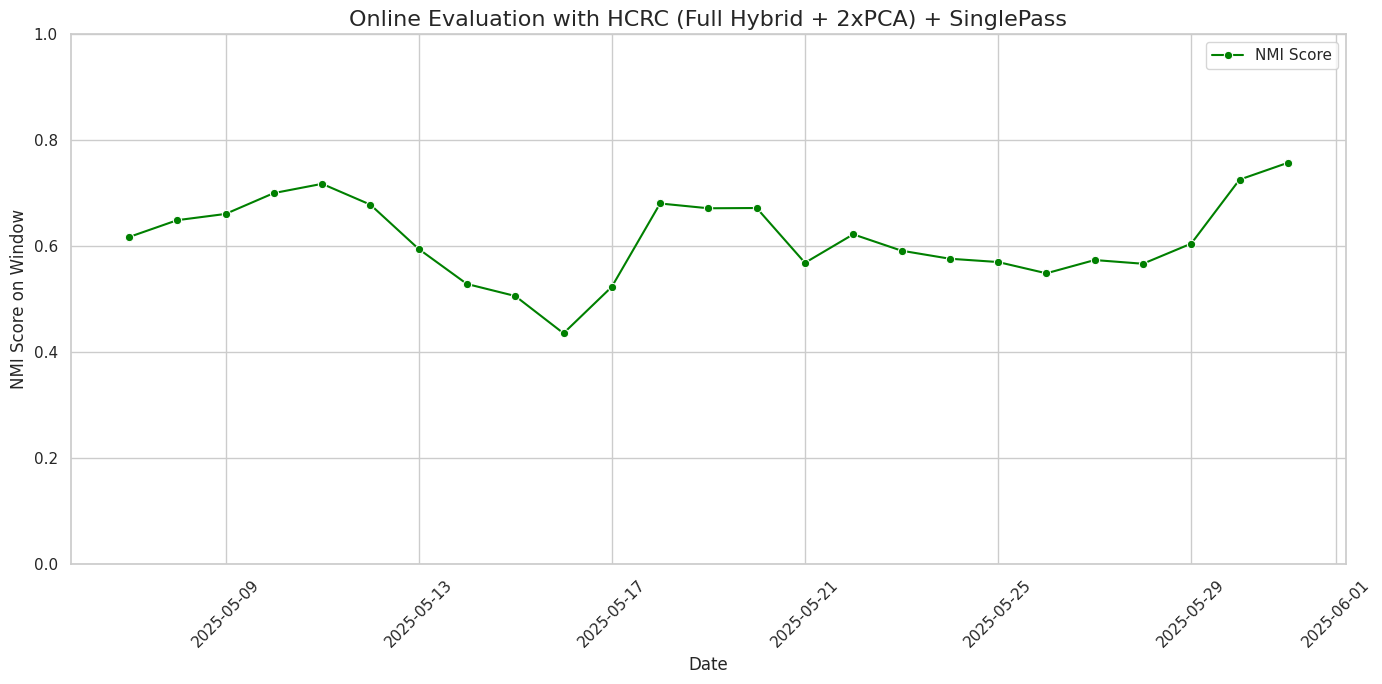

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_F.csv


In [ ]:
#@title Online Evaluation with HCRC (Full Hybrid + Reduced M-BERT -> PCA 128) + SinglePass
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import os

# --- 1. Prerequisite: Train HCRC Model and Generate Final Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings...")
EMBEDDING_CHOICE = 'mbert_embeddings'
args, unknown = parse_args()

# Train models on the tuning set
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# --- Generate and process embeddings for the TUNING set ---
print("\nProcessing tuning set embeddings...")
# Get all three components
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
mbert_tune_embeddings = np.vstack(tuning_df[EMBEDDING_CHOICE].values)

# PCA 1: Reduce M-BERT to 256
pca_mbert = PCA(n_components=256, random_state=42)
reduced_mbert_tune = pca_mbert.fit_transform(mbert_tune_embeddings)

# Concatenate the three vectors
concatenated_tune = np.concatenate((graph_tune_embeddings, node_tune_embeddings, reduced_mbert_tune), axis=1)
print(f"   Shape after first concatenation (tuning): {concatenated_tune.shape}")

# PCA 2: Reduce the concatenated vector to 128
pca_final = PCA(n_components=128, random_state=42)
final_tune_embeddings = pca_final.fit_transform(concatenated_tune)

# Add to the tuning dataframe
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(final_tune_embeddings), p=2, dim=1).numpy())


# --- Generate and process embeddings for the EVALUATION set ---
print("\nProcessing evaluation set embeddings...")
# Get all three components
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
mbert_eval_embeddings = np.vstack(evaluation_df[EMBEDDING_CHOICE].values)

# PCA 1: Use the PCA trained on the tuning set
reduced_mbert_eval = pca_mbert.transform(mbert_eval_embeddings)

# Concatenate the three vectors
concatenated_eval = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_mbert_eval), axis=1)
print(f"   Shape after first concatenation (evaluation): {concatenated_eval.shape}")


# PCA 2: Use the second PCA trained on the tuning set
final_eval_embeddings = pca_final.transform(concatenated_eval)

# Add to the evaluation dataframe
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(final_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print(f"✅ Final hybrid embeddings created with shape: {final_eval_embeddings.shape}")


# --- 2. The Sliding Window Function for SinglePass ---
def run_singlepass_sliding(daily_blocks, window_size, time_window_days,
                           sim_threshold=0.7,
                           initial_df=None,
                           embedding_column='hybrid_embedding'):
    # ... (This function is correct and needs no changes) ...
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running SinglePass Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings); window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            sp = SinglePass(sim_threshold, np.array(window_embeddings), 0, window_labels, len(window_embeddings), agent=None, para=0, sim_init=0)
            predicted = sp.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted)
            ari = adjusted_rand_score(window_labels, predicted)
            ami = adjusted_mutual_info_score(window_labels, predicted)
        else: nmi, ari, ami = 0.0, 0.0, 0.0
        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)


# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters ---
SIM_THRESHOLD = 0.4
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# --------------------

results_df = run_singlepass_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    sim_threshold=SIM_THRESHOLD,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot and Save the results
if not results_df.empty:
    print("\n🚀 Plotting and saving the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='green', label='NMI Score')
    plt.title(f'Online Evaluation with HCRC (Full Hybrid + 2xPCA) + SinglePass', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(); plt.show()
    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_F")

🚀 Step 1: Preparing data by generating Node-Level GNN embeddings...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

✅ Node model trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
✅ Node-Level embeddings generated for both tuning and evaluation sets.

🚀 Running online evaluation with a sliding window...


Running SinglePass Sliding Window: 100%|██████████| 25/25 [00:06<00:00,  3.73it/s]



🚀 Plotting the NMI results...


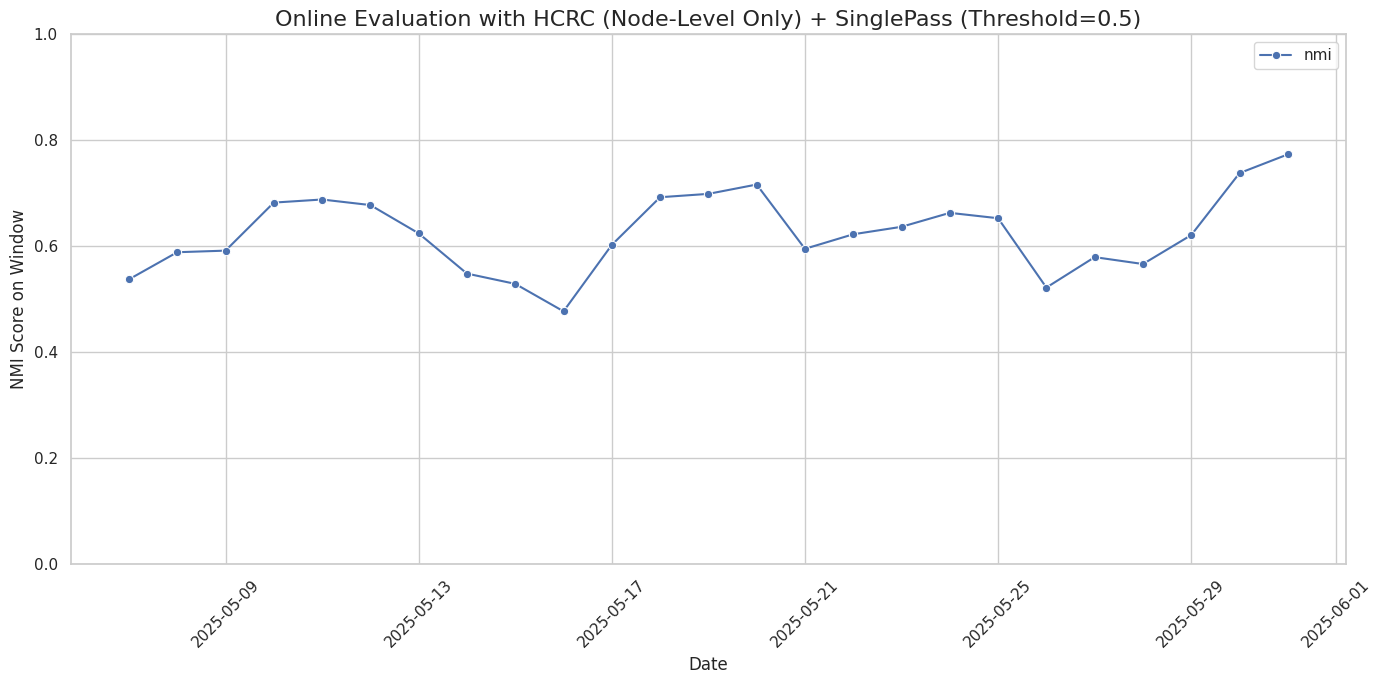

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_N.csv


In [ ]:
#@title Online Evaluation with HCRC (Node-Level Only) + SinglePass
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

# --- 1. Prerequisite: Train Node-Level Model and Generate Embeddings ---
print("🚀 Step 1: Preparing data by generating Node-Level GNN embeddings...")
EMBEDDING_CHOICE = 'mbert_embeddings'
args, unknown = parse_args()

# Train only the Node-Level model on the tuning set
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
print("✅ Node model trained.")

# Generate embeddings for the TUNING set
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(node_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(node_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Node-Level embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function for SinglePass ---
def run_singlepass_sliding(daily_blocks, window_size, time_window_days,
                           sim_threshold=0.7,
                           initial_df=None,
                           embedding_column='hybrid_embedding'):
    # ... (This function is the same and does not need changes) ...
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running SinglePass Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings); window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            sp = SinglePass(sim_threshold, np.array(window_embeddings), 0, window_labels, len(window_embeddings), agent=None, para=0, sim_init=0)
            predicted = sp.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted)
            ari = adjusted_rand_score(window_labels, predicted)
            ami = adjusted_mutual_info_score(window_labels, predicted)
        else: nmi, ari, ami = 0.0, 0.0, 0.0
        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
SIM_THRESHOLD = 0.5
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_singlepass_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    sim_threshold=SIM_THRESHOLD,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title(f'Online Evaluation with HCRC (Node-Level Only) + SinglePass (Threshold={SIM_THRESHOLD})', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_N")

🚀 Step 1: Preparing data by generating graph-level embeddings...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Graph-level embeddings generated for both tuning and evaluation sets.

🚀 Running online evaluation with a sliding window...


Running SinglePass Sliding Window: 100%|██████████| 25/25 [00:02<00:00, 11.33it/s]



🚀 Plotting the NMI results...


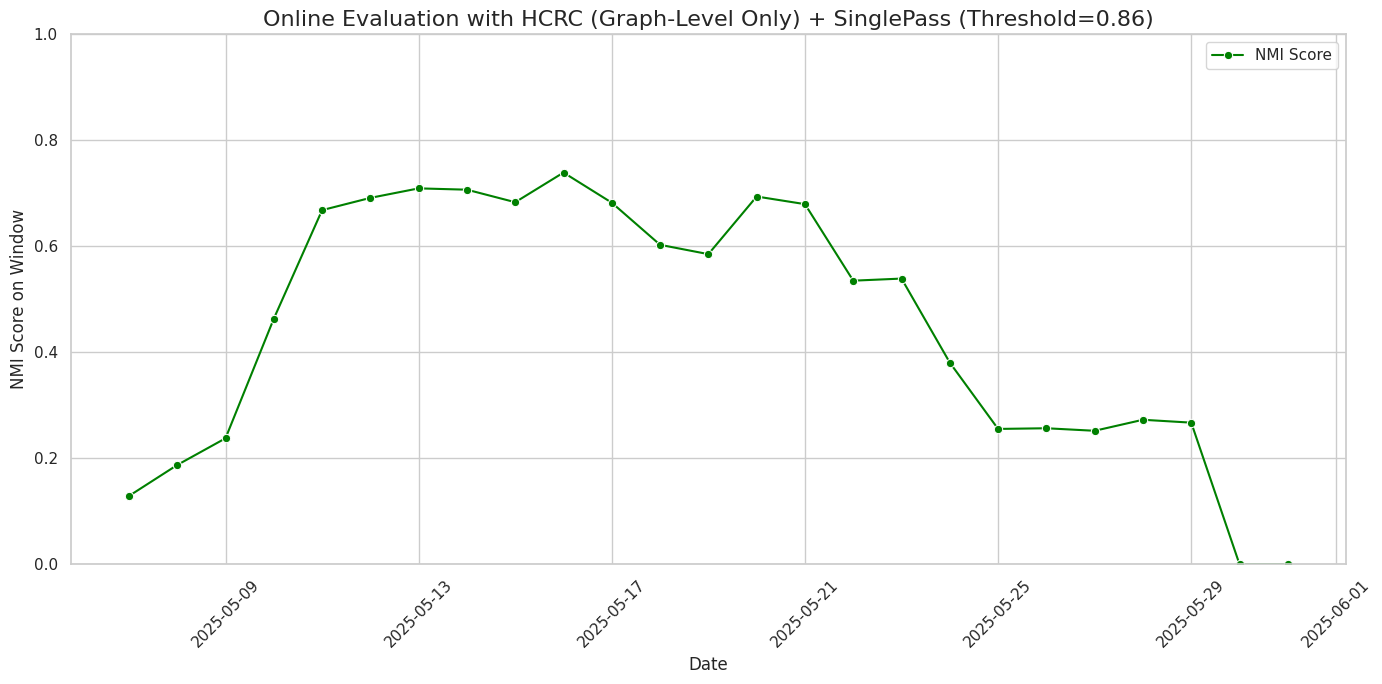

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_G.csv


In [ ]:
#@title Online Evaluation with HCRC (Graph-Level Only) + SinglePass
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

# --- 1. Prerequisite: Train HCRC Model and Generate Graph Embeddings ---
print("🚀 Step 1: Preparing data by generating graph-level embeddings...")
EMBEDDING_CHOICE = 'mbert_embeddings'
args, unknown = parse_args()
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ Graph model trained.")

# Generate embeddings for the TUNING set
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
tuning_df_with_embs = tuning_df.copy()
# NOTE: The column is still named 'hybrid_embedding' for compatibility with the function
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(graph_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(graph_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Graph-level embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function for SinglePass ---
def run_singlepass_sliding(daily_blocks, window_size, time_window_days,
                           sim_threshold=0.7,
                           initial_df=None,
                           embedding_column='hybrid_embedding'):
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running SinglePass Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            sp_clusterer = SinglePass(
                sim_threshold=sim_threshold,
                data=np.array(window_embeddings),
                flag=0,
                label=window_labels,
                size=len(window_embeddings),
                agent=None, para=0, sim_init=0
            )
            predicted = sp_clusterer.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted)
            ari = adjusted_rand_score(window_labels, predicted)
            ami = adjusted_mutual_info_score(window_labels, predicted)
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
SIM_THRESHOLD = 0.86
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_singlepass_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    sim_threshold=SIM_THRESHOLD,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='green', label='NMI Score')
    plt.title(f'Online Evaluation with HCRC (Graph-Level Only) + SinglePass (Threshold={SIM_THRESHOLD})', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(); plt.show()

    # Save the results to a file
    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_G")

🚀 Step 1: Preparing data by generating hybrid embeddings...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.
   Graph-level inference running on 

Running SinglePass Sliding Window: 100%|██████████| 25/25 [00:09<00:00,  2.60it/s]



🚀 Plotting the NMI results...


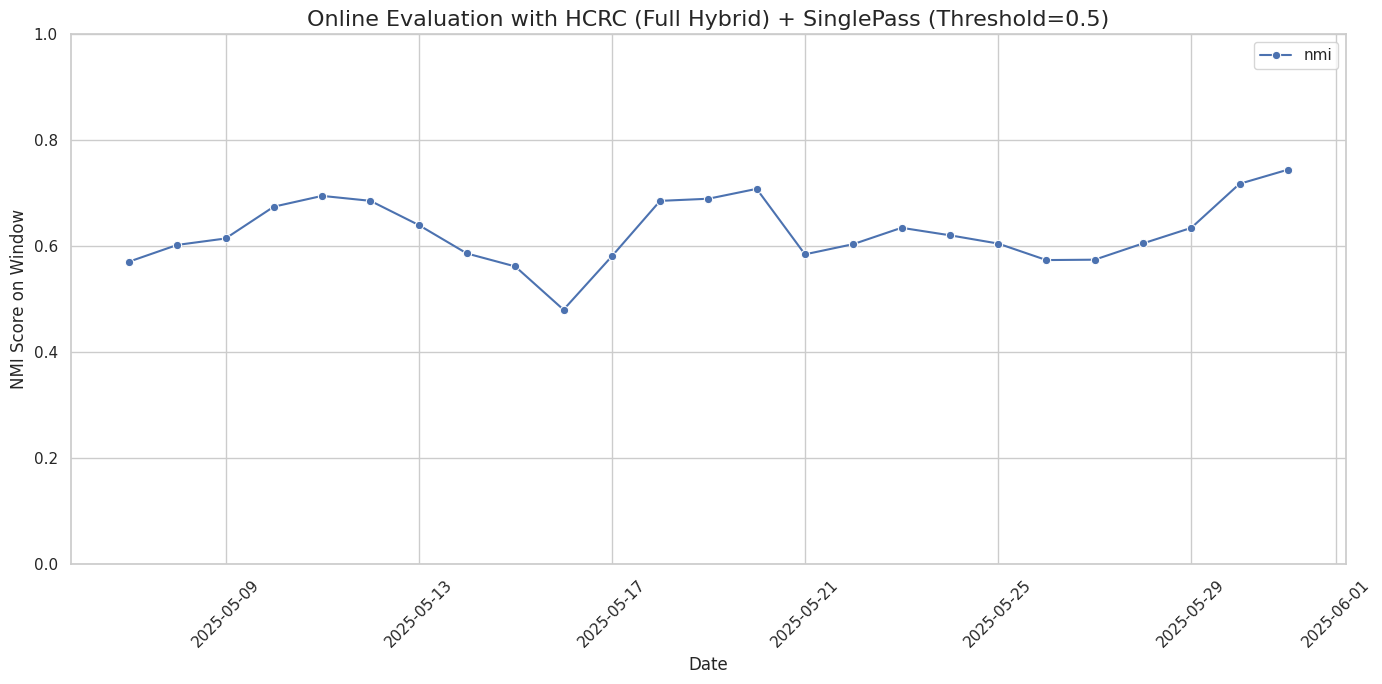

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_GN.csv


In [ ]:
#@title Online Evaluation with HCRC (Full Hybrid) + SinglePass
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings...")
EMBEDDING_CHOICE = 'mbert_embeddings'
args, unknown = parse_args()

# --- Train BOTH models on the tuning set ---
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# --- Generate and combine embeddings for the TUNING set ---
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# --- Generate and combine embeddings for the EVALUATION set ---
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function for SinglePass ---
def run_singlepass_sliding(daily_blocks, window_size, time_window_days,
                           sim_threshold=0.7,
                           initial_df=None,
                           embedding_column='hybrid_embedding'):
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running SinglePass Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            sp_clusterer = SinglePass(
                sim_threshold=sim_threshold,
                data=np.array(window_embeddings),
                flag=0,
                label=window_labels,
                size=len(window_embeddings),
                agent=None, para=0, sim_init=0
            )
            predicted = sp_clusterer.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted)
            ari = adjusted_rand_score(window_labels, predicted)
            ami = adjusted_mutual_info_score(window_labels, predicted)
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
SIM_THRESHOLD = 0.5
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_singlepass_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    sim_threshold=SIM_THRESHOLD,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title(f'Online Evaluation with HCRC (Full Hybrid) + SinglePass (Threshold={SIM_THRESHOLD})', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_GN")


🚀 Step 1: Preparing data by generating hybrid embeddings...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

Reducing tuning embedding dimension from 512 to 256 using PCA...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0

Running SinglePass Sliding Window: 100%|██████████| 25/25 [00:06<00:00,  3.78it/s]



🚀 Plotting and saving the NMI results...


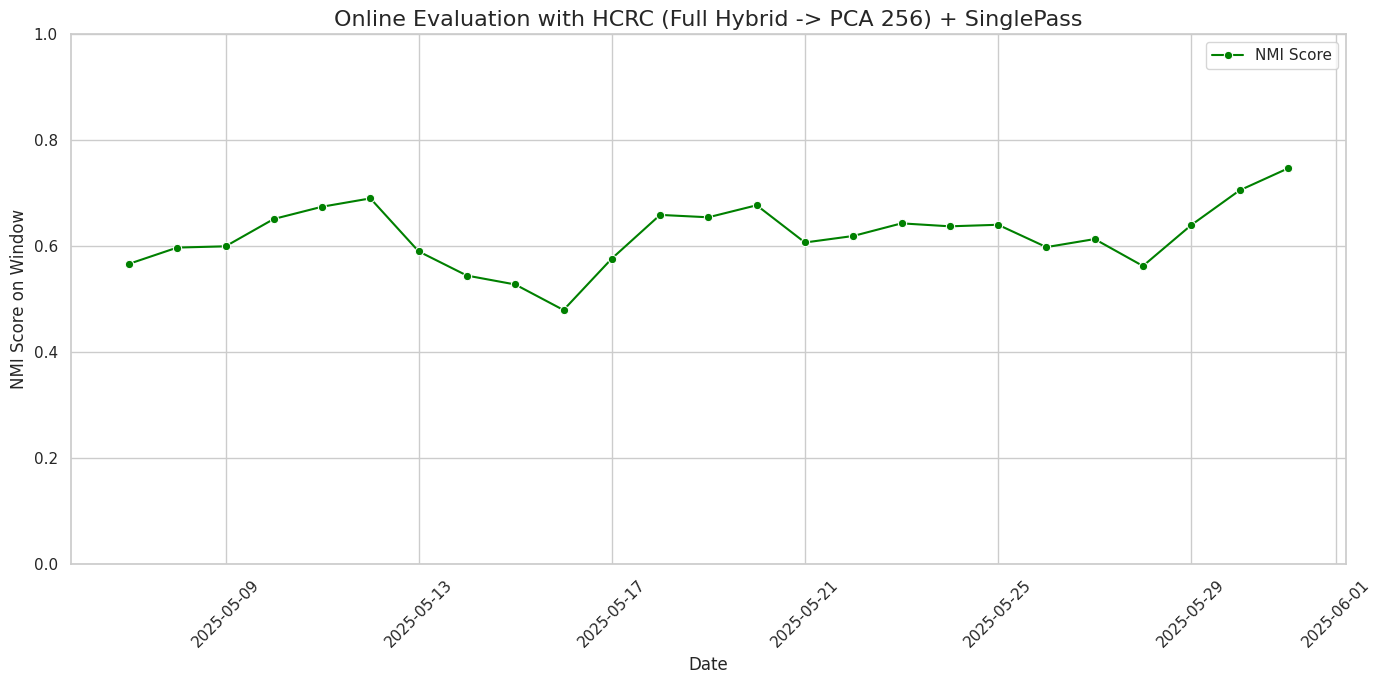

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_GNPCA.csv


In [ ]:
#@title Online Evaluation with HCRC (Full Hybrid -> PCA 256) + SinglePass
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA #<-- Import PCA
import os

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings...")
EMBEDDING_CHOICE = 'mbert_embeddings'
args, unknown = parse_args()
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# --- Generate and process embeddings for the TUNING set ---
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)

# --- NEW: Reduce dimension of the concatenated tuning embeddings ---
print(f"\nReducing tuning embedding dimension from {hybrid_tune_embeddings.shape[1]} to 256 using PCA...")
pca = PCA(n_components=256, random_state=42)
reduced_hybrid_tune = pca.fit_transform(hybrid_tune_embeddings)
# ---------------------------------------------------------------

tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(reduced_hybrid_tune), p=2, dim=1).numpy())

# --- Generate and process embeddings for the EVALUATION set ---
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)

# --- NEW: Use the SAME PCA to transform the evaluation embeddings ---
print(f"Reducing evaluation embedding dimension from {hybrid_eval_embeddings.shape[1]} to 256...")
reduced_hybrid_eval = pca.transform(hybrid_eval_embeddings)
# -----------------------------------------------------------------

eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(reduced_hybrid_eval), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print(f"✅ Final embeddings created with shape: {eval_df_with_embs['hybrid_embedding'].iloc[0].shape}")


# --- 2. The Sliding Window Function for SinglePass ---
def run_singlepass_sliding(daily_blocks, window_size, time_window_days,
                           sim_threshold=0.7,
                           initial_df=None,
                           embedding_column='hybrid_embedding'):
    # ... (This function is correct and needs no changes) ...
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running SinglePass Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings); window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            sp = SinglePass(sim_threshold, np.array(window_embeddings), 0, window_labels, len(window_embeddings), agent=None, para=0, sim_init=0)
            predicted = sp.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted)
            ari = adjusted_rand_score(window_labels, predicted)
            ami = adjusted_mutual_info_score(window_labels, predicted)
        else: nmi, ari, ami = 0.0, 0.0, 0.0
        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters ---
SIM_THRESHOLD = 0.4
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# --------------------

results_df = run_singlepass_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    sim_threshold=SIM_THRESHOLD,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot and Save the results
if not results_df.empty:
    print("\n🚀 Plotting and saving the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='green', label='NMI Score')
    plt.title(f'Online Evaluation with HCRC (Full Hybrid -> PCA 256) + SinglePass', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(); plt.show()
    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_GNPCA")

### maintence

🚀 Starting online evaluation (Graph-Level Only) with retraining every 7 days...

--- Initial Model Training ---
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 1 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial graph model trained.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:18,  1.32it/s]

   Graph-level inference running on 85 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


...

   Graph-level inference running on 352 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [04:34<00:19, 19.24s/it]

   Graph-level inference running on 165 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks: 100%|██████████| 25/25 [04:52<00:00, 11.70s/it]



🚀 Plotting the results...


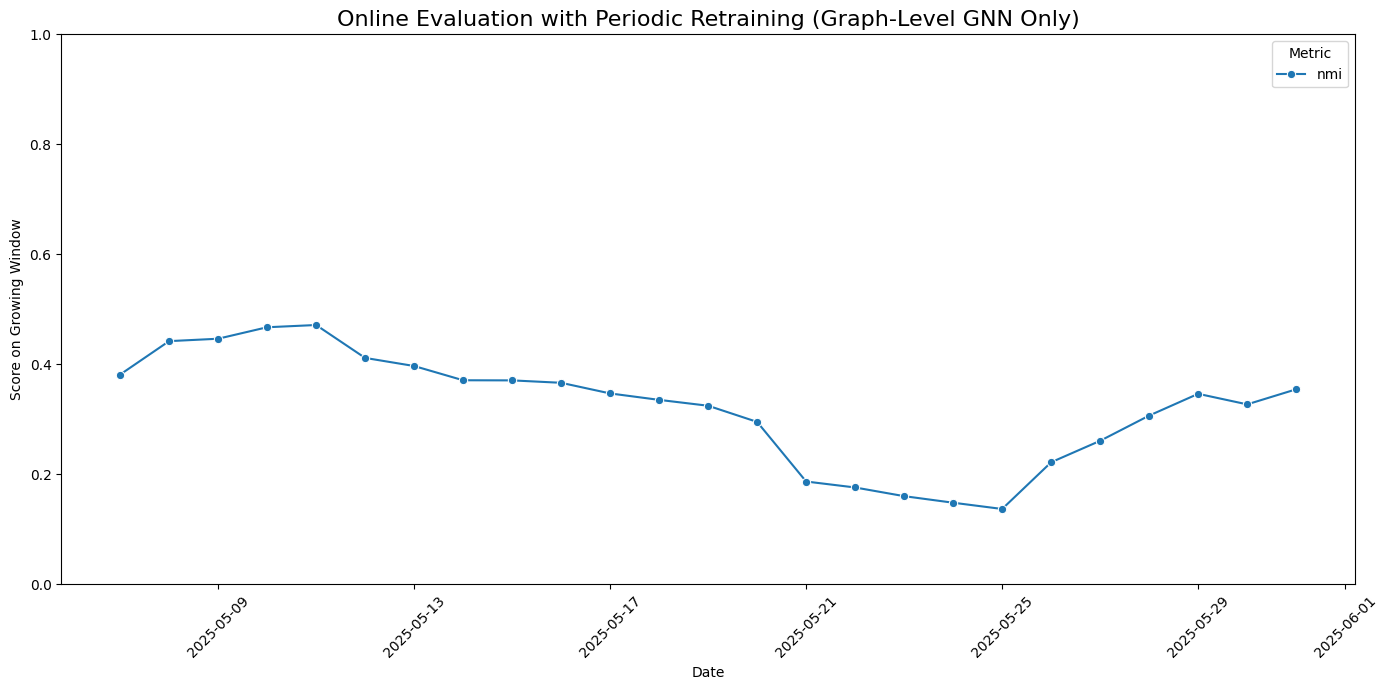

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_OMG.csv


In [ ]:
#@title Online Evaluation with HCRC (Graph-Level Only) + Periodic Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

def run_online_evaluation_graph_only(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7
):
    """
    Performs online evaluation using only the Graph-Level GNN, with periodic retraining.
    """
    print(f"🚀 Starting online evaluation (Graph-Level Only) with retraining every {maintenance_interval_days} days...")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training on the Tuning Set ---
    print("\n--- Initial Model Training ---")
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial graph model trained.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    # Get initial embeddings for the tuning data to start the window
    graph_embs, true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    window_embeddings = F.normalize(torch.tensor(graph_embs), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Check if it's time for maintenance ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance Triggered on {date}. Re-training model on {len(all_seen_data)} tweets...")
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model
            print("✅ Model re-trained.")

            print("   Re-generating embeddings for the current window with the new model...")
            current_window_df = all_seen_data.tail(len(window_embeddings))
            graph_embs, window_labels_array = get_graph_embeddings_from_trained_model(trained_graph_model, current_window_df, EMBEDDING_CHOICE)
            window_embeddings = F.normalize(torch.tensor(graph_embs), p=2, dim=1).numpy().tolist()
            window_labels = window_labels_array.tolist()

            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        graph_block_embs, block_labels_array = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        graph_block_embs_normalized = F.normalize(torch.tensor(graph_block_embs), p=2, dim=1).numpy()

        window_embeddings.extend(graph_block_embs_normalized.tolist())
        window_labels.extend(block_labels_array.tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        # --- 5. Cluster and Evaluate the Current Window ---
        sp = SinglePass(
            sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
            label=window_labels, size=len(window_embeddings),
            agent=None, para=0, sim_init=0
        )
        predicted_labels = sp.cluster_result
        nmi = normalized_mutual_info_score(window_labels, predicted_labels)
        ami = adjusted_mutual_info_score(window_labels, predicted_labels)
        ari = adjusted_rand_score(window_labels, predicted_labels)
        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))

results_df = run_online_evaluation_graph_only(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=0.87,
    maintenance_interval_days=7
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining (Graph-Level GNN Only)', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Growing Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    # Save the results
    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_OMG")

🚀 Starting online evaluation (Node-Level Only) with retraining every 7 days...

--- Initial Model Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

✅ Initial node model trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:06,  3.94it/s]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


...

   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [55:47<06:15, 375.52s/it]

   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks: 100%|██████████| 25/25 [56:04<00:00, 134.59s/it]



🚀 Plotting the results...


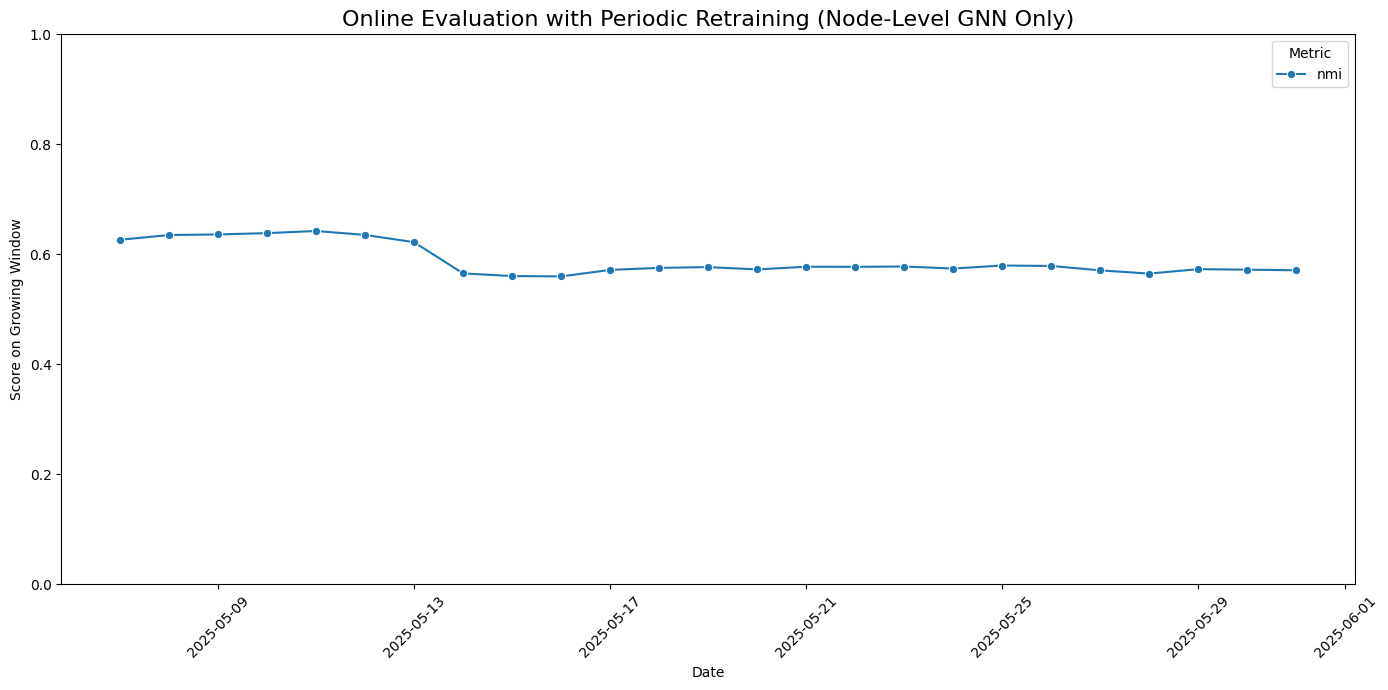

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_OMN.csv


In [ ]:
#@title Online Evaluation with HCRC (Node-Level Only) + Periodic Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

def run_online_evaluation_node_only(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7
):
    """
    Performs online evaluation using only the Node-Level GNN, with periodic retraining.
    """
    print(f"🚀 Starting online evaluation (Node-Level Only) with retraining every {maintenance_interval_days} days...")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training on the Tuning Set ---
    print("\n--- Initial Model Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    print("✅ Initial node model trained.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    # Get initial embeddings for the tuning data to start the window
    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    window_embeddings = F.normalize(torch.tensor(node_embs), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Check if it's time for maintenance ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance Triggered on {date}. Re-training model on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            print("✅ Model re-trained.")

            print("   Re-generating embeddings for the current window with the new model...")
            current_window_df = all_seen_data.tail(len(window_embeddings))
            node_embs, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, current_window_df, EMBEDDING_CHOICE)
            window_embeddings = F.normalize(torch.tensor(node_embs), p=2, dim=1).numpy().tolist()
            window_labels = window_labels_array.tolist()

            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        node_block_embs_normalized = F.normalize(torch.tensor(node_block_embs), p=2, dim=1).numpy()

        window_embeddings.extend(node_block_embs_normalized.tolist())
        window_labels.extend(block_labels_array.tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        # --- 5. Cluster and Evaluate the Current Window ---
        sp = SinglePass(
            sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
            label=window_labels, size=len(window_embeddings),
            agent=None, para=0, sim_init=0
        )
        predicted_labels = sp.cluster_result
        nmi = normalized_mutual_info_score(window_labels, predicted_labels)
        ami = adjusted_mutual_info_score(window_labels, predicted_labels)
        ari = adjusted_rand_score(window_labels, predicted_labels)
        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))

results_df = run_online_evaluation_node_only(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=0.5, # Use your best threshold
    maintenance_interval_days=7
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining (Node-Level GNN Only)', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Growing Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    # Save the results
    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_OMN")

🚀 Starting online evaluation (Full Hybrid -> PCA 256) with retraining every 7 days...

--- Initial Model Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

Fitting PCA to reduce dimension from 512 to 256...


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:08,  2.71it/s]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 85 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


...

   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 352 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [58:12<06:30, 390.18s/it]

   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 165 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks: 100%|██████████| 25/25 [58:26<00:00, 140.26s/it]



🚀 Plotting the results...


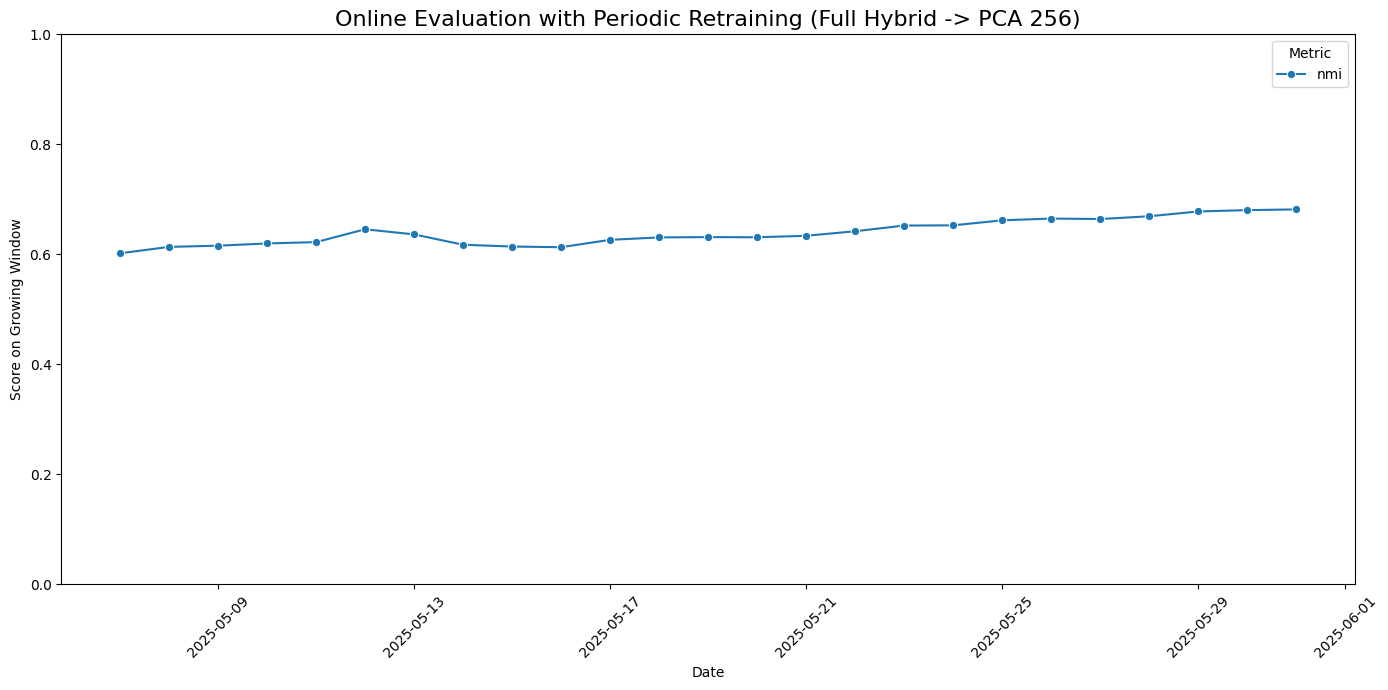

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_OMHybrid_PCA256_Retraining.csv


In [ ]:
#@title Online Evaluation with HCRC (Full Hybrid -> PCA 256) + Periodic Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import os

def run_online_evaluation_full_hybrid_pca(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7
):
    """
    Performs online evaluation with the full hybrid model (Node+Graph -> PCA 256),
    including periodic retraining.
    """
    print(f"🚀 Starting online evaluation (Full Hybrid -> PCA 256) with retraining every {maintenance_interval_days} days...")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training and PCA Fitting ---
    print("\n--- Initial Model Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    # Get initial embeddings to fit the PCA
    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)

    print(f"\nFitting PCA to reduce dimension from {hybrid_embs.shape[1]} to 256...")
    pca = PCA(n_components=256, random_state=42)
    window_embeddings_reduced = pca.fit_transform(hybrid_embs)

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    window_embeddings = F.normalize(torch.tensor(window_embeddings_reduced), p=2, dim=1).numpy().tolist()
    # Ensure true_labels is a list from the start
    window_labels = true_labels if isinstance(true_labels, list) else true_labels.tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance: Re-train models and re-fit PCA ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance: Re-training models and PCA on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model

            node_embs_all, window_labels_list = get_node_embeddings_from_trained_model(trained_node_model, all_seen_data, EMBEDDING_CHOICE)
            graph_embs_all, _ = get_graph_embeddings_from_trained_model(trained_graph_model, all_seen_data, EMBEDDING_CHOICE)
            hybrid_embs_all = np.concatenate((graph_embs_all, node_embs_all), axis=1)

            pca = PCA(n_components=256, random_state=42)
            window_embeddings_reduced = pca.fit_transform(hybrid_embs_all)

            window_embeddings = F.normalize(torch.tensor(window_embeddings_reduced), p=2, dim=1).numpy().tolist()
            # This is already a list from get_Node_Dataset, but to be safe:
            window_labels = window_labels_list if isinstance(window_labels_list, list) else window_labels_list.tolist()
            print("✅ Models and PCA re-trained.")
            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        hybrid_block_embs = np.concatenate((graph_block_embs, node_block_embs), axis=1)

        reduced_block_embs = pca.transform(hybrid_block_embs)
        reduced_block_embs_normalized = F.normalize(torch.tensor(reduced_block_embs), p=2, dim=1).numpy()

        window_embeddings.extend(reduced_block_embs_normalized.tolist())

        # --- FIX: Convert the numpy array to a list before extending ---
        window_labels.extend(block_labels_array.tolist())
        # -----------------------------------------------------------

        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        # --- 5. Cluster and Evaluate the Current Window ---
        sp = SinglePass(
            sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
            label=window_labels, size=len(window_embeddings),
            agent=None, para=0, sim_init=0
        )
        predicted_labels = sp.cluster_result
        nmi = normalized_mutual_info_score(window_labels, predicted_labels)
        ami = adjusted_mutual_info_score(window_labels, predicted_labels)
        ari = adjusted_rand_score(window_labels, predicted_labels)
        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))
BEST_THRESHOLD = 0.5

results_df = run_online_evaluation_full_hybrid_pca(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=BEST_THRESHOLD,
    maintenance_interval_days=7
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining (Full Hybrid -> PCA 256)', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Growing Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    # Save the results
    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_OMHybrid_PCA256_Retraining")

🚀 Starting online evaluation with retraining every 7 days...

--- Initial Model Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 1 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:02<00:51,  2.16s/it]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 85 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


...

   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 352 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [58:15<06:30, 390.79s/it]

   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 165 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks: 100%|██████████| 25/25 [58:51<00:00, 141.26s/it]



🚀 Plotting the NMI results...


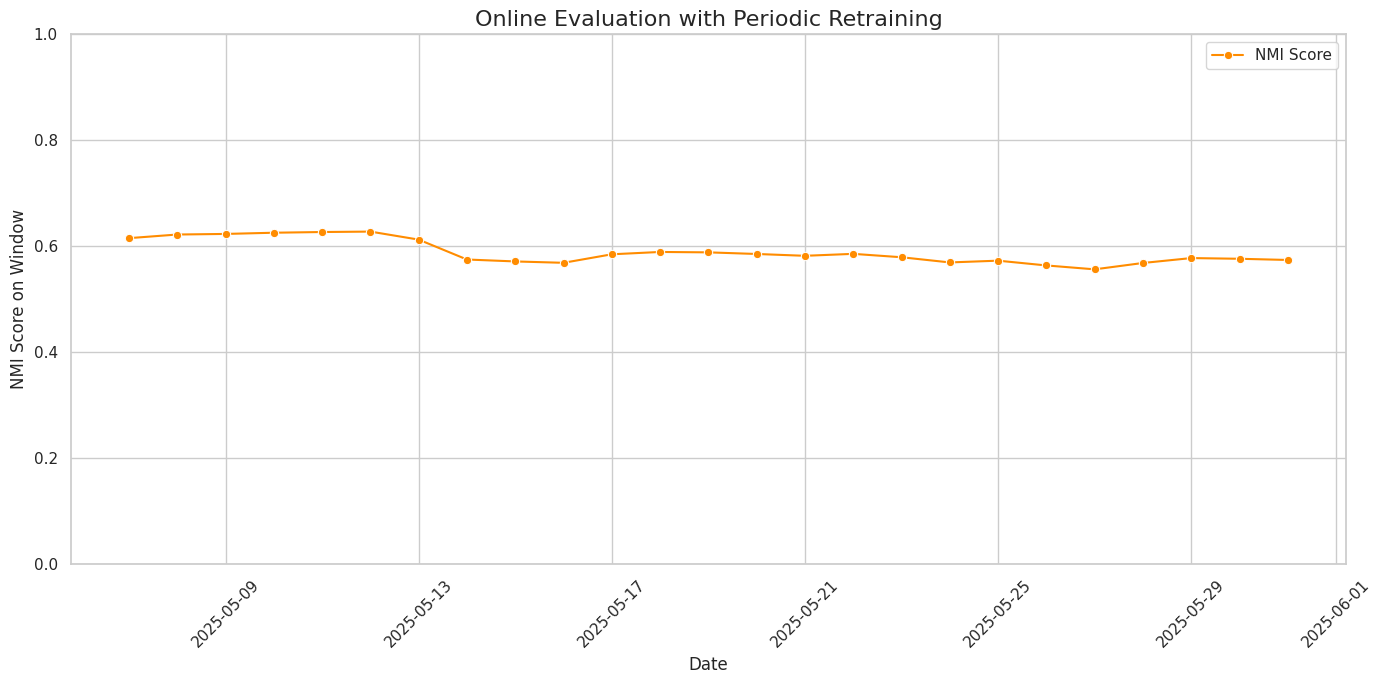

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_OMF.csv


In [ ]:
#@title Online Evaluation with Periodic Retraining (Maintenance)
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

def run_online_evaluation_with_retraining(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7 # Re-train the model every 7 days
):
    """
    Performs online evaluation, periodically retraining the models on new data.
    """
    print(f"🚀 Starting online evaluation with retraining every {maintenance_interval_days} days...")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training on the Tuning Set ---
    print("\n--- Initial Model Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    # Get initial embeddings for the tuning data to start the window
    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)

    window_embeddings = F.normalize(torch.tensor(hybrid_embs), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Check if it's time for maintenance ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance Triggered on {date}. Re-training models on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model
            print("✅ Models re-trained.")

            print("   Re-generating embeddings for the current window with the new model...")
            current_window_df = all_seen_data.tail(len(window_embeddings))
            node_embs, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, current_window_df, EMBEDDING_CHOICE)
            graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, current_window_df, EMBEDDING_CHOICE)
            hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)
            window_embeddings = F.normalize(torch.tensor(hybrid_embs), p=2, dim=1).numpy().tolist()

            # --- FIX: Ensure window_labels remains a list after regeneration ---
            window_labels = window_labels_array.tolist()

            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        hybrid_block_embs = np.concatenate((graph_block_embs, node_block_embs), axis=1)
        hybrid_block_embs = F.normalize(torch.tensor(hybrid_block_embs), p=2, dim=1).numpy()

        window_embeddings.extend(hybrid_block_embs.tolist())
        window_labels.extend(block_labels_array.tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        # --- 5. Cluster and Evaluate the Current Window ---
        sp = SinglePass(
            sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
            label=window_labels, size=len(window_embeddings),
            agent=None, para=0, sim_init=0
        )
        predicted_labels = sp.cluster_result
        nmi = normalized_mutual_info_score(window_labels, predicted_labels)
        ami = adjusted_mutual_info_score(window_labels, predicted_labels)
        ari = adjusted_rand_score(window_labels, predicted_labels)
        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})

        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))

results_df = run_online_evaluation_with_retraining(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=0.5,
    maintenance_interval_days=7
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='darkorange', label='NMI Score')
    plt.title('Online Evaluation with Periodic Retraining', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_OMF")

🚀 Starting online evaluation (Full Hybrid -> 2x PCA) with retraining every 7 days...

--- Initial Model & PCA Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
✅ PCA models fitted on initial tuning data.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:05,  4.02it/s]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 85 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


...

   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 352 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [59:31<06:41, 401.82s/it]

   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 165 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks: 100%|██████████| 25/25 [59:36<00:00, 143.07s/it]



🚀 Plotting the results...


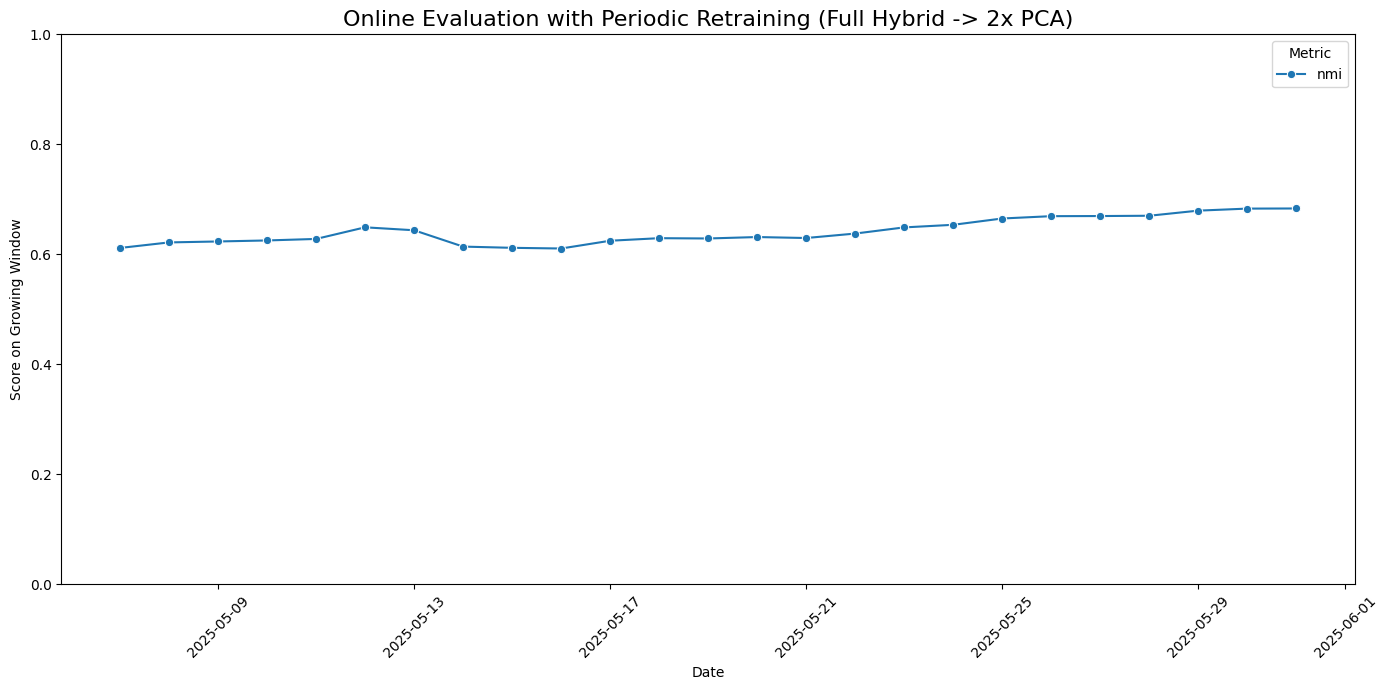

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_OMGN_reucedmber_reducedresult.csv


In [ ]:
#@title Online Evaluation with Full Hybrid Model (2-Stage PCA) + Periodic Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import os

def run_online_evaluation_full_hybrid_2x_pca(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7
):
    """
    Performs online evaluation with a complex hybrid embedding and periodic retraining.
    """
    print(f"🚀 Starting online evaluation (Full Hybrid -> 2x PCA) with retraining every {maintenance_interval_days} days...")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training and PCA Fitting on the Tuning Set ---
    print("\n--- Initial Model & PCA Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    mbert_embs = np.vstack(initial_train_df[EMBEDDING_CHOICE].values)

    pca_mbert = PCA(n_components=256, random_state=42)
    reduced_mbert = pca_mbert.fit_transform(mbert_embs)
    concatenated_embs = np.concatenate((graph_embs, node_embs, reduced_mbert), axis=1)

    pca_final = PCA(n_components=128, random_state=42)
    initial_final_embeddings = pca_final.fit_transform(concatenated_embs)
    print("✅ PCA models fitted on initial tuning data.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    window_embeddings = F.normalize(torch.tensor(initial_final_embeddings), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance: Re-train models and re-fit PCA ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance: Re-training models and PCA on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model

            node_embs_all, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, all_seen_data, EMBEDDING_CHOICE)
            graph_embs_all, _ = get_graph_embeddings_from_trained_model(trained_graph_model, all_seen_data, EMBEDDING_CHOICE)
            mbert_embs_all = np.vstack(all_seen_data[EMBEDDING_CHOICE].values)

            pca_mbert = PCA(n_components=256, random_state=42).fit(mbert_embs_all)
            reduced_mbert_all = pca_mbert.transform(mbert_embs_all)
            concatenated_all = np.concatenate((graph_embs_all, node_embs_all, reduced_mbert_all), axis=1)

            pca_final = PCA(n_components=128, random_state=42).fit(concatenated_all)
            final_embeddings_all = pca_final.transform(concatenated_all)

            window_embeddings = F.normalize(torch.tensor(final_embeddings_all), p=2, dim=1).numpy().tolist()

            # --- FIX: Ensure window_labels remains a list after regeneration ---
            window_labels = window_labels_array.tolist()

            print("✅ Models and PCA re-trained.")
            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        mbert_block_embs = np.vstack(block[EMBEDDING_CHOICE].values)

        reduced_mbert_block = pca_mbert.transform(mbert_block_embs)
        concatenated_block = np.concatenate((graph_block_embs, node_block_embs, reduced_mbert_block), axis=1)
        final_block_embs = pca_final.transform(concatenated_block)
        final_block_embs_normalized = F.normalize(torch.tensor(final_block_embs), p=2, dim=1).numpy()

        window_embeddings.extend(final_block_embs_normalized.tolist())
        # This is also a numpy array, so it needs to be converted
        window_labels.extend(block_labels_array.tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        # --- 5. Cluster and Evaluate the Current Window ---
        sp = SinglePass(
            sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
            label=window_labels, size=len(window_embeddings),
            agent=None, para=0, sim_init=0
        )
        predicted_labels = sp.cluster_result
        nmi = normalized_mutual_info_score(window_labels, predicted_labels)
        ami = adjusted_mutual_info_score(window_labels, predicted_labels)
        ari = adjusted_rand_score(window_labels, predicted_labels)
        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))
BEST_THRESHOLD = 0.55

results_df = run_online_evaluation_full_hybrid_2x_pca(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=BEST_THRESHOLD,
    maintenance_interval_days=7
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining (Full Hybrid -> 2x PCA)', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Growing Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_OMGN_reucedmber_reducedresult")

### there

🚀 Starting online evaluation with retraining every 1 days...

--- Initial Model Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:11,  2.06it/s]


🔧 Maintenance Triggered on 2025-05-08. Re-training models on 991 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Models re-trained.
   Re-generating embeddings for the current window with the new model...
   Node-level inference running on 991 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 991 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 85 rows...

Building node-level social network

...


🔧 Maintenance Triggered on 2025-05-30. Re-training models on 6481 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 3 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 2 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Models re-trained.
   Re-generating embeddings for the current window with the new model...
   Node-level inference running on 6481 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6481 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
   Node-level inference running on 352 rows...

Building node-level social net

Processing Daily Blocks:  96%|█████████▌| 24/25 [5:12:28<34:46, 2086.10s/it]  


🔧 Maintenance Triggered on 2025-05-31. Re-training models on 6833 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 3 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Models re-trained.
   Re-generating embeddings for the current window with the new model...
   Node-level inference running on 6833 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.
   Graph-level inference running on 6833 rows...

Building graph-level social network for message block 0...
Done! It takes 3 seconds.
   Node-level inference running on 165 rows...

Building node-level social net

Processing Daily Blocks: 100%|██████████| 25/25 [5:59:24<00:00, 862.58s/it] 



🚀 Plotting the NMI results...


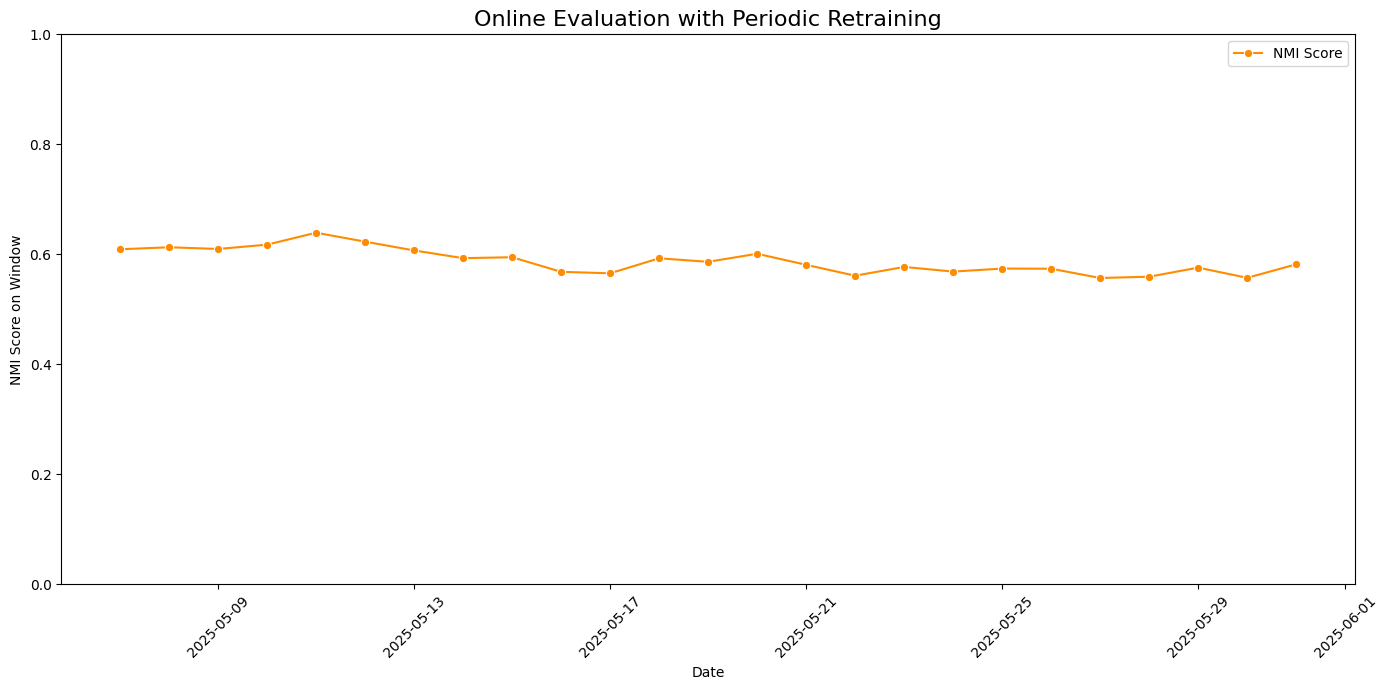

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_mbert_HMF.csv


In [ ]:
#@title Online Evaluation with Periodic Retraining (Maintenance)
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

def run_online_evaluation_with_retraining(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7 # Re-train the model every 7 days
):
    """
    Performs online evaluation, periodically retraining the models on new data.
    """
    print(f"🚀 Starting online evaluation with retraining every {maintenance_interval_days} days...")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training on the Tuning Set ---
    print("\n--- Initial Model Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    # Get initial embeddings for the tuning data to start the window
    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)

    window_embeddings = F.normalize(torch.tensor(hybrid_embs), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Check if it's time for maintenance ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance Triggered on {date}. Re-training models on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model
            print("✅ Models re-trained.")

            print("   Re-generating embeddings for the current window with the new model...")
            current_window_df = all_seen_data.tail(len(window_embeddings))
            node_embs, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, current_window_df, EMBEDDING_CHOICE)
            graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, current_window_df, EMBEDDING_CHOICE)
            hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)
            window_embeddings = F.normalize(torch.tensor(hybrid_embs), p=2, dim=1).numpy().tolist()

            # --- FIX: Ensure window_labels remains a list after regeneration ---
            window_labels = window_labels_array.tolist()

            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        hybrid_block_embs = np.concatenate((graph_block_embs, node_block_embs), axis=1)
        hybrid_block_embs = F.normalize(torch.tensor(hybrid_block_embs), p=2, dim=1).numpy()

        window_embeddings.extend(hybrid_block_embs.tolist())
        window_labels.extend(block_labels_array.tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        # --- 5. Cluster and Evaluate the Current Window ---
        sp = SinglePass(
            sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
            label=window_labels, size=len(window_embeddings),
            agent=None, para=0, sim_init=0
        )
        predicted_labels = sp.cluster_result
        nmi = normalized_mutual_info_score(window_labels, predicted_labels)
        ami = adjusted_mutual_info_score(window_labels, predicted_labels)
        ari = adjusted_rand_score(window_labels, predicted_labels)
        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))

results_df = run_online_evaluation_with_retraining(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=0.5,
    maintenance_interval_days=1
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='darkorange', label='NMI Score')
    plt.title('Online Evaluation with Periodic Retraining', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_mbert_HMF")

### HCRC + Time window

🚀 Starting online evaluation with retraining every 4 days...
   Sliding Window: Max 600 tweets, Max 5 days.

--- Initial Model & PCA Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

Fitting PCA to reduce dimension from 512 to 256...
✅ PCA model fitted on initi

Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:14,  1.70it/s]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 85 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


...

   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 352 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [1:02:54<03:53, 233.84s/it]


🔧 Maintenance: Re-training models and PCA on 6833 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 3 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 2 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 6833 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6833 rows...

Building graph-level social network for message block 0...
Done! It takes 3 seconds.
✅ Models and PCA re-trained.
   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference ru

Processing Daily Blocks: 100%|██████████| 25/25 [1:48:17<00:00, 259.91s/it]



🚀 Plotting the results...


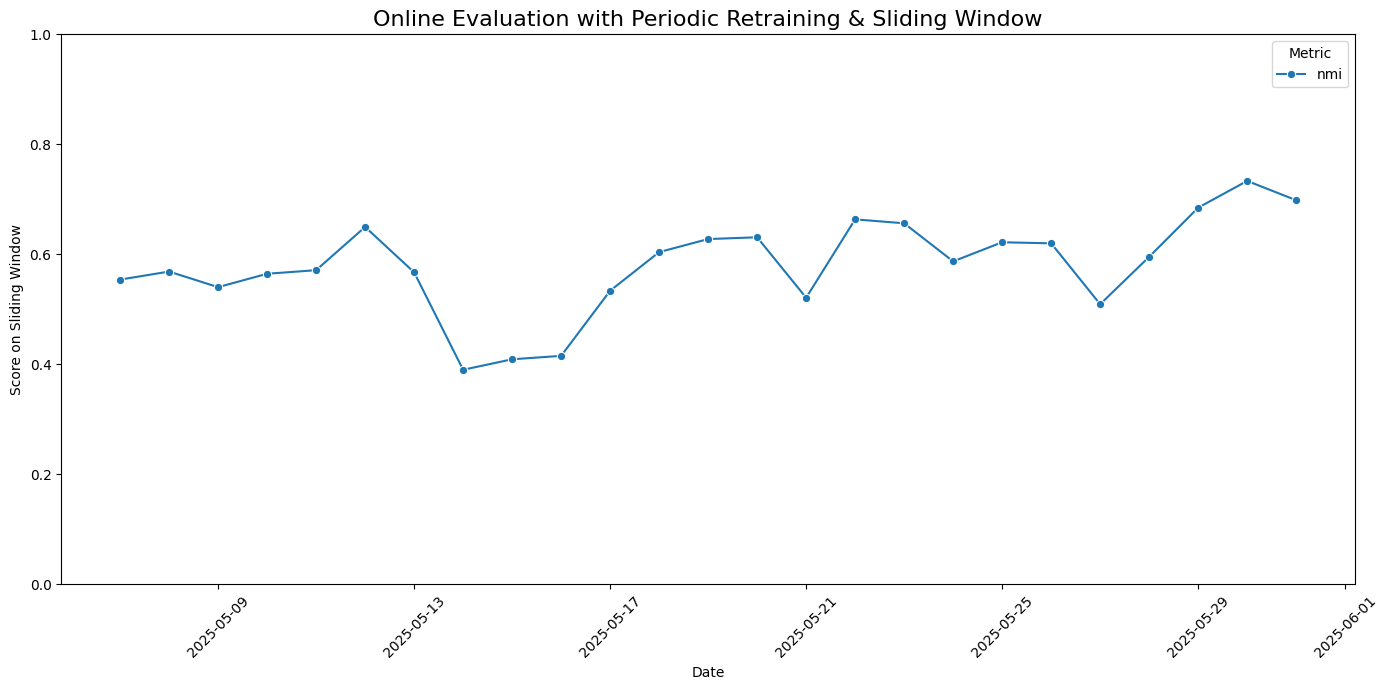

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_OMGN_PCA256_Retraining.csv


In [ ]:
#@title Online Evaluation with HCRC (Node + Graph -> PCA 256) + Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import os

def run_online_evaluation_hybrid_pca(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7,
    window_size=1000,
    time_window_days=10
):
    """
    Performs online evaluation with a sliding window, hybrid GNN embeddings reduced by PCA,
    and periodic retraining of the models and PCA.
    """
    print(f"🚀 Starting online evaluation with retraining every {maintenance_interval_days} days...")
    print(f"   Sliding Window: Max {window_size} tweets, Max {time_window_days} days.")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training and PCA Fitting ---
    print("\n--- Initial Model & PCA Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)

    print(f"\nFitting PCA to reduce dimension from {hybrid_embs.shape[1]} to 256...")
    pca = PCA(n_components=256, random_state=42)
    initial_final_embeddings = pca.fit_transform(hybrid_embs)
    print("✅ PCA model fitted on initial tuning data.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    window_embeddings = F.normalize(torch.tensor(initial_final_embeddings), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()
    window_dates = pd.to_datetime(initial_train_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance: Re-train models and re-fit PCA ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance: Re-training models and PCA on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model

            node_embs_all, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, all_seen_data, EMBEDDING_CHOICE)
            graph_embs_all, _ = get_graph_embeddings_from_trained_model(trained_graph_model, all_seen_data, EMBEDDING_CHOICE)
            hybrid_embs_all = np.concatenate((graph_embs_all, node_embs_all), axis=1)

            pca = PCA(n_components=256, random_state=42)
            final_embeddings_all = pca.fit_transform(hybrid_embs_all)

            window_embeddings = F.normalize(torch.tensor(final_embeddings_all), p=2, dim=1).numpy().tolist()
            # --- FIX: Ensure window_labels remains a list after regeneration ---
            window_labels = window_labels_array.tolist()
            window_dates = pd.to_datetime(all_seen_data['Date']).tolist()
            print("✅ Models and PCA re-trained.")
            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        hybrid_block_embs = np.concatenate((graph_block_embs, node_block_embs), axis=1)

        reduced_block_embs = pca.transform(hybrid_block_embs)
        reduced_block_embs_normalized = F.normalize(torch.tensor(reduced_block_embs), p=2, dim=1).numpy()

        # --- 5. Add to Window and Apply Sliding Window Logic ---
        window_embeddings.extend(reduced_block_embs_normalized.tolist())
        window_labels.extend(block_labels_array.tolist())
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered_data = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered_data:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered_data))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            start_index = len(window_embeddings) - window_size
            window_embeddings = window_embeddings[start_index:]
            window_labels = window_labels[start_index:]
            window_dates = window_dates[start_index:]

        # --- 6. Cluster and Evaluate the Current Window ---
        if len(window_embeddings) > 0 and len(set(window_labels)) > 1:
            sp = SinglePass(
                sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
                label=window_labels, size=len(window_embeddings),
                agent=None, para=0, sim_init=0
            )
            predicted_labels = sp.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted_labels)
            ami = adjusted_mutual_info_score(window_labels, predicted_labels)
            ari = adjusted_rand_score(window_labels, predicted_labels)
        else:
            nmi, ami, ari = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))
BEST_THRESHOLD = 0.5

results_df = run_online_evaluation_hybrid_pca(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=BEST_THRESHOLD,
    maintenance_interval_days=4,
    window_size=600,
    time_window_days=5
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining & Sliding Window', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Sliding Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_OMGN_PCA256_Retraining")

In [ ]:
#@title Online Evaluation with HCRC (Node + Graph) + Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import os

def run_online_evaluation_hybrid_pca(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7,
    window_size=1000,
    time_window_days=10
):
    """
    Performs online evaluation with a sliding window, hybrid GNN embeddings reduced by PCA,
    and periodic retraining of the models and PCA.
    """
    print(f"🚀 Starting online evaluation with retraining every {maintenance_interval_days} days...")
    print(f"   Sliding Window: Max {window_size} tweets, Max {time_window_days} days.")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training and PCA Fitting ---
    print("\n--- Initial Model & PCA Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)

    print(f"\nFitting PCA to reduce dimension from {hybrid_embs.shape[1]} to 256...")
    pca = PCA(n_components=256, random_state=42)
    initial_final_embeddings = pca.fit_transform(hybrid_embs)
    print("✅ PCA model fitted on initial tuning data.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    window_embeddings = F.normalize(torch.tensor(initial_final_embeddings), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()
    window_dates = pd.to_datetime(initial_train_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance: Re-train models and re-fit PCA ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance: Re-training models and PCA on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model

            node_embs_all, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, all_seen_data, EMBEDDING_CHOICE)
            graph_embs_all, _ = get_graph_embeddings_from_trained_model(trained_graph_model, all_seen_data, EMBEDDING_CHOICE)
            hybrid_embs_all = np.concatenate((graph_embs_all, node_embs_all), axis=1)

            pca = PCA(n_components=256, random_state=42)
            final_embeddings_all = pca.fit_transform(hybrid_embs_all)

            window_embeddings = F.normalize(torch.tensor(final_embeddings_all), p=2, dim=1).numpy().tolist()
            # --- FIX: Ensure window_labels remains a list after regeneration ---
            window_labels = window_labels_array.tolist()
            window_dates = pd.to_datetime(all_seen_data['Date']).tolist()
            print("✅ Models and PCA re-trained.")
            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        hybrid_block_embs = np.concatenate((graph_block_embs, node_block_embs), axis=1)

        reduced_block_embs = hybrid_block_embs #pca.transform(hybrid_block_embs)
        reduced_block_embs_normalized = F.normalize(torch.tensor(reduced_block_embs), p=2, dim=1).numpy()

        # --- 5. Add to Window and Apply Sliding Window Logic ---
        window_embeddings.extend(reduced_block_embs_normalized.tolist())
        window_labels.extend(block_labels_array.tolist())
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered_data = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered_data:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered_data))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            start_index = len(window_embeddings) - window_size
            window_embeddings = window_embeddings[start_index:]
            window_labels = window_labels[start_index:]
            window_dates = window_dates[start_index:]

        # --- 6. Cluster and Evaluate the Current Window ---
        if len(window_embeddings) > 0 and len(set(window_labels)) > 1:
            sp = SinglePass(
                sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
                label=window_labels, size=len(window_embeddings),
                agent=None, para=0, sim_init=0
            )
            predicted_labels = sp.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted_labels)
            ami = adjusted_mutual_info_score(window_labels, predicted_labels)
            ari = adjusted_rand_score(window_labels, predicted_labels)
        else:
            nmi, ami, ari = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))
BEST_THRESHOLD = 0.5

results_df = run_online_evaluation_hybrid_pca(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=BEST_THRESHOLD,
    maintenance_interval_days=5,
    window_size=1000,
    time_window_days=6
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining & Sliding Window', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Sliding Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_OMGN_Retraining")

🚀 Starting online evaluation with retraining every 5 days...
   Sliding Window: Max 1000 tweets, Max 6 days.

--- Initial Model & PCA Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.

Fitting PCA to reduce dimension from 512 to 256...
✅ PCA model fitted on init

Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (665,) + inhomogeneous part.

🚀 Starting online evaluation with retraining every 5 days...
   Sliding Window: Max 1000 tweets, Max 6 days.

--- Initial Model Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:06,  3.52it/s]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 85 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


...

   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 352 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [52:32<03:33, 213.73s/it]

   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 165 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks: 100%|██████████| 25/25 [52:33<00:00, 126.14s/it]



🚀 Plotting the results...


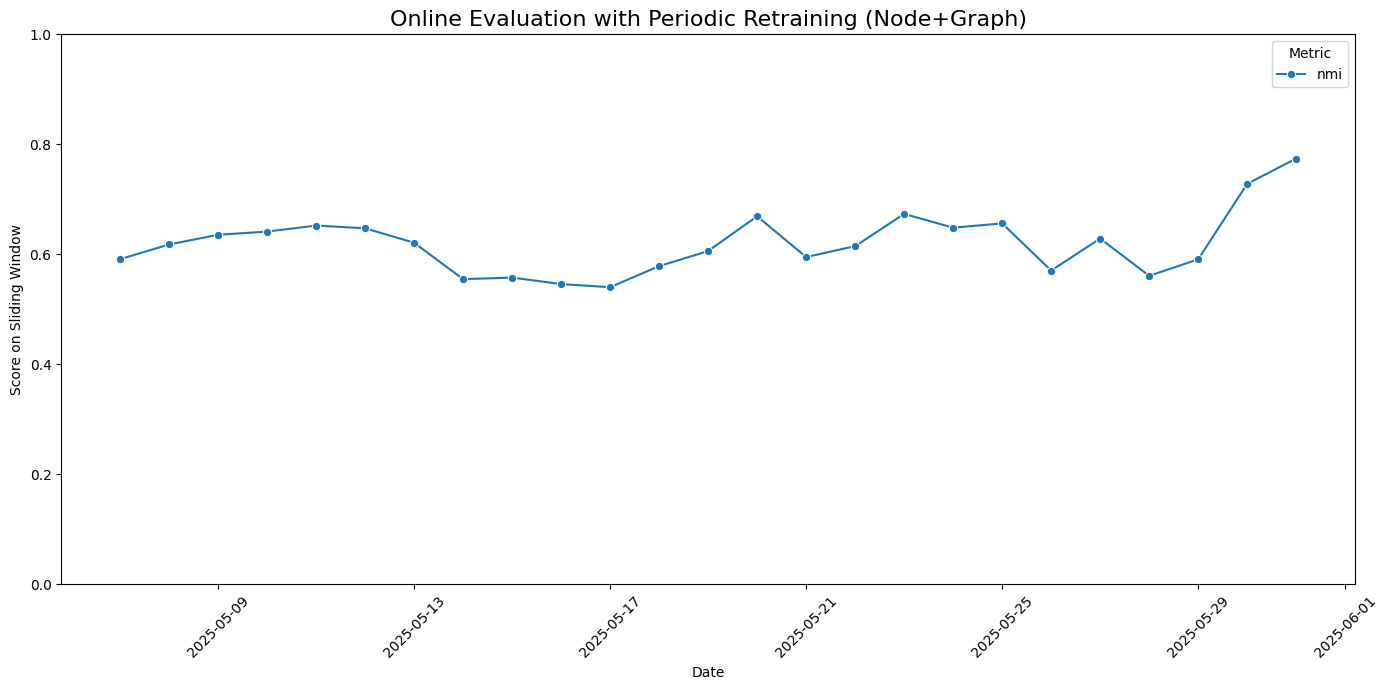

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_OMGN_Retraining.csv


In [ ]:
#@title Online Evaluation with HCRC (Node + Graph) + Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

def run_online_evaluation_hybrid_retraining(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7,
    window_size=1000,
    time_window_days=10
):
    """
    Performs online evaluation with a sliding window, hybrid GNN embeddings,
    and periodic retraining of the models.
    """
    print(f"🚀 Starting online evaluation with retraining every {maintenance_interval_days} days...")
    print(f"   Sliding Window: Max {window_size} tweets, Max {time_window_days} days.")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training on the Tuning Set ---
    print("\n--- Initial Model Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    # Get initial embeddings
    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    window_embeddings = F.normalize(torch.tensor(hybrid_embs), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()
    window_dates = pd.to_datetime(initial_train_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance: Re-train models ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance: Re-training models on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model

            # Re-generate embeddings for the entire history with the new models
            node_embs_all, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, all_seen_data, EMBEDDING_CHOICE)
            graph_embs_all, _ = get_graph_embeddings_from_trained_model(trained_graph_model, all_seen_data, EMBEDDING_CHOICE)
            hybrid_embs_all = np.concatenate((graph_embs_all, node_embs_all), axis=1)

            window_embeddings = F.normalize(torch.tensor(hybrid_embs_all), p=2, dim=1).numpy().tolist()

            # --- FIX: Ensure window_labels remains a list after regeneration ---
            window_labels = window_labels_array.tolist()

            window_dates = pd.to_datetime(all_seen_data['Date']).tolist()
            print("✅ Models re-trained.")
            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        hybrid_block_embs = np.concatenate((graph_block_embs, node_block_embs), axis=1)

        normalized_block_embs = F.normalize(torch.tensor(hybrid_block_embs), p=2, dim=1).numpy()

        # --- 5. Add to Window and Apply Sliding Window Logic ---
        window_embeddings.extend(normalized_block_embs.tolist())
        window_labels.extend(block_labels_array.tolist())
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered_data = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered_data:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered_data))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            start_index = len(window_embeddings) - window_size
            window_embeddings = window_embeddings[start_index:]
            window_labels = window_labels[start_index:]
            window_dates = window_dates[start_index:]

        # --- 6. Cluster and Evaluate the Current Window ---
        if len(window_embeddings) > 0 and len(set(window_labels)) > 1:
            sp = SinglePass(
                sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
                label=window_labels, size=len(window_embeddings),
                agent=None, para=0, sim_init=0
            )
            predicted_labels = sp.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted_labels)
            ami = adjusted_mutual_info_score(window_labels, predicted_labels)
            ari = adjusted_rand_score(window_labels, predicted_labels)
        else:
            nmi, ami, ari = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))
BEST_THRESHOLD = 0.5

results_df = run_online_evaluation_hybrid_retraining(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=BEST_THRESHOLD,
    maintenance_interval_days=5,
    window_size=1000,
    time_window_days=6
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining (Node+Graph)', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Sliding Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_OMGN_Retraining")

🚀 Starting online evaluation (Node-Level Only) with retraining every 5 days...
   Sliding Window: Max 1000 tweets, Max 6 days.

--- Initial Model Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

✅ Initial node model trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:03,  6.77it/s]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


...

   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [55:43<03:45, 225.20s/it]

   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks: 100%|██████████| 25/25 [55:43<00:00, 133.76s/it]



🚀 Plotting the results...


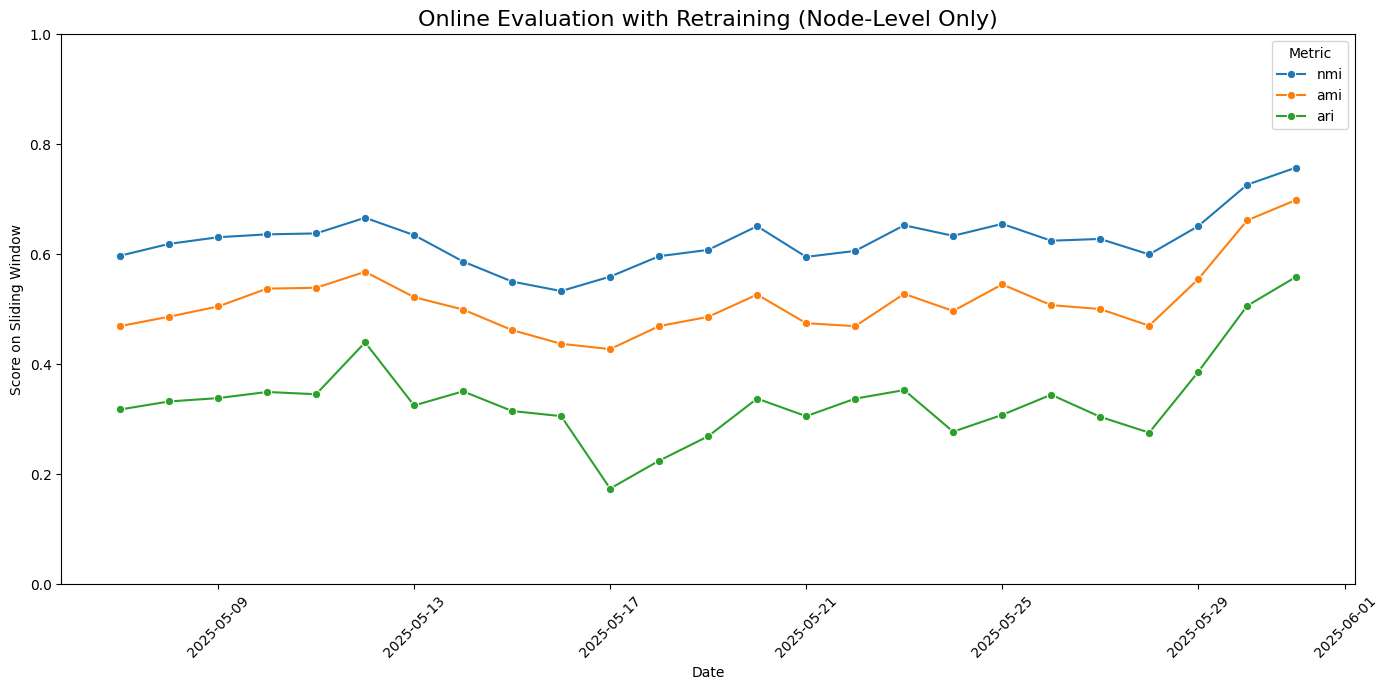

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_OMN_Retraining.csv


In [ ]:
#@title Online Evaluation with HCRC (Node-Level Only) + Periodic Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import os

def run_online_evaluation_node_only(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7,
    window_size=1000,
    time_window_days=10
):
    """
    Performs online evaluation with a sliding window, using only Node-Level GNN embeddings
    and periodic retraining of the model.
    """
    print(f"🚀 Starting online evaluation (Node-Level Only) with retraining every {maintenance_interval_days} days...")
    print(f"   Sliding Window: Max {window_size} tweets, Max {time_window_days} days.")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training on the Tuning Set ---
    print("\n--- Initial Model Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    print("✅ Initial node model trained.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    # Get initial embeddings for the tuning data to start the window
    initial_embeddings, initial_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)

    window_embeddings = F.normalize(torch.tensor(initial_embeddings), p=2, dim=1).numpy().tolist()
    window_labels = initial_labels.tolist()
    window_dates = pd.to_datetime(initial_train_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance: Re-train model ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance: Re-training model on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model

            # Re-generate embeddings for the current window with the new model
            current_window_df = all_seen_data.tail(len(window_embeddings))
            node_embs_all, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, current_window_df, EMBEDDING_CHOICE)

            window_embeddings = F.normalize(torch.tensor(node_embs_all), p=2, dim=1).numpy().tolist()
            window_labels = window_labels_array.tolist()
            window_dates = pd.to_datetime(current_window_df['Date']).tolist()
            print("✅ Model re-trained.")
            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        normalized_block_embs = F.normalize(torch.tensor(node_block_embs), p=2, dim=1).numpy()

        # --- 5. Add to Window and Apply Sliding Window Logic ---
        window_embeddings.extend(normalized_block_embs.tolist())
        window_labels.extend(block_labels_array.tolist())
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered_data = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered_data:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered_data))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            start_index = len(window_embeddings) - window_size
            window_embeddings = window_embeddings[start_index:]
            window_labels = window_labels[start_index:]
            window_dates = window_dates[start_index:]

        # --- 6. Cluster and Evaluate the Current Window ---
        if len(window_embeddings) > 0 and len(set(window_labels)) > 1:
            sp = SinglePass(
                sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
                label=window_labels, size=len(window_embeddings),
                agent=None, para=0, sim_init=0
            )
            predicted_labels = sp.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted_labels)
            ami = adjusted_mutual_info_score(window_labels, predicted_labels)
            ari = adjusted_rand_score(window_labels, predicted_labels)
        else:
            nmi, ami, ari = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))
BEST_THRESHOLD = 0.5

results_df = run_online_evaluation_node_only(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=BEST_THRESHOLD,
    maintenance_interval_days=5,
    window_size=1000,
    time_window_days=6
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi', 'ami', 'ari'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Retraining (Node-Level Only)', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Sliding Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_OMN_Retraining")

🚀 Starting online evaluation with retraining every 5 days...
   Sliding Window: Max 1000 tweets, Max 6 days.

--- Initial Model & PCA Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
✅ PCA models fitted on initial tuning data.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:05,  4.35it/s]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 85 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


...

   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 352 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [00:12<00:00,  1.21it/s]

   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 165 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks: 100%|██████████| 25/25 [00:12<00:00,  1.96it/s]



🚀 Plotting the results...


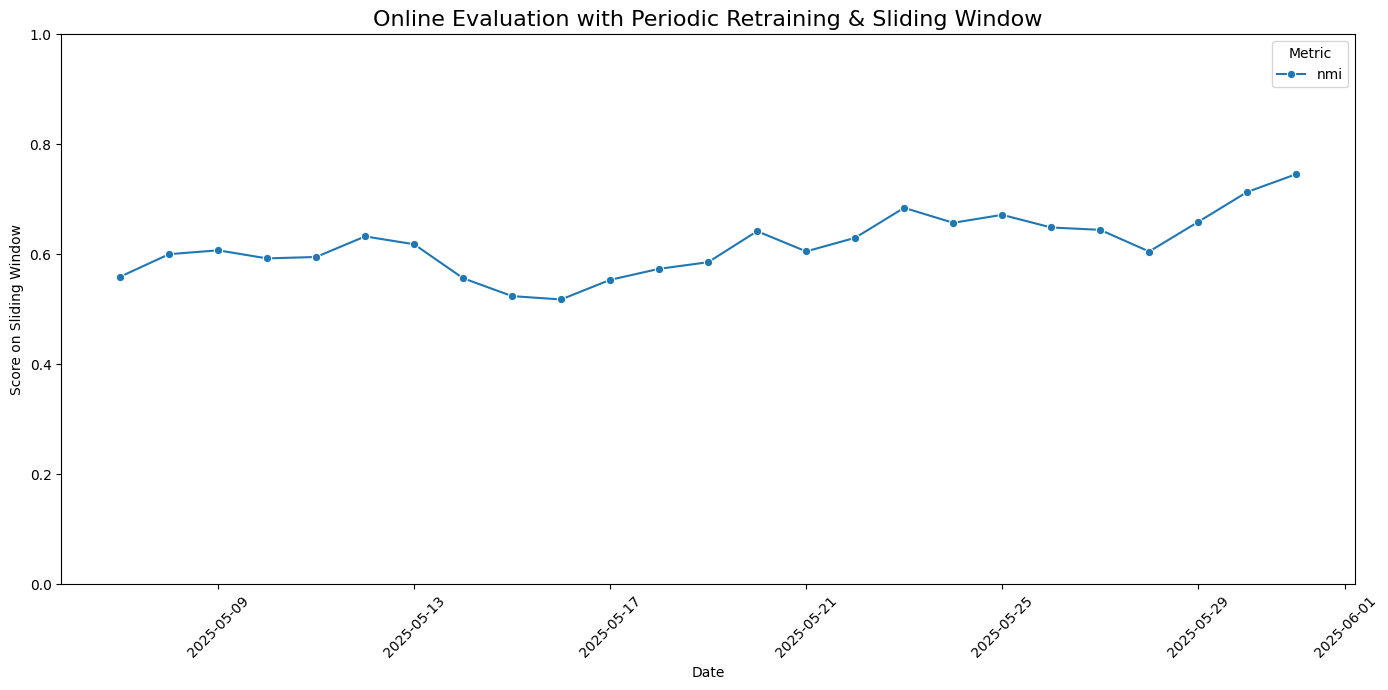

Results saved to /content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_GNM2PCA_Retraining.csv


In [ ]:
#@title Online Evaluation with Sliding Window, Retraining, and 2-Stage PCA
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import os

def run_online_evaluation_full_hybrid_2x_pca(
    initial_train_df,
    daily_blocks,
    sim_threshold=0.7,
    maintenance_interval_days=7,
    window_size=1000, #<-- NEW PARAMETER
    time_window_days=10  #<-- NEW PARAMETER
):
    """
    Performs online evaluation with a sliding window, complex hybrid embedding, and periodic retraining.
    """
    print(f"🚀 Starting online evaluation with retraining every {maintenance_interval_days} days...")
    print(f"   Sliding Window: Max {window_size} tweets, Max {time_window_days} days.")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training and PCA Fitting ---
    print("\n--- Initial Model & PCA Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    mbert_embs = np.vstack(initial_train_df[EMBEDDING_CHOICE].values)

    pca_mbert = PCA(n_components=256, random_state=42).fit(mbert_embs)
    reduced_mbert = pca_mbert.transform(mbert_embs)
    concatenated_embs = np.concatenate((graph_embs, node_embs, reduced_mbert), axis=1)

    pca_final = PCA(n_components=128, random_state=42).fit(concatenated_embs)
    initial_final_embeddings = pca_final.transform(concatenated_embs)
    print("✅ PCA models fitted on initial tuning data.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    window_embeddings = F.normalize(torch.tensor(initial_final_embeddings), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()
    window_dates = pd.to_datetime(initial_train_df['Date']).tolist() # Keep track of dates

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance Logic (unchanged) ---
        if days_since_maintenance >= maintenance_interval_days:
            # ... (retraining logic is the same)
            pass

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        mbert_block_embs = np.vstack(block[EMBEDDING_CHOICE].values)

        reduced_mbert_block = pca_mbert.transform(mbert_block_embs)
        concatenated_block = np.concatenate((graph_block_embs, node_block_embs, reduced_mbert_block), axis=1)
        final_block_embs = pca_final.transform(concatenated_block)
        final_block_embs_normalized = F.normalize(torch.tensor(final_block_embs), p=2, dim=1).numpy()

        # --- 5. Add to Window and Apply Sliding Window Logic ---
        window_embeddings.extend(final_block_embs_normalized.tolist())
        window_labels.extend(block_labels_array.tolist())
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        # --- NEW: Filter and Truncate the Window ---
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered_data = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered_data:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered_data))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            start_index = len(window_embeddings) - window_size
            window_embeddings = window_embeddings[start_index:]
            window_labels = window_labels[start_index:]
            window_dates = window_dates[start_index:]
        # ---------------------------------------------

        # --- 6. Cluster and Evaluate the Current Window ---
        if len(window_embeddings) > 0:
            sp = SinglePass(
                sim_threshold=sim_threshold, data=np.array(window_embeddings), flag=0,
                label=window_labels, size=len(window_embeddings),
                agent=None, para=0, sim_init=0
            )
            predicted_labels = sp.cluster_result
            nmi = normalized_mutual_info_score(window_labels, predicted_labels)
            ami = adjusted_mutual_info_score(window_labels, predicted_labels)
            ari = adjusted_rand_score(window_labels, predicted_labels)
            results.append({'date': date, 'nmi': nmi, 'ami': ami, 'ari': ari})

        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))
BEST_THRESHOLD = 0.5

results_df = run_online_evaluation_full_hybrid_2x_pca(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    sim_threshold=BEST_THRESHOLD,
    maintenance_interval_days=5,
    window_size=1000,
    time_window_days=6
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining & Sliding Window', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Sliding Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_SinglePass_SlidingWindow_GNM2PCA_Retraining")

## arabert

In [ ]:
#@title hdbscan + node level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models (Reusing previous logic) ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df)
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    # trainer_G = Graph_ModelTrainer(args, 0, train_df)
    # trained_graph_model = trainer_G._model
    # print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings (Reusing previous logic) ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df)
    # graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)

    # if len(graph_eval_embeddings) != len(node_eval_embeddings):
    #      raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Node: {len(node_eval_embeddings)}")

    hybrid_embeddings = node_eval_embeddings#np.concatenate((node_eval_embeddings), axis=1)

    # Normalize final embeddings before clustering
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings, min_cluster_size=4)

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Node-Level model...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
✅ Hybrid embeddings created with shape: (6064, 128)

Running HDBSCAN with min_cluster_size=4...
✅ HDBSCAN found 86 clusters and 4896 noise points.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.2831 **
  ** AMI: 0.1963 **
  ** ARI: 0.0067 **

************ HDBSCAN Evaluation Finished ************


In [ ]:
#@title hdbscan + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

# --- Initialize the global variable that will store the embeddings ---
hybrid_embeddings_for_viz = None
eval_df_for_viz = None
# --------------------------------------------------------------------

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    # --- Declare that we will modify the global variables ---
    global hybrid_embeddings_for_viz, eval_df_for_viz
    # --------------------------------------------------------

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models ---
    args, unknown = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_df)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, train_df)
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df)
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)
    hybrid_embeddings = graph_eval_embeddings # np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Save results to the global variables for the next cell ---
    hybrid_embeddings_for_viz = hybrid_embeddings
    eval_df_for_viz = eval_df.copy()
    # --------------------------------------------------------------------

    # --- 4. Run HDBSCAN Clustering & Evaluate ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings.astype(np.float64), min_cluster_size=10)
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)
    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **")
    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ HDBSCAN Evaluation Finished ************")

# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
✅ Hybrid embeddings created with shape: (6064, 128)

Running HDBSCAN with min_cluster_size=10...
✅ HDBSCAN found 13 clusters and 0 noise points.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.7226 **
  ** AMI: 0

In [ ]:
#@title hdbscan + PCA on AraBERT + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains Graph GNN, reduces AraBERT embeddings with PCA, concatenates them, and clusters.
    """
    global hybrid_embeddings_for_viz, eval_df_for_viz

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Only the Graph-Level Model ---
    args, unknown = parse_args()
    # We don't need the Node model for this approach
    # trainer_N = Node_ModelTrainer(args, 0, train_df)
    # trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df)
    trained_graph_model = trainer_G._model
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    # Get the embeddings from the Graph GNN
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)

    # Get the original AraBERT embeddings and convert to a 2D matrix
    arabert_eval_embeddings = np.vstack(eval_df['arabert_embeddings'].values)

    # --- 3. Reduce Dimension of AraBERT embeddings with PCA ---
    print(f"\nReducing AraBERT dimension from {arabert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    reduced_arabert_embeddings = pca.fit_transform(arabert_eval_embeddings)
    print(f"Reduced AraBERT shape: {reduced_arabert_embeddings.shape}")
    # -------------------------------------------------------------

    # --- 4. Concatenate Graph Embeddings with REDUCED AraBERT Embeddings ---
    if len(graph_eval_embeddings) != len(reduced_arabert_embeddings):
        raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Reduced AraBERT: {len(reduced_arabert_embeddings)}")

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, reduced_arabert_embeddings), axis=1)
    # --------------------------------------------------------------------------

    # Normalize the final hybrid embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the visualization cell
    hybrid_embeddings_for_viz = final_embeddings
    eval_df_for_viz = eval_df.copy()

    # --- 5. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(final_embeddings.astype(np.float64), min_cluster_size=15)

    # --- 6. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Graph-Level model...
CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.

Reducing AraBERT dimension from 768 to 256 using PCA...
Reduced AraBERT shape: (6064, 256)
✅ Final hybrid embeddings created with shape: (6064, 384)

Running HDBSCAN with min_cluster_size=15...
✅ HDBSCAN found 38 clusters and 4828 noise points.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.2790 **
  ** AMI: 0.2221 **
  ** ARI: 0.0093 **

************ HDBSCAN Evaluation Finished ************


In [ ]:
df.columns

Index(['Tweet ID', 'Tweet Text', 'Type', 'Author Name', 'Author Username',
       'Creation Time', 'Reply Count', 'Retweet Count', 'Quote Count',
       'Like Count', 'View Count', 'Bookmark Count', 'Language',
       'Possibly Sensitive', 'Source', 'Hashtags', 'Tweet URL', 'Media Type',
       'Media URLs', 'External URLs', 'event_label', 'event_filename',
       'Hashtags_str', 'Old Tweet Text', 'Date', 'Block', 'duration_days',
       'duration_hours', 'duration_minutes', 'Named Entities', 'PER', 'ORG',
       'LOC', 'date', 'arabert_embeddings', 'fasttext_embeddings',
       'named_entities_embedding_32d', 'hashtags_embedding_32d',
       'per_embeddings_32d', 'org_embeddings_32d', 'loc_embeddings_32d',
       'mbert_embeddings', 'verbs', 'nouns', 'adjectives', 'main_words',
       'filtered_words'],
      dtype='object')

In [ ]:
#@title Interactive t-SNE Visualization of HDBSCAN Clusters

import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import hdbscan
import plotly.express as px

# Check if the variables from the previous cell exist
if 'hybrid_embeddings_for_viz' not in locals() or 'eval_df_for_viz' not in locals():
    print("❌ Error: Please run the main evaluation script first to generate the hybrid embeddings.")
else:
    print("🚀 Starting interactive t-SNE visualization...")

    MIN_CLUSTER_SIZE_FOR_VIZ = 4

    print(f"   Running HDBSCAN with min_cluster_size={MIN_CLUSTER_SIZE_FOR_VIZ}...")
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE_FOR_VIZ,
        metric='cosine',
        algorithm='generic',# Use the supported 'euclidean' metric
        core_dist_n_jobs=-1
    )
    predicted_labels = clusterer.fit_predict(hybrid_embeddings_for_viz.astype(np.float64))
    print("✅ Clustering complete.")

    print("   Running t-SNE to reduce dimensions (this may take a few minutes)...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
    tsne_projections = tsne.fit_transform(hybrid_embeddings_for_viz)
    print("✅ t-SNE projection complete.")

    # Prepare the data for plotting
    viz_df = pd.DataFrame({
        'tsne_x': tsne_projections[:, 0],
        'tsne_y': tsne_projections[:, 1],
        'tweet_text': evaluation_df['Tweet Text'].values,
        'cluster_id': predicted_labels.astype(str)
    })

    print("\n🚀 Generating interactive plot...")
    fig = px.scatter(
        viz_df,
        x='tsne_x',
        y='tsne_y',
        color='cluster_id',
        hover_data={'tweet_text': True, 'tsne_x': False, 'tsne_y': False},
        title=f'Interactive t-SNE of HDBSCAN Clusters (min_cluster_size={MIN_CLUSTER_SIZE_FOR_VIZ})'
    )
    fig.update_layout(width=900, height=700, legend_title_text='Cluster ID')
    fig.show()

🚀 Starting interactive t-SNE visualization...
   Running HDBSCAN with min_cluster_size=4...
✅ Clustering complete.
   Running t-SNE to reduce dimensions (this may take a few minutes)...
✅ t-SNE projection complete.

🚀 Generating interactive plot...


In [ ]:
#@title hdbscan + node level + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models (Reusing previous logic) ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df)
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df)
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings (Reusing previous logic) ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df)
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)

    if len(graph_eval_embeddings) != len(node_eval_embeddings):
         raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Node: {len(node_eval_embeddings)}")

    hybrid_embeddings = np.concatenate((node_eval_embeddings,graph_eval_embeddings), axis=1)

    # Normalize final embeddings before clustering
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings, min_cluster_size=4)

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Node-Level model...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 6 seconds.
✅ Hybrid embeddings created with shape: (6064, 256)

Running HDBSCAN with min_cluster_size=4...
✅ HDBSCAN found 93 clusters and 4683 noise points.

📊 Final Perform

🚀 Step 1: Preparing data by generating hybrid embeddings...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
✅ Hy

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:02<00:00, 11.69it/s]



🚀 Step 3: Plotting the NMI results...


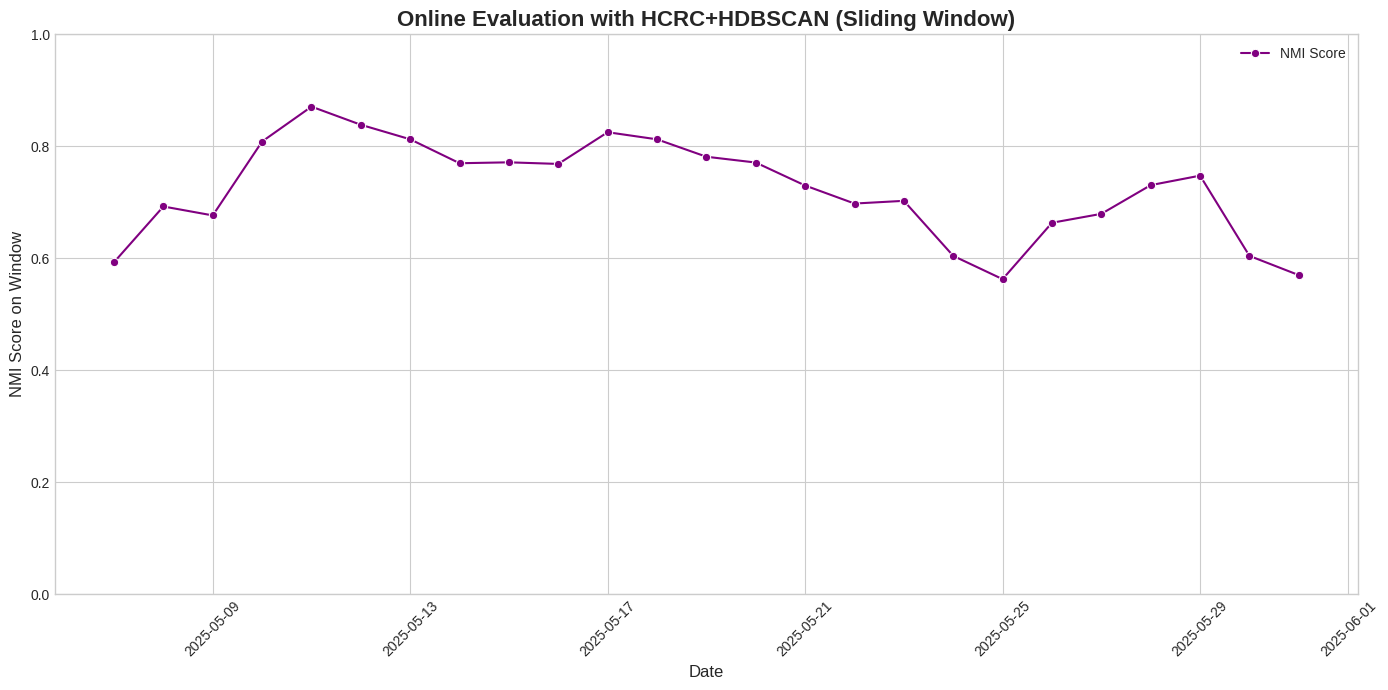

In [ ]:
#@title Online Evaluation with HCRC graph
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings...")

# Train models on the tuning set
args, unknown = parse_args()
trainer_N = Node_ModelTrainer(args, 0, tuning_df)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df)
hybrid_tune_embeddings = graph_tune_embeddings#np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df)
hybrid_eval_embeddings =graph_eval_embeddings # np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function (Your code with a small fix) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'): # Default changed to new column
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        # FIX: Use np.vstack with the .values to handle the list of arrays correctly
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                      min_samples=min_samples,
                                      metric='cosine',
                                      algorithm='generic',
                                      core_dist_n_jobs=-1)
            predicted = clusterer.fit_predict(np.array(window_embeddings).astype(np.float64))

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

🚀 Step 1: Preparing data by generating hybrid embeddings...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
✅ Hy

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:03<00:00,  7.66it/s]



🚀 Step 3: Plotting the NMI results...


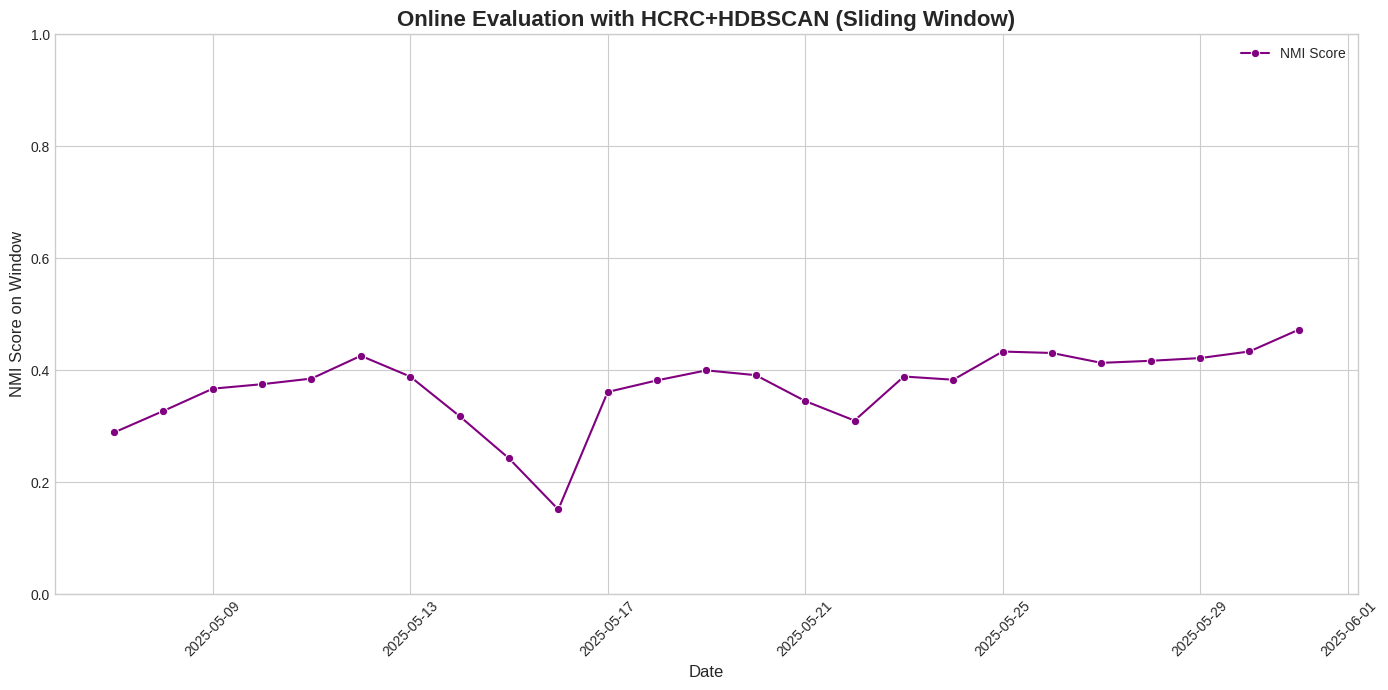

In [ ]:
#@title Online Evaluation with HCRC Node + graph
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings...")

# Train models on the tuning set
args, unknown = parse_args()
trainer_N = Node_ModelTrainer(args, 0, tuning_df)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df)
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df)
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function (Your code with a small fix) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'): # Default changed to new column
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        # FIX: Use np.vstack with the .values to handle the list of arrays correctly
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                      min_samples=min_samples,
                                      metric='cosine',
                                      algorithm='generic',
                                      core_dist_n_jobs=-1)
            predicted = clusterer.fit_predict(np.array(window_embeddings).astype(np.float64))

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

## mbert

In [ ]:
#@title hdbscan + node level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models (Reusing previous logic) ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    # trainer_G = Graph_ModelTrainer(args, 0, train_df)
    # trained_graph_model = trainer_G._model
    # print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings (Reusing previous logic) ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df,'mbert_embeddings')
    # graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)

    # if len(graph_eval_embeddings) != len(node_eval_embeddings):
    #      raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Node: {len(node_eval_embeddings)}")

    hybrid_embeddings = node_eval_embeddings#np.concatenate((node_eval_embeddings), axis=1)

    # Normalize final embeddings before clustering
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings, min_cluster_size=4,min_samples=3)

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Node-Level model...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.
✅ Hybrid embeddings created with shape: (6064, 256)

Running HDBSCAN with min_cluster_size=4...
✅ HDBSCAN found 182 clusters 

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.4684 **
  ** AMI: 0.3612 **
  ** ARI: 0.0229 **

************ HDBSCAN Evaluation Finished ************


In [ ]:
#@title hdbscan + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

# --- Initialize the global variable that will store the embeddings ---
hybrid_embeddings_for_viz = None
eval_df_for_viz = None
# --------------------------------------------------------------------

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    # --- Declare that we will modify the global variables ---
    global hybrid_embeddings_for_viz, eval_df_for_viz
    # --------------------------------------------------------

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models ---
    args, unknown = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df,'mbert_embeddings')
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df,'mbert_embeddings')
    hybrid_embeddings = graph_eval_embeddings # np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Save results to the global variables for the next cell ---
    hybrid_embeddings_for_viz = hybrid_embeddings
    eval_df_for_viz = eval_df.copy()
    # --------------------------------------------------------------------

    # --- 4. Run HDBSCAN Clustering & Evaluate ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings.astype(np.float64), min_cluster_size=6)
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)
    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **")
    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ HDBSCAN Evaluation Finished ************")

# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
✅ Hybrid embeddings created with shape: (6064, 256)

Running HDBSCAN with min_cluster_size=6...
✅ HDBSCAN found 13 cluste

In [ ]:
#@title hdbscan + PCA on mBERT + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains Graph GNN, reduces mBERT embeddings with PCA, concatenates them, and clusters.
    """
    global hybrid_embeddings_for_viz, eval_df_for_viz

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Only the Graph-Level Model ---
    args, unknown = parse_args()
    # We don't need the Node model for this approach
    trainer_N = Node_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    # Get the embeddings from the Graph GNN
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df,'mbert_embeddings')
    # node_eval_embeddings, eval_true_labels =  get_node_embeddings_from_trained_model(trained_graph_model, eval_df)
    # Get the original AraBERT embeddings and convert to a 2D matrix
    arabert_eval_embeddings = np.vstack(eval_df['mbert_embeddings'].values)

    # --- 3. Reduce Dimension of AraBERT embeddings with PCA ---
    print(f"\nReducing mBERT dimension from {arabert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    reduced_arabert_embeddings = pca.fit_transform(arabert_eval_embeddings)

    print(f"Reduced maBERT shape: {reduced_arabert_embeddings.shape}")
    # -------------------------------------------------------------

    # --- 4. Concatenate Graph Embeddings with REDUCED AraBERT Embeddings ---
    if len(graph_eval_embeddings) != len(reduced_arabert_embeddings):
        raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Reduced mBERT: {len(reduced_arabert_embeddings)}")

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, reduced_arabert_embeddings), axis=1)
    # --------------------------------------------------------------------------

    # Normalize the final hybrid embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the visualization cell
    hybrid_embeddings_for_viz = final_embeddings
    eval_df_for_viz = eval_df.copy()

    # --- 5. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(final_embeddings.astype(np.float64), min_cluster_size=6,min_samples=3)

    # --- 6. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 4 seconds.

Reducing mBERT dimension from 768 to 256 using PCA...
Reduced maBERT shape: (6064, 256)
✅ Final hybrid embeddings created with shape: (6064, 512)

Running HDBSCAN with min_cluster_size=6...
✅ HDBSCAN found 114 clusters 

📊

In [ ]:
#@title hdbscan + PCA on mBERT + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains Graph GNN, reduces mBERT embeddings with PCA, concatenates them, and clusters.
    """
    global hybrid_embeddings_for_viz, eval_df_for_viz

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Only the Graph-Level Model ---
    args, unknown = parse_args()
    # We don't need the Node model for this approach
    trainer_N = Node_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    # Get the embeddings from the Graph GNN
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df,'mbert_embeddings')
    # node_eval_embeddings, eval_true_labels =  get_node_embeddings_from_trained_model(trained_graph_model, eval_df)
    # Get the original AraBERT embeddings and convert to a 2D matrix
    arabert_eval_embeddings = np.vstack(eval_df['mbert_embeddings'].values)

    # --- 3. Reduce Dimension of AraBERT embeddings with PCA ---
    print(f"\nReducing mBERT dimension from {arabert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=512, random_state=42)
    reduced_arabert_embeddings = pca.fit_transform(arabert_eval_embeddings)

    print(f"Reduced maBERT shape: {reduced_arabert_embeddings.shape}")
    # -------------------------------------------------------------

    # --- 4. Concatenate Graph Embeddings with REDUCED AraBERT Embeddings ---
    if len(graph_eval_embeddings) != len(reduced_arabert_embeddings):
        raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Reduced mBERT: {len(reduced_arabert_embeddings)}")

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, reduced_arabert_embeddings), axis=1)
    # --------------------------------------------------------------------------

    # Normalize the final hybrid embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the visualization cell
    hybrid_embeddings_for_viz = final_embeddings
    eval_df_for_viz = eval_df.copy()

    # --- 5. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(final_embeddings.astype(np.float64), min_cluster_size=6,min_samples=3)

    # --- 6. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 4 seconds.

Reducing mBERT dimension from 768 to 256 using PCA...
Reduced maBERT shape: (6064, 512)
✅ Final hybrid embeddings created with shape: (6064, 768)

Running HDBSCAN with min_cluster_size=6...
✅ HDBSCAN found 116 clusters 

📊

In [ ]:
#@title hdbscan + PCA on mBERT + graph level + node

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains Graph GNN, reduces mBERT embeddings with PCA, concatenates them, and clusters.
    """
    global hybrid_embeddings_for_viz, eval_df_for_viz

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Only the Graph-Level Model ---
    args, unknown = parse_args()
    # We don't need the Node model for this approach
    trainer_N = Node_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    # Get the embeddings from the Graph GNN
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df,'mbert_embeddings')
    node_eval_embeddings, eval_true_labels =  get_node_embeddings_from_trained_model(trained_node_model, eval_df,'mbert_embeddings')
    # Get the original AraBERT embeddings and convert to a 2D matrix
    arabert_eval_embeddings = np.vstack(eval_df['mbert_embeddings'].values)

    # --- 3. Reduce Dimension of AraBERT embeddings with PCA ---
    print(f"\nReducing AraBERT dimension from {arabert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    reduced_arabert_embeddings = pca.fit_transform(arabert_eval_embeddings)

    print(f"Reduced MBERT shape: {reduced_arabert_embeddings.shape}")
    # -------------------------------------------------------------

    # --- 4. Concatenate Graph Embeddings with REDUCED AraBERT Embeddings ---
    if len(graph_eval_embeddings) != len(reduced_arabert_embeddings):
        raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Reduced MBERT: {len(reduced_arabert_embeddings)}")

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_arabert_embeddings), axis=1)
    # --------------------------------------------------------------------------

    # Normalize the final hybrid embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the visualization cell
    hybrid_embeddings_for_viz = final_embeddings
    eval_df_for_viz = eval_df.copy()

    # --- 5. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(final_embeddings.astype(np.float64), min_cluster_size=6,min_samples=3)

    # --- 6. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 5 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.

Reducing AraBERT dimension from 768 to 256 using PCA...
Reduced MBERT shape: (6064, 256)


In [ ]:
#@title Interactive t-SNE Visualization of HDBSCAN Clusters

import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import hdbscan
import plotly.express as px

# Check if the variables from the previous cell exist
if 'hybrid_embeddings_for_viz' not in locals() or 'eval_df_for_viz' not in locals():
    print("❌ Error: Please run the main evaluation script first to generate the hybrid embeddings.")
else:
    print("🚀 Starting interactive t-SNE visualization...")

    MIN_CLUSTER_SIZE_FOR_VIZ = 4

    print(f"   Running HDBSCAN with min_cluster_size={MIN_CLUSTER_SIZE_FOR_VIZ}...")
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE_FOR_VIZ,
        metric='cosine',
        algorithm='generic',# Use the supported 'euclidean' metric
        core_dist_n_jobs=-1
    )
    predicted_labels = clusterer.fit_predict(hybrid_embeddings_for_viz.astype(np.float64))
    print("✅ Clustering complete.")

    print("   Running t-SNE to reduce dimensions (this may take a few minutes)...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
    tsne_projections = tsne.fit_transform(hybrid_embeddings_for_viz)
    print("✅ t-SNE projection complete.")

    # Prepare the data for plotting
    viz_df = pd.DataFrame({
        'tsne_x': tsne_projections[:, 0],
        'tsne_y': tsne_projections[:, 1],
        'tweet_text': evaluation_df['Tweet Text'].values,
        'cluster_id': predicted_labels.astype(str)
    })

    print("\n🚀 Generating interactive plot...")
    fig = px.scatter(
        viz_df,
        x='tsne_x',
        y='tsne_y',
        color='cluster_id',
        hover_data={'tweet_text': True, 'tsne_x': False, 'tsne_y': False},
        title=f'Interactive t-SNE of HDBSCAN Clusters (min_cluster_size={MIN_CLUSTER_SIZE_FOR_VIZ})'
    )
    fig.update_layout(width=900, height=700, legend_title_text='Cluster ID')
    fig.show()

🚀 Starting interactive t-SNE visualization...
   Running HDBSCAN with min_cluster_size=4...
✅ Clustering complete.
   Running t-SNE to reduce dimensions (this may take a few minutes)...
✅ t-SNE projection complete.

🚀 Generating interactive plot...


In [ ]:
#@title hdbscan + node level + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models (Reusing previous logic) ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'mbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings (Reusing previous logic) ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df)
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)

    if len(graph_eval_embeddings) != len(node_eval_embeddings):
         raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Node: {len(node_eval_embeddings)}")

    hybrid_embeddings = np.concatenate((node_eval_embeddings,graph_eval_embeddings), axis=1)

    # Normalize final embeddings before clustering
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings, min_cluster_size=5,min_samples=3)

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Node-Level model...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 3 seconds.
✅ Hybrid embeddings created with shape: (6064, 512)

Running

🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.
   Graph-level inferenc

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:03<00:00,  6.61it/s]



🚀 Step 3: Plotting the NMI results...


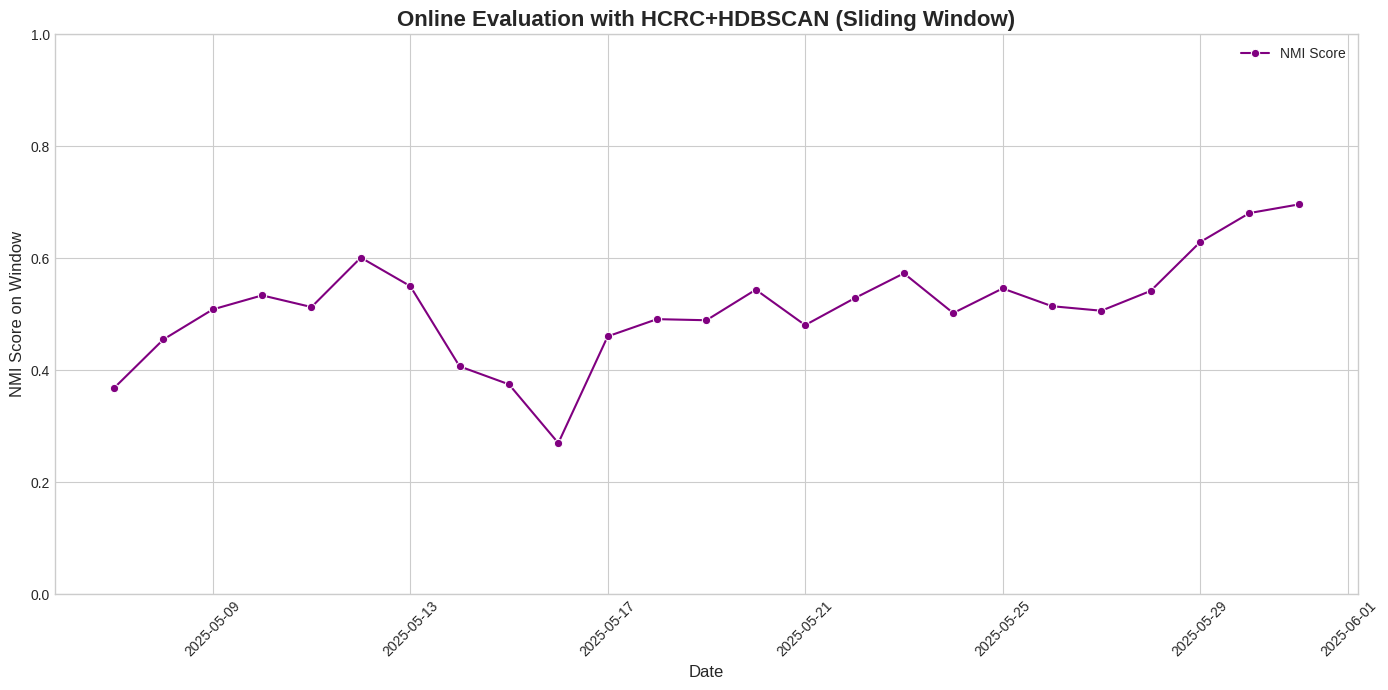

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_mbert_F.csv


In [ ]:
#@title Online Evaluation with HCRC + Full
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...")

# Define which embedding column to use
EMBEDDING_CHOICE = 'mbert_embeddings'

# Train models on the tuning set
args, unknown = parse_args()
# Pass the embedding_column parameter to the trainers
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
# Pass the embedding_column parameter to the inference functions
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)

hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function (No changes needed here) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is already correct and doesn't need changes)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                      min_samples=min_samples,
                                      metric='cosine',
                                      algorithm='generic',
                                      core_dist_n_jobs=-1)
            # predicted = clusterer.fit_predict(np.array(window_embeddings))
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 5
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_mbert_F")

🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inferenc

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:02<00:00, 11.68it/s]



🚀 Step 3: Plotting the NMI results...


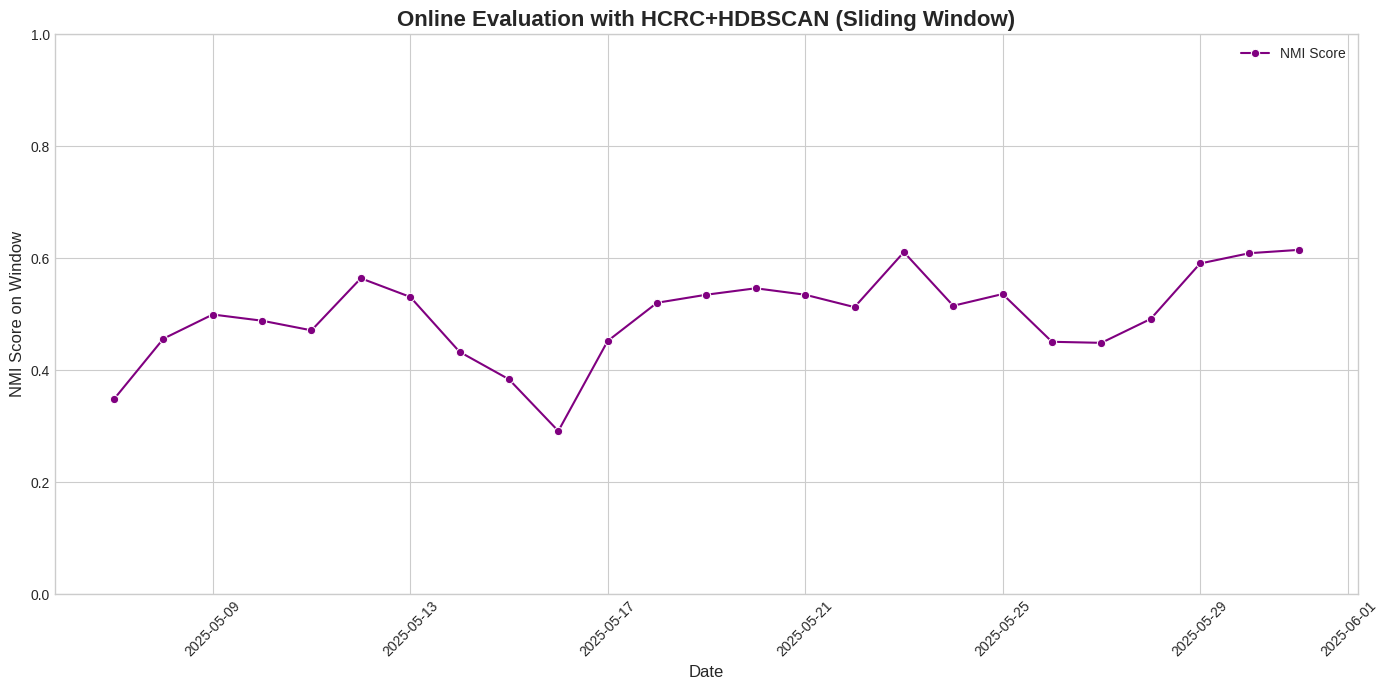

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_mbert_F_PCA128.csv


In [ ]:
#@title Online Evaluation with HCRC + Full + PCA(128)
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.decomposition import PCA
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...")

# Define which embedding column to use
EMBEDDING_CHOICE = 'mbert_embeddings'

# Train models on the tuning set
args, unknown = parse_args()
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)

# Normalize + Apply PCA(128) on hybrid embeddings
print("🎯 Reducing hybrid embeddings to 128D using PCA...")
normalized_tune = F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy()
normalized_eval = F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy()
pca = PCA(n_components=256)
pca.fit(normalized_tune)
reduced_tune = pca.transform(normalized_tune)
reduced_eval = pca.transform(normalized_eval)

# Assign to DataFrames
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(reduced_tune)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(reduced_eval)
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated and reduced for both tuning and evaluation sets.")

# --- 2. The Sliding Window Function (No changes needed here) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                        min_samples=min_samples,
                                        metric='cosine',
                                        algorithm='generic',
                                        core_dist_n_jobs=-1)
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_mbert_F_PCA128")


In [ ]:
#@title Online Evaluation with HCRC (Full Hybrid -> PCA 128) + Periodic Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.decomposition import PCA
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

def run_online_evaluation_with_retraining(
    initial_train_df,
    daily_blocks,
    min_cluster_size=15,
    min_samples=5,
    window_size=1000,
    time_window_days=3,
    maintenance_interval_days=4 # Retrain the model every 4 days
):
    """
    Performs online evaluation with a sliding window, a complex hybrid embedding,
    and periodic retraining of the models and PCA.
    """
    print(f"🚀 Starting online evaluation with retraining every {maintenance_interval_days} days...")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training and PCA Fitting ---
    print("\n--- Initial Model & PCA Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)

    pca = PCA(n_components=128, random_state=42)
    initial_final_embeddings = pca.fit_transform(hybrid_embs)
    print("✅ PCA model fitted on initial tuning data.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    window_embeddings = F.normalize(torch.tensor(initial_final_embeddings), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()
    window_dates = pd.to_datetime(initial_train_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance: Re-train models and re-fit PCA ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance: Re-training models and PCA on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model

            node_embs_all, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, all_seen_data, EMBEDDING_CHOICE)
            graph_embs_all, _ = get_graph_embeddings_from_trained_model(trained_graph_model, all_seen_data, EMBEDDING_CHOICE)
            hybrid_embs_all = np.concatenate((graph_embs_all, node_embs_all), axis=1)

            pca = PCA(n_components=128, random_state=42)
            final_embeddings_all = pca.fit_transform(hybrid_embs_all)

            window_embeddings = F.normalize(torch.tensor(final_embeddings_all), p=2, dim=1).numpy().tolist()

            # --- FIX: Ensure window_labels remains a list after regeneration ---
            window_labels = window_labels_array.tolist()

            window_dates = pd.to_datetime(all_seen_data['Date']).tolist()
            print("✅ Models and PCA re-trained.")
            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        hybrid_block_embs = np.concatenate((graph_block_embs, node_block_embs), axis=1)

        reduced_block_embs = pca.transform(hybrid_block_embs)
        reduced_block_embs_normalized = F.normalize(torch.tensor(reduced_block_embs), p=2, dim=1).numpy()

        # --- 5. Add to Window and Apply Sliding Window Logic ---
        window_embeddings.extend(reduced_block_embs_normalized.tolist())
        window_labels.extend(block_labels_array.tolist())
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered_data = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered_data:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered_data))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            start_index = len(window_embeddings) - window_size
            window_embeddings = window_embeddings[start_index:]
            window_labels = window_labels[start_index:]
            window_dates = window_dates[start_index:]

        # --- 6. Cluster and Evaluate the Current Window ---
        if len(window_embeddings) > 0 and len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples,
                                      metric='cosine', algorithm='generic', core_dist_n_jobs=-1)
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))

results_df = run_online_evaluation_with_retraining(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    min_cluster_size=6,
    min_samples=3,
    window_size=600,
    time_window_days=3,
    maintenance_interval_days=1
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi', 'ami', 'ari'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Sliding Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_HDBSCAN_Hybrid_111MFPCA128_Retraining")

🚀 Starting online evaluation with retraining every 1 days...

--- Initial Model & PCA Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
✅ PCA model fitted on initial tuning data.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:11,  2.04it/s]


🔧 Maintenance: Re-training models and PCA on 991 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 991 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 991 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
✅ Models and PCA re-trained.
   Node-level inference running on 85 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference runnin

...


🔧 Maintenance: Re-training models and PCA on 5979 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 2 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 5979 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.
   Graph-level inference running on 5979 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Models and PCA re-trained.
   Node-level inference running on 225 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference ru

Processing Daily Blocks:  88%|████████▊ | 22/25 [4:01:16<1:28:05, 1761.93s/it]

Done! It takes 0 seconds.

🔧 Maintenance: Re-training models and PCA on 6204 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 2 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 6204 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.
   Graph-level inference running on 6204 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Models and PCA re-trained.
   Node-level inference running on 277 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
 

Processing Daily Blocks:  92%|█████████▏| 23/25 [4:40:44<1:04:47, 1943.74s/it]

Done! It takes 0 seconds.

🔧 Maintenance: Re-training models and PCA on 6481 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
----Node-Level Training Start! ----



🚀 Starting online evaluation with retraining every 4 days...

--- Initial Model & PCA Training ---
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Initial models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
✅ PCA model fitted on initial tuning data.


Processing Daily Blocks:   0%|          | 0/25 [00:00<?, ?it/s]

   Node-level inference running on 57 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 57 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:   4%|▍         | 1/25 [00:00<00:03,  6.08it/s]

   Node-level inference running on 85 rows...

Building node-level social network for message block 0...


...

Done! It takes 0 seconds.
   Node-level inference running on 352 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 352 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.


Processing Daily Blocks:  96%|█████████▌| 24/25 [1:00:14<03:49, 229.72s/it]


🔧 Maintenance: Re-training models and PCA on 6833 tweets...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 4 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
   Node-level inference running on 6833 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6833 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Models and PCA re-trained.
   Node-level inference running on 165 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference ru

Processing Daily Blocks: 100%|██████████| 25/25 [1:44:59<00:00, 251.98s/it]



🚀 Plotting the results...


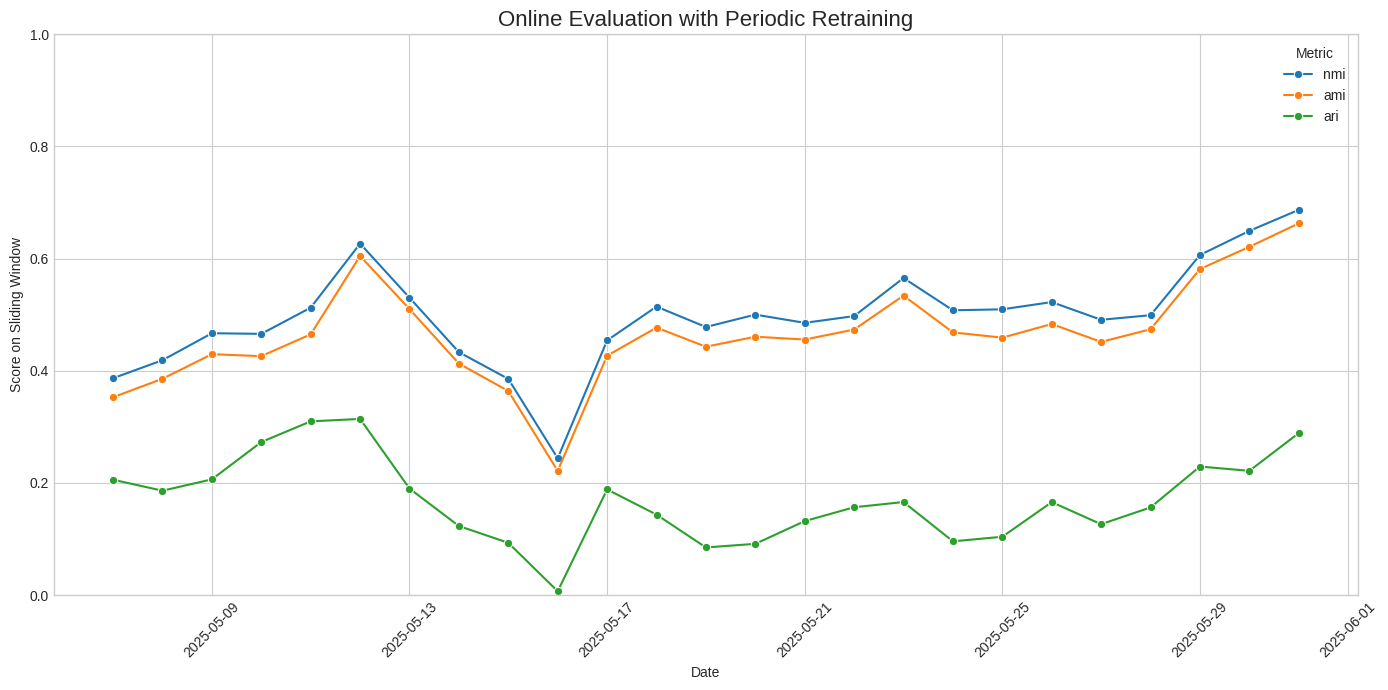

Results saved to /content/drive/MyDrive/results/HCRC_HDBSCAN_Hybrid_MFPCA128_Retraining.csv


In [ ]:
#@title Online Evaluation with HCRC (Full Hybrid -> PCA 128) + Periodic Retraining
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.decomposition import PCA
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import os

def run_online_evaluation_with_retraining(
    initial_train_df,
    daily_blocks,
    min_cluster_size=15,
    min_samples=5,
    window_size=1000,
    time_window_days=3,
    maintenance_interval_days=4 # Retrain the model every 4 days
):
    """
    Performs online evaluation with a sliding window, a complex hybrid embedding,
    and periodic retraining of the models and PCA.
    """
    print(f"🚀 Starting online evaluation with retraining every {maintenance_interval_days} days...")
    args, _ = parse_args()
    EMBEDDING_CHOICE = 'mbert_embeddings'

    # --- 1. Initial Training and PCA Fitting ---
    print("\n--- Initial Model & PCA Training ---")
    trainer_N = Node_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, initial_train_df, embedding_column=EMBEDDING_CHOICE)
    trained_graph_model = trainer_G._model
    print("✅ Initial models trained.")

    node_embs, true_labels = get_node_embeddings_from_trained_model(trained_node_model, initial_train_df, EMBEDDING_CHOICE)
    graph_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, initial_train_df, EMBEDDING_CHOICE)
    hybrid_embs = np.concatenate((graph_embs, node_embs), axis=1)

    pca = PCA(n_components=128, random_state=42)
    initial_final_embeddings = pca.fit_transform(hybrid_embs)
    print("✅ PCA model fitted on initial tuning data.")

    # --- 2. Initialize the Online Loop ---
    all_seen_data = initial_train_df.copy()
    days_since_maintenance = 0
    results = []

    window_embeddings = F.normalize(torch.tensor(initial_final_embeddings), p=2, dim=1).numpy().tolist()
    window_labels = true_labels.tolist()
    window_dates = pd.to_datetime(initial_train_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Processing Daily Blocks"):
        # --- 3. Maintenance: Re-train models and re-fit PCA ---
        if days_since_maintenance >= maintenance_interval_days:
            print(f"\n🔧 Maintenance: Re-training models and PCA on {len(all_seen_data)} tweets...")
            trainer_N = Node_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_node_model = trainer_N._model
            trainer_G = Graph_ModelTrainer(args, 0, all_seen_data, embedding_column=EMBEDDING_CHOICE)
            trained_graph_model = trainer_G._model

            node_embs_all, window_labels_array = get_node_embeddings_from_trained_model(trained_node_model, all_seen_data, EMBEDDING_CHOICE)
            graph_embs_all, _ = get_graph_embeddings_from_trained_model(trained_graph_model, all_seen_data, EMBEDDING_CHOICE)
            hybrid_embs_all = np.concatenate((graph_embs_all, node_embs_all), axis=1)

            pca = PCA(n_components=128, random_state=42)
            final_embeddings_all = pca.fit_transform(hybrid_embs_all)

            window_embeddings = F.normalize(torch.tensor(final_embeddings_all), p=2, dim=1).numpy().tolist()

            # --- FIX: Ensure window_labels remains a list after regeneration ---
            window_labels = window_labels_array.tolist()

            window_dates = pd.to_datetime(all_seen_data['Date']).tolist()
            print("✅ Models and PCA re-trained.")
            days_since_maintenance = 0

        # --- 4. Process the new daily block ---
        node_block_embs, block_labels_array = get_node_embeddings_from_trained_model(trained_node_model, block, EMBEDDING_CHOICE)
        graph_block_embs, _ = get_graph_embeddings_from_trained_model(trained_graph_model, block, EMBEDDING_CHOICE)
        hybrid_block_embs = np.concatenate((graph_block_embs, node_block_embs), axis=1)

        reduced_block_embs = pca.transform(hybrid_block_embs)
        reduced_block_embs_normalized = F.normalize(torch.tensor(reduced_block_embs), p=2, dim=1).numpy()

        # --- 5. Add to Window and Apply Sliding Window Logic ---
        window_embeddings.extend(reduced_block_embs_normalized.tolist())
        window_labels.extend(block_labels_array.tolist())
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        all_seen_data = pd.concat([all_seen_data, block], ignore_index=True)

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered_data = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered_data:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered_data))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            start_index = len(window_embeddings) - window_size
            window_embeddings = window_embeddings[start_index:]
            window_labels = window_labels[start_index:]
            window_dates = window_dates[start_index:]

        # --- 6. Cluster and Evaluate the Current Window ---
        if len(window_embeddings) > 0 and len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples,
                                      metric='cosine', algorithm='generic', core_dist_n_jobs=-1)
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
        days_since_maintenance += 1

    return pd.DataFrame(results)

# --- Execute the Workflow ---
daily_blocks_eval = dict(tuple(evaluation_df.groupby(evaluation_df['Date'].dt.date)))

results_df = run_online_evaluation_with_retraining(
    initial_train_df=tuning_df,
    daily_blocks=daily_blocks_eval,
    min_cluster_size=8,
    min_samples=5,
    window_size=1000,
    time_window_days=3,
    maintenance_interval_days=4
)

# --- Plot the results ---
if not results_df.empty:
    print("\n🚀 Plotting the results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_melted = results_df.melt(id_vars=['date'], value_vars=['nmi', 'ami', 'ari'],
                                     var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_melted, x='date', y='Score', hue='Metric', marker='o')
    plt.title('Online Evaluation with Periodic Retraining', fontsize=16)
    plt.xlabel('Date'); plt.ylabel('Score on Sliding Window')
    plt.ylim(0, 1.0); plt.xticks(rotation=45); plt.tight_layout(); plt.legend(title='Metric'); plt.show()

    save_results(results_df, model_name="/content/drive/MyDrive/results/HCRC_HDBSCAN_Hybrid_MFPCA128_Retraining")

🚀 Step 1: Preparing data...

Training Graph-Level model using 'mbert_embeddings'...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the tuning set...
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
Reducing tuning T-BERT dimension from 768 to 256...

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 4 seconds.
Reducing evaluation T-BERT dimension from 768 to 256...
✅ Hybrid embeddings created with shape: (6064, 512)

🚀 Step 2: Running online evaluation with a sliding window...


Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:02<00:00,  9.89it/s]



🚀 Step 3: Plotting the NMI results...


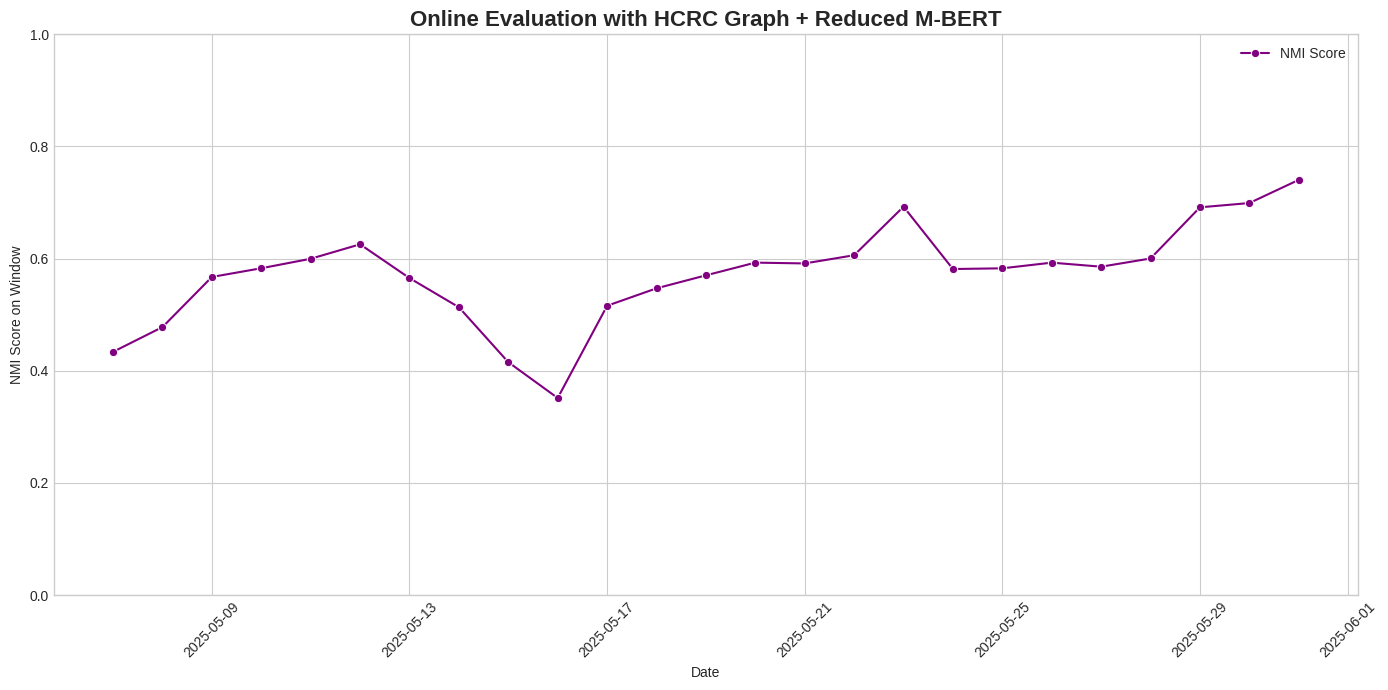

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_mbert_GT.csv


In [ ]:
#@title Online Evaluation with HCRC Graph Level + Reduced M-BERT
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

# --- 1. Train Model and Generate Embeddings ---
print("🚀 Step 1: Preparing data...")

# Define which embedding column to use as the base feature
EMBEDDING_CHOICE = 'mbert_embeddings'

# Train only the Graph-Level model on the tuning set
args, unknown = parse_args()
print(f"\nTraining Graph-Level model using '{EMBEDDING_CHOICE}'...")
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ Graph model trained.")

# --- 2. Generate Embeddings for the TUNING set ---
print("\nApplying trained model to the tuning set...")
# Get Graph GNN output
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
# Get the raw T-BERT embeddings
tbert_tune_embeddings = np.vstack(tuning_df[EMBEDDING_CHOICE].values)
# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing tuning T-BERT dimension from {tbert_tune_embeddings.shape[1]} to 256...")
pca = PCA(n_components=256, random_state=42)
reduced_tbert_tune_embeddings = pca.fit_transform(tbert_tune_embeddings)
# Concatenate them
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, reduced_tbert_tune_embeddings), axis=1)
# Add to the tuning dataframe
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())


# --- 3. Generate Embeddings for the EVALUATION set ---
print("\nApplying trained model to the evaluation set...")
# Get Graph GNN output
graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
# Get the raw T-BERT embeddings
tbert_eval_embeddings = np.vstack(evaluation_df[EMBEDDING_CHOICE].values)
# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing evaluation T-BERT dimension from {tbert_eval_embeddings.shape[1]} to 256...")
# IMPORTANT: Use the SAME pca object trained on the tuning data
reduced_tbert_eval_embeddings = pca.transform(tbert_eval_embeddings)
# Concatenate them
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, reduced_tbert_eval_embeddings), axis=1)
# Add to the evaluation dataframe
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels

print(f"✅ Hybrid embeddings created with shape: {hybrid_eval_embeddings.shape}")


# --- 4. The Sliding Window Function (No changes needed) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is correct)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='cosine',algorithm='generic', core_dist_n_jobs=-1)
            predicted_labels = clusterer.fit_predict(np.array(window_embeddings).astype(np.float64))
            nmi = normalized_mutual_info_score(window_labels, predicted_labels) if len(set(predicted_labels)) > 1 else 0.0
        else: nmi = 0.0
        results.append({'date': date, 'nmi': nmi})
    return pd.DataFrame(results)


# --- 5. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')
    plt.title('Online Evaluation with HCRC Graph + Reduced M-BERT', fontsize=16, weight='bold')
    plt.xlabel('Date')
    plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_mbert_GT")

🚀 Step 1: Training HCRC models...

Training Node-Level model using 'mbert_embeddings'...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 768

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model using 'mbert_embeddings'...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 768

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the tuning set...
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
Reducing tuning M-BERT dimension from 

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:03<00:00,  8.19it/s]



🚀 Step 3: Plotting the NMI results...


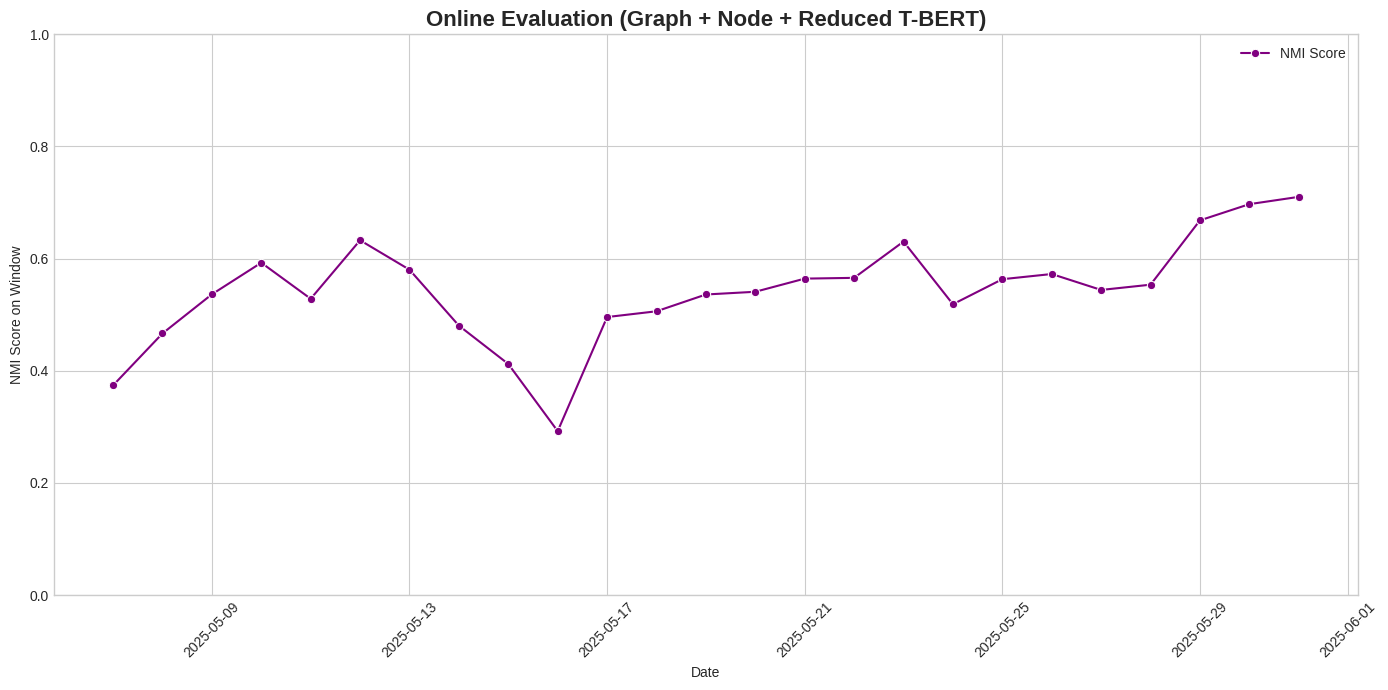

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_mbert_NGT.csv


In [ ]:
#@title Online Evaluation with HCRC (Node + Graph + Reduced T-BERT)
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

# --- 1. Train Both HCRC Models ---
print("🚀 Step 1: Training HCRC models...")

# Define which embedding column to use as the base feature
EMBEDDING_CHOICE = 'mbert_embeddings'
args, unknown = parse_args()

# --- Re-enabled Node-Level model training ---
print(f"\nTraining Node-Level model using '{EMBEDDING_CHOICE}'...")
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model

print(f"\nTraining Graph-Level model using '{EMBEDDING_CHOICE}'...")
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")


# --- 2. Generate and Combine Embeddings for the TUNING Set ---
print("\nApplying trained models to the tuning set...")
# --- Generate all THREE embedding components ---
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
tbert_tune_embeddings = np.vstack(tuning_df[EMBEDDING_CHOICE].values)

# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing tuning M-BERT dimension from {tbert_tune_embeddings.shape[1]} to 256...")
pca = PCA(n_components=256, random_state=42)
reduced_tbert_tune_embeddings = pca.fit_transform(tbert_tune_embeddings)

# --- Concatenate all THREE components for the final vector ---
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings, reduced_tbert_tune_embeddings), axis=1)

# Add to the tuning dataframe
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())


# --- 3. Generate and Combine Embeddings for the EVALUATION Set ---
print("\nApplying trained models to the evaluation set...")
graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
node_eval_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
tbert_eval_embeddings = np.vstack(evaluation_df[EMBEDDING_CHOICE].values)
reduced_tbert_eval_embeddings = pca.transform(tbert_eval_embeddings) # Use the same PCA fit

# --- Concatenate all THREE components ---
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_tbert_eval_embeddings), axis=1)

# Add to the evaluation dataframe
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print(f"✅ Final hybrid embeddings created with shape: {hybrid_eval_embeddings.shape}")


# --- 4. The Sliding Window Function (No changes needed) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is correct) ...
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='cosine',algorithm='generic', core_dist_n_jobs=-1)
            predicted_labels = clusterer.fit_predict(np.array(window_embeddings).astype(np.float64))
            nmi = normalized_mutual_info_score(window_labels, predicted_labels) if len(set(predicted_labels)) > 1 else 0.0
        else: nmi = 0.0
        results.append({'date': date, 'nmi': nmi})
    return pd.DataFrame(results)


# --- 5. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')
    plt.title('Online Evaluation (Graph + Node + Reduced T-BERT)', fontsize=16, weight='bold')
    plt.xlabel('Date')
    plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_mbert_NGT")

In [ ]:
#@title Interactive t-SNE for a Specific Day in the Sliding Window
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta, date
from sklearn.manifold import TSNE
import hdbscan
import plotly.express as px

def plot_interactive_tsne_for_sliding_window(
    date_to_plot,
    initial_df,
    daily_blocks,
    window_size,
    time_window_days,
    min_cluster_size,
    embedding_column='hybrid_embedding'
):
    """
    Reconstructs the sliding window for a specific date, runs HDBSCAN,
    and creates an interactive t-SNE plot.
    """
    print(f"🚀 Reconstructing sliding window for date: {date_to_plot}...")

    # --- 1. Reconstruct the window state for the chosen date ---
    window_df = initial_df.copy()

    # Add all blocks up to and including the target date
    for date_key, block in sorted(daily_blocks.items()):
        if date_key <= date_to_plot:
            window_df = pd.concat([window_df, block], ignore_index=True)
        else:
            break

    # Apply the time and size filters to get the exact window
    time_cutoff = pd.to_datetime(date_to_plot) - timedelta(days=time_window_days)
    window_df['Date'] = pd.to_datetime(window_df['Date'])
    window_df = window_df[window_df['Date'] >= time_cutoff]

    if len(window_df) > window_size:
        window_df = window_df.tail(window_size)

    if window_df.empty:
        print("❌ Window is empty for this date. Nothing to plot.")
        return

    print(f"✅ Window reconstructed with {len(window_df)} tweets.")

    # --- 2. Run HDBSCAN and t-SNE on the window ---
    embeddings = np.vstack(window_df[embedding_column].values)

    print("   Running HDBSCAN on the window...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', core_dist_n_jobs=-1)
    predicted_labels = clusterer.fit_predict(embeddings.astype(np.float64))

    print("   Running t-SNE (this may take a few minutes)...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
    tsne_projections = tsne.fit_transform(embeddings)

    # --- 3. Prepare data and create the interactive plot ---
    viz_df = pd.DataFrame({
        'tsne_x': tsne_projections[:, 0],
        'tsne_y': tsne_projections[:, 1],
        'tweet_text': window_df['Old Tweet Text'].values,
        'cluster_id': predicted_labels.astype(str)
    })

    print("\n🚀 Generating interactive plot...")
    fig = px.scatter(
        viz_df,
        x='tsne_x',
        y='tsne_y',
        color='cluster_id',
        hover_data={'tweet_text': True, 'tsne_x': False, 'tsne_y': False},
        title=f'Interactive t-SNE of Sliding Window on {date_to_plot}'
    )
    fig.update_layout(width=950, height=800, legend_title_text='Cluster ID')
    fig.show()

# --- Parameters for Visualization ---
# !!! CHOOSE THE DATE YOU WANT TO VISUALIZE HERE !!!
# It must be a date within your evaluation period.
DATE_TO_PLOT = date(2025, 5, 20)

# Use the same parameters as your online evaluation script
MIN_CLUSTER_SIZE_VIZ = 8
WINDOW_MAX_TWEETS_VIZ = 1000
WINDOW_MAX_DAYS_VIZ = 3

# --- Execute the Visualization ---
# This assumes 'tuning_df_with_embs' and 'eval_df_with_embs' are available
if 'tuning_df_with_embs' in locals() and 'eval_df_with_embs' in locals():
    daily_blocks_viz = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

    plot_interactive_tsne_for_sliding_window(
        date_to_plot=DATE_TO_PLOT,
        initial_df=tuning_df_with_embs,
        daily_blocks=daily_blocks_viz,
        window_size=WINDOW_MAX_TWEETS_VIZ,
        time_window_days=WINDOW_MAX_DAYS_VIZ,
        min_cluster_size=MIN_CLUSTER_SIZE_VIZ
    )
else:
    print("❌ Error: Please run the main evaluation script first to generate the necessary dataframes.")

🚀 Reconstructing sliding window for date: 2025-05-20...
✅ Window reconstructed with 780 tweets.
   Running HDBSCAN on the window...
   Running t-SNE (this may take a few minutes)...

🚀 Generating interactive plot...


## tbert

In [ ]:
#@title hdbscan + node level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models (Reusing previous logic) ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    # trainer_G = Graph_ModelTrainer(args, 0, train_df)
    # trained_graph_model = trainer_G._model
    # print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings (Reusing previous logic) ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df)
    # graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)

    # if len(graph_eval_embeddings) != len(node_eval_embeddings):
    #      raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Node: {len(node_eval_embeddings)}")

    hybrid_embeddings = node_eval_embeddings#np.concatenate((node_eval_embeddings), axis=1)

    # Normalize final embeddings before clustering
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings, min_cluster_size=4,min_samples=3)

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Node-Level model...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
✅ Hybrid embeddings created with shape: (6064, 256)

Running HDBSCAN with min_cluster_size=4...
✅ HDBSCAN found 122 clusters and 4929 noise points.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.2855 **
  ** AMI: 0.1835 **
  ** ARI: 0.0073 **

************ HDBSCAN Evaluation Finished ************


In [ ]:
#@title hdbscan + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

# --- Initialize the global variable that will store the embeddings ---
hybrid_embeddings_for_viz = None
eval_df_for_viz = None
# --------------------------------------------------------------------

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    # --- Declare that we will modify the global variables ---
    global hybrid_embeddings_for_viz, eval_df_for_viz
    # --------------------------------------------------------

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models ---
    args, unknown = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df)
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)
    hybrid_embeddings = graph_eval_embeddings # np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Save results to the global variables for the next cell ---
    hybrid_embeddings_for_viz = hybrid_embeddings
    eval_df_for_viz = eval_df.copy()
    # --------------------------------------------------------------------

    # --- 4. Run HDBSCAN Clustering & Evaluate ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings.astype(np.float64), min_cluster_size=10)
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)
    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **")
    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ HDBSCAN Evaluation Finished ************")

# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
✅ Hybrid embeddings created with shape: (6064, 256)

Running HDBSCAN with min_cluster_size=10...
✅ HDBSCAN found 13 clusters and 0 noise points.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.7226 **
  ** AMI: 0

In [ ]:
#@title hdbscan + PCA on mBERT + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains Graph GNN, reduces mBERT embeddings with PCA, concatenates them, and clusters.
    """
    global hybrid_embeddings_for_viz, eval_df_for_viz

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Only the Graph-Level Model ---
    args, unknown = parse_args()
    # We don't need the Node model for this approach
    trainer_N = Node_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    # Get the embeddings from the Graph GNN
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)
    # node_eval_embeddings, eval_true_labels =  get_node_embeddings_from_trained_model(trained_graph_model, eval_df)
    # Get the original AraBERT embeddings and convert to a 2D matrix
    arabert_eval_embeddings = np.vstack(eval_df['tbert_embeddings'].values)

    # --- 3. Reduce Dimension of AraBERT embeddings with PCA ---
    print(f"\nReducing mBERT dimension from {arabert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    reduced_arabert_embeddings = pca.fit_transform(arabert_eval_embeddings)

    print(f"Reduced maBERT shape: {reduced_arabert_embeddings.shape}")
    # -------------------------------------------------------------

    # --- 4. Concatenate Graph Embeddings with REDUCED AraBERT Embeddings ---
    if len(graph_eval_embeddings) != len(reduced_arabert_embeddings):
        raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Reduced mBERT: {len(reduced_arabert_embeddings)}")

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, reduced_arabert_embeddings), axis=1)
    # --------------------------------------------------------------------------

    # Normalize the final hybrid embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the visualization cell
    hybrid_embeddings_for_viz = final_embeddings
    eval_df_for_viz = eval_df.copy()

    # --- 5. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(final_embeddings.astype(np.float64), min_cluster_size=4,min_samples=3)

    # --- 6. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.

Reducing mBERT dimension from 768 to 256 using PCA...
Reduced maBERT shape: (6064, 256)
✅ Final hybrid embeddings created with shape: (6064, 512)

Running HDBSCAN with min_cluster_size=4...
✅ HDBSCAN found 179 clusters and 3915 noise points.

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.4420 **
  ** AMI: 0.331

In [ ]:
#@title hdbscan + PCA on tBERT + graph level + node

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains Graph GNN, reduces mBERT embeddings with PCA, concatenates them, and clusters.
    """
    global hybrid_embeddings_for_viz, eval_df_for_viz

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Only the Graph-Level Model ---
    args, unknown = parse_args()
    # We don't need the Node model for this approach
    trainer_N = Node_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    # Get the embeddings from the Graph GNN
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)
    node_eval_embeddings, eval_true_labels =  get_node_embeddings_from_trained_model(trained_node_model, eval_df)
    # Get the original tuned BERT embeddings and convert to a 2D matrix
    arabert_eval_embeddings = np.vstack(eval_df['tbert_embeddings'].values)

    # --- 3. Reduce Dimension of tuned BERT embeddings with PCA ---
    print(f"\nReducing AraBERT dimension from {arabert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    reduced_arabert_embeddings = pca.fit_transform(arabert_eval_embeddings)

    print(f"Reduced MBERT shape: {reduced_arabert_embeddings.shape}")
    # -------------------------------------------------------------

    # --- 4. Concatenate Graph Embeddings with REDUCED AraBERT Embeddings ---
    if len(graph_eval_embeddings) != len(reduced_arabert_embeddings):
        raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Reduced MBERT: {len(reduced_arabert_embeddings)}")

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_arabert_embeddings), axis=1)
    # --------------------------------------------------------------------------

    # Normalize the final hybrid embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the visualization cell
    hybrid_embeddings_for_viz = final_embeddings
    eval_df_for_viz = eval_df.copy()

    # --- 5. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(final_embeddings.astype(np.float64), min_cluster_size=4,min_samples=3)

    # --- 6. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.

Reducing AraBERT dimension from 768 to 256 using PCA...
Reduced MBERT shape: (6064, 256)
✅ Final hybrid embeddings created with shape: (6064, 768)

Running HDBSCAN with min_cluster_size=4...
✅

In [ ]:
#@title Interactive t-SNE Visualization of HDBSCAN Clusters

import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import hdbscan
import plotly.express as px

# Check if the variables from the previous cell exist
if 'hybrid_embeddings_for_viz' not in locals() or 'eval_df_for_viz' not in locals():
    print("❌ Error: Please run the main evaluation script first to generate the hybrid embeddings.")
else:
    print("🚀 Starting interactive t-SNE visualization...")

    MIN_CLUSTER_SIZE_FOR_VIZ = 4

    print(f"   Running HDBSCAN with min_cluster_size={MIN_CLUSTER_SIZE_FOR_VIZ}...")
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE_FOR_VIZ,
        metric='cosine',
        algorithm='generic',# Use the supported 'euclidean' metric
        core_dist_n_jobs=-1
    )
    predicted_labels = clusterer.fit_predict(hybrid_embeddings_for_viz.astype(np.float64))
    print("✅ Clustering complete.")

    print("   Running t-SNE to reduce dimensions (this may take a few minutes)...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
    tsne_projections = tsne.fit_transform(hybrid_embeddings_for_viz)
    print("✅ t-SNE projection complete.")

    # Prepare the data for plotting
    viz_df = pd.DataFrame({
        'tsne_x': tsne_projections[:, 0],
        'tsne_y': tsne_projections[:, 1],
        'tweet_text': evaluation_df['Tweet Text'].values,
        'cluster_id': predicted_labels.astype(str)
    })

    print("\n🚀 Generating interactive plot...")
    fig = px.scatter(
        viz_df,
        x='tsne_x',
        y='tsne_y',
        color='cluster_id',
        hover_data={'tweet_text': True, 'tsne_x': False, 'tsne_y': False},
        title=f'Interactive t-SNE of HDBSCAN Clusters (min_cluster_size={MIN_CLUSTER_SIZE_FOR_VIZ})'
    )
    fig.update_layout(width=900, height=700, legend_title_text='Cluster ID')
    fig.show()

🚀 Starting interactive t-SNE visualization...
   Running HDBSCAN with min_cluster_size=4...
✅ Clustering complete.
   Running t-SNE to reduce dimensions (this may take a few minutes)...
✅ t-SNE projection complete.

🚀 Generating interactive plot...


In [ ]:
#@title hdbscan + node level + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models (Reusing previous logic) ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'tbert_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings (Reusing previous logic) ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df)
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)

    if len(graph_eval_embeddings) != len(node_eval_embeddings):
         raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Node: {len(node_eval_embeddings)}")

    hybrid_embeddings = np.concatenate((node_eval_embeddings,graph_eval_embeddings), axis=1)

    # Normalize final embeddings before clustering
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings, min_cluster_size=4,min_samples=3)

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Node-Level model...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Hybrid embeddings created with shape: (6064, 512)

Running HDBSCAN with min_cluster_size=4...
✅ HDBSCAN found 142 clusters and 4843 noise points.

📊 Final Perfor

🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:02<00:00, 10.82it/s]



🚀 Step 3: Plotting the NMI results...


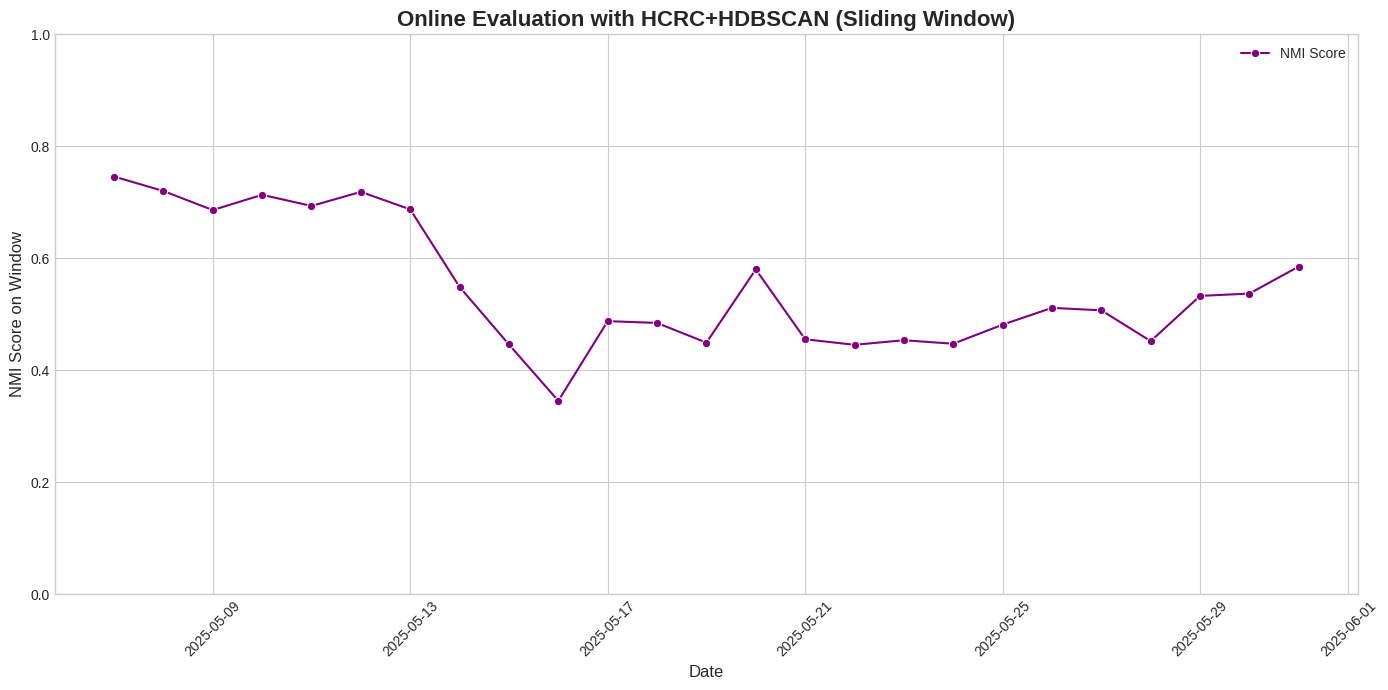

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_tbert_N.csv


In [ ]:
#@title Online Evaluation with only node level
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...")

# Define which embedding column to use
EMBEDDING_CHOICE = 'tbert_embeddings'

# Train models on the tuning set
args, unknown = parse_args()
# Pass the embedding_column parameter to the trainers
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
# Pass the embedding_column parameter to the inference functions
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)

hybrid_tune_embeddings = node_tune_embeddings #np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = node_eval_embeddings #np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function (No changes needed here) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is already correct and doesn't need changes)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                      min_samples=min_samples,
                                      metric='cosine',
                                      algorithm='generic',
                                      core_dist_n_jobs=-1)
            # predicted = clusterer.fit_predict(np.array(window_embeddings))
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 5
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_tbert_N")

🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:03<00:00,  6.64it/s]



🚀 Step 3: Plotting the NMI results...


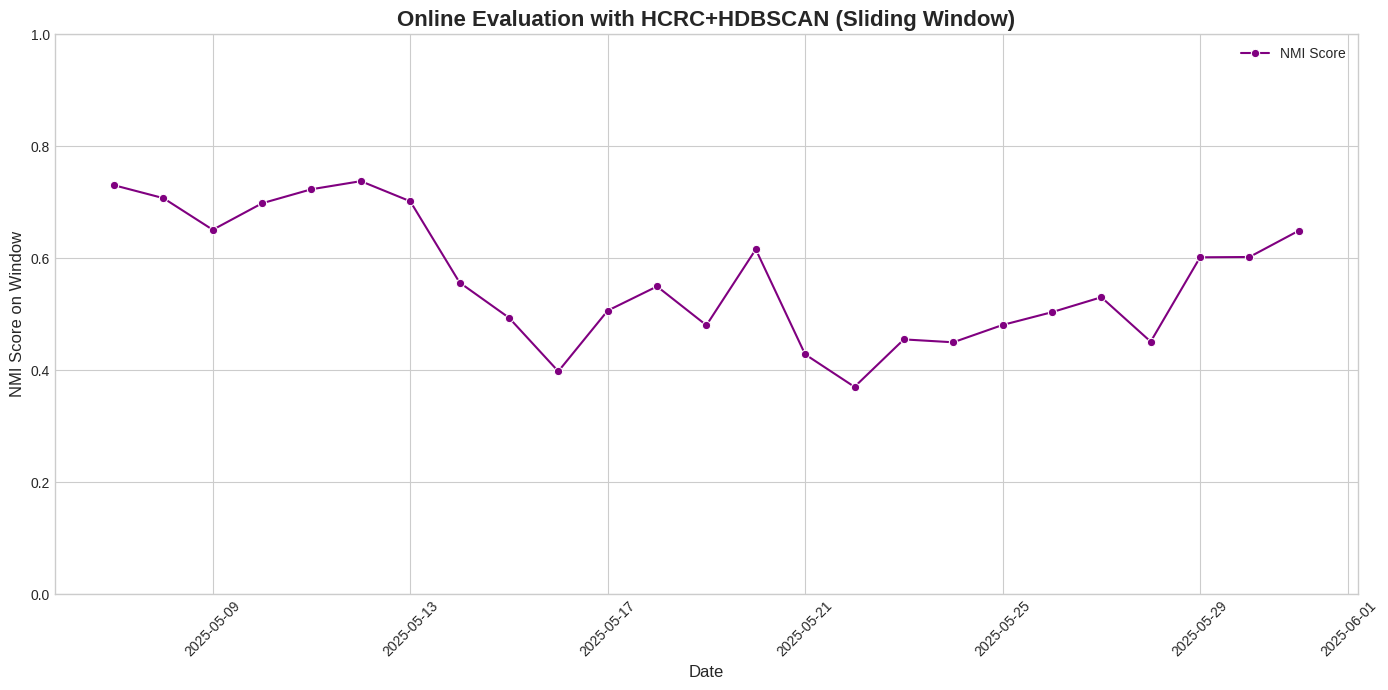

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_tbert_F.csv


In [ ]:
#@title Online Evaluation with HCRC + Full
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...")

# Define which embedding column to use
EMBEDDING_CHOICE = 'tbert_embeddings'

# Train models on the tuning set
args, unknown = parse_args()
# Pass the embedding_column parameter to the trainers
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
# Pass the embedding_column parameter to the inference functions
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)

hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function (No changes needed here) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is already correct and doesn't need changes)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                      min_samples=min_samples,
                                      metric='cosine',
                                      algorithm='generic',
                                      core_dist_n_jobs=-1)
            # predicted = clusterer.fit_predict(np.array(window_embeddings))
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 5
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_tbert_F")

🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:03<00:00,  7.48it/s]



🚀 Step 3: Plotting the NMI results...


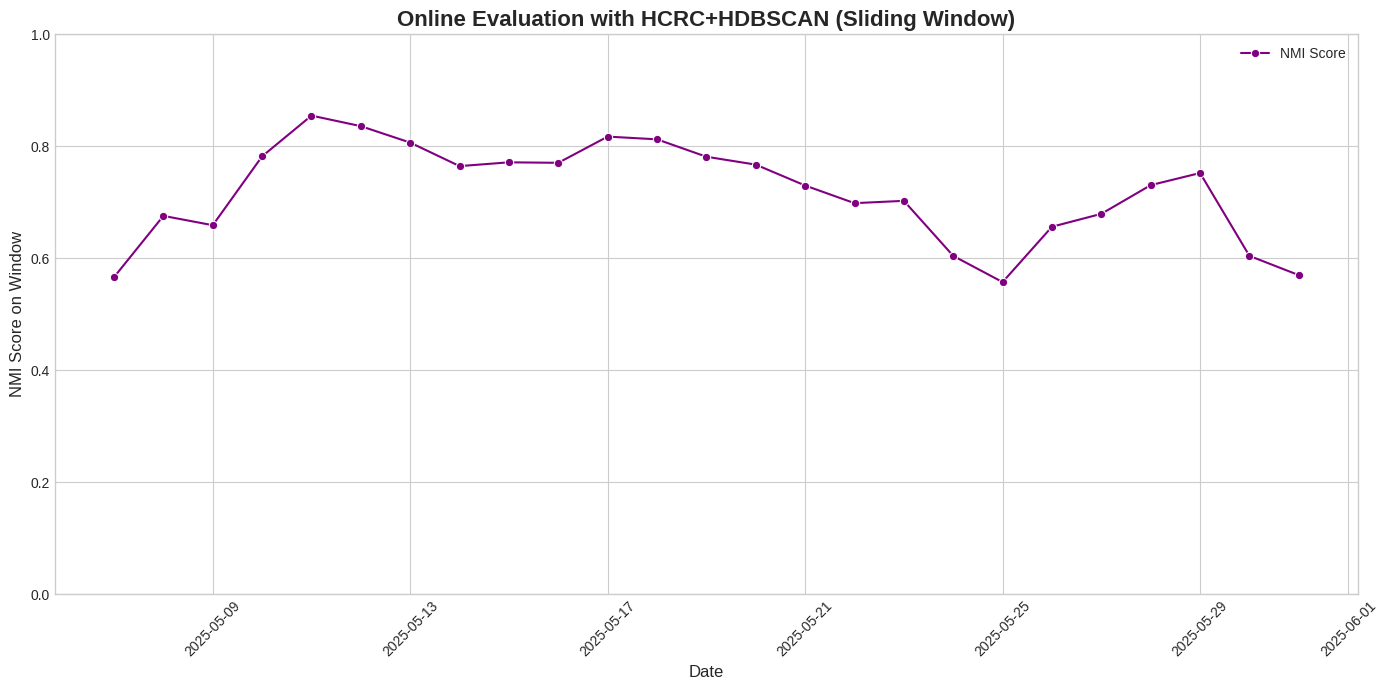

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_tbert_G.csv


In [ ]:
#@title Online Evaluation with HCRC  only graph
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from hdbscan import HDBSCAN
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...")

# Define which embedding column to use
EMBEDDING_CHOICE = 'tbert_embeddings'

# Train models on the tuning set
args, unknown = parse_args()
# Pass the embedding_column parameter to the trainers
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
# Pass the embedding_column parameter to the inference functions
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)

hybrid_tune_embeddings = graph_tune_embeddings#np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = graph_eval_embeddings#np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function (No changes needed here) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is already correct and doesn't need changes)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = HDBSCAN(min_cluster_size=min_cluster_size,
                                      min_samples=min_samples,
                                      metric='cosine',
                                      algorithm='generic',
                                      core_dist_n_jobs=-1)
            # predicted = clusterer.fit_predict(np.array(window_embeddings))
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_tbert_G")

🚀 Step 1: Preparing data...

Training Graph-Level model using 'tbert_embeddings'...
CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the tuning set...
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
Reducing tuning T-BERT dimension from 768 to 256...

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
Reducing evaluation T-BERT dimension from 768 to 256...
✅ Hybrid embeddings created with shape: (6064, 512)

🚀 Step 2: Running online evaluation with a sliding window...


Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:22<00:00,  1.12it/s]



🚀 Step 3: Plotting the NMI results...


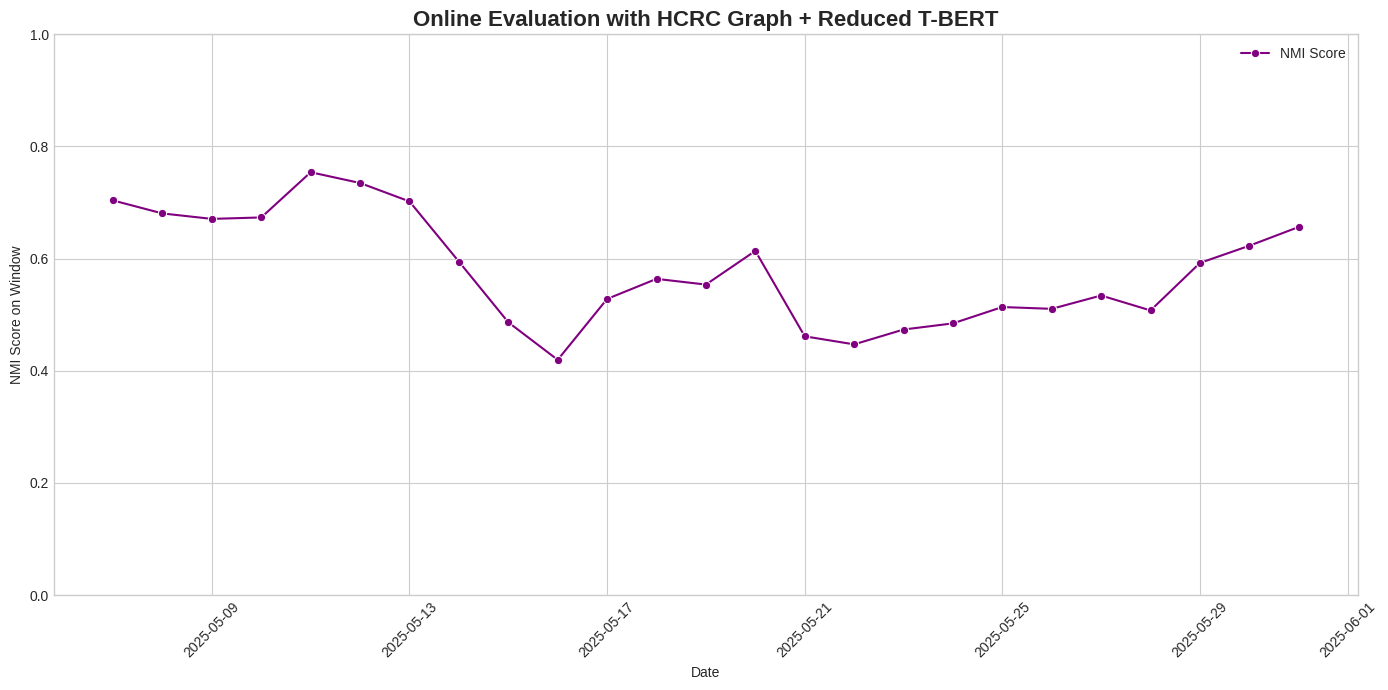

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_tbert_GT.csv


In [ ]:
#@title Online Evaluation with HCRC Graph Level + Reduced T-BERT
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

# --- 1. Train Model and Generate Embeddings ---
print("🚀 Step 1: Preparing data...")

# Define which embedding column to use as the base feature
EMBEDDING_CHOICE = 'tbert_embeddings'

# Train only the Graph-Level model on the tuning set
args, unknown = parse_args()
print(f"\nTraining Graph-Level model using '{EMBEDDING_CHOICE}'...")
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ Graph model trained.")

# --- 2. Generate Embeddings for the TUNING set ---
print("\nApplying trained model to the tuning set...")
# Get Graph GNN output
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
# Get the raw T-BERT embeddings
tbert_tune_embeddings = np.vstack(tuning_df[EMBEDDING_CHOICE].values)
# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing tuning T-BERT dimension from {tbert_tune_embeddings.shape[1]} to 256...")
pca = PCA(n_components=256, random_state=42)
reduced_tbert_tune_embeddings = pca.fit_transform(tbert_tune_embeddings)
# Concatenate them
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, reduced_tbert_tune_embeddings), axis=1)
# Add to the tuning dataframe
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())


# --- 3. Generate Embeddings for the EVALUATION set ---
print("\nApplying trained model to the evaluation set...")
# Get Graph GNN output
graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
# Get the raw T-BERT embeddings
tbert_eval_embeddings = np.vstack(evaluation_df[EMBEDDING_CHOICE].values)
# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing evaluation T-BERT dimension from {tbert_eval_embeddings.shape[1]} to 256...")
# IMPORTANT: Use the SAME pca object trained on the tuning data
reduced_tbert_eval_embeddings = pca.transform(tbert_eval_embeddings)
# Concatenate them
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, reduced_tbert_eval_embeddings), axis=1)
# Add to the evaluation dataframe
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels

print(f"✅ Hybrid embeddings created with shape: {hybrid_eval_embeddings.shape}")


# --- 4. The Sliding Window Function (No changes needed) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is correct)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='euclidean', core_dist_n_jobs=-1)
            predicted_labels = clusterer.fit_predict(np.array(window_embeddings).astype(np.float64))
            nmi = normalized_mutual_info_score(window_labels, predicted_labels) if len(set(predicted_labels)) > 1 else 0.0
        else: nmi = 0.0
        results.append({'date': date, 'nmi': nmi})
    return pd.DataFrame(results)


# --- 5. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')
    plt.title('Online Evaluation with HCRC Graph + Reduced T-BERT', fontsize=16, weight='bold')
    plt.xlabel('Date')
    plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_tbert_GT")

🚀 Step 1: Training HCRC models...

Training Node-Level model using 'tbert_embeddings'...
CUDA not available, using cpu

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model using 'tbert_embeddings'...
CUDA not available, using cpu

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the tuning set...
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
Reducing tuning T-BERT dimension from 768 to 256...

Applying trained models to the evaluation set...
   Graph-level inference running on 606

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [03:23<00:00,  8.14s/it]



🚀 Step 3: Plotting the NMI results...


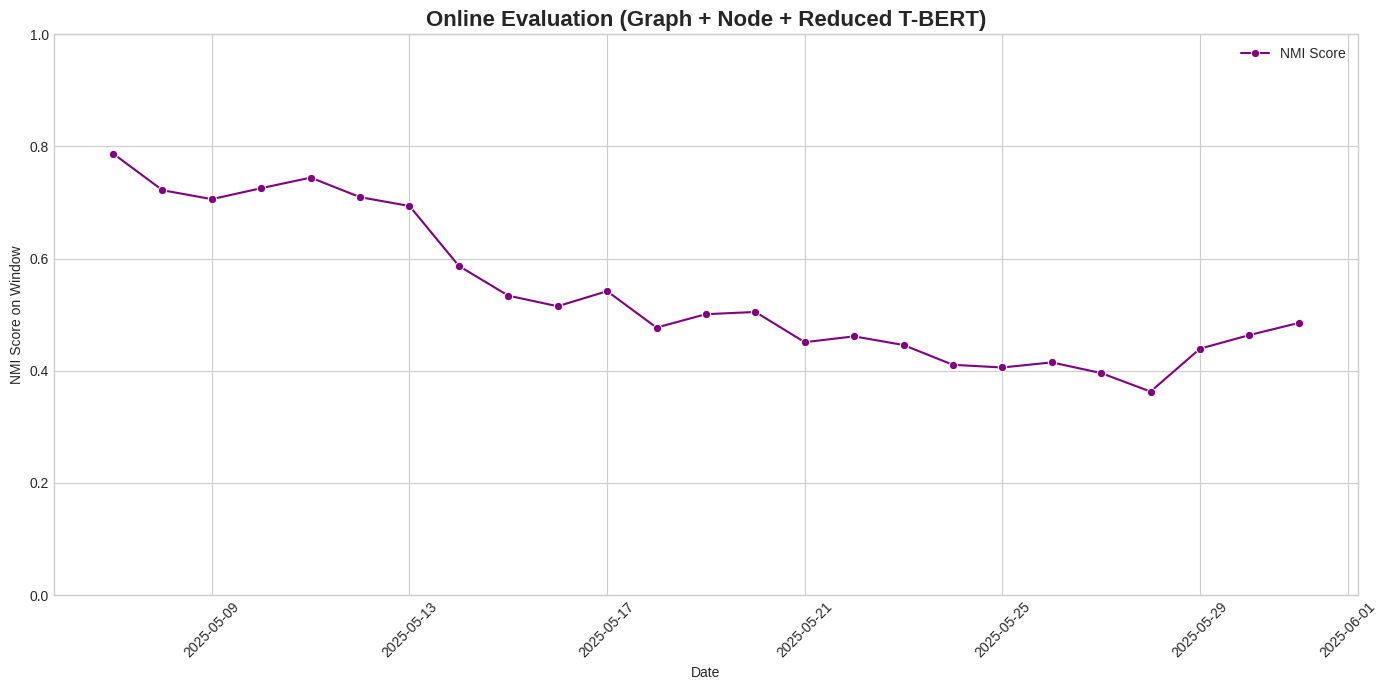

In [ ]:
#@title Online Evaluation with HCRC (Node + Graph + Reduced T-BERT)
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

# --- 1. Train Both HCRC Models ---
print("🚀 Step 1: Training HCRC models...")

# Define which embedding column to use as the base feature
EMBEDDING_CHOICE = 'tbert_embeddings'
args, unknown = parse_args()

# --- Re-enabled Node-Level model training ---
print(f"\nTraining Node-Level model using '{EMBEDDING_CHOICE}'...")
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model

print(f"\nTraining Graph-Level model using '{EMBEDDING_CHOICE}'...")
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")


# --- 2. Generate and Combine Embeddings for the TUNING Set ---
print("\nApplying trained models to the tuning set...")
# --- Generate all THREE embedding components ---
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
tbert_tune_embeddings = np.vstack(tuning_df[EMBEDDING_CHOICE].values)

# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing tuning T-BERT dimension from {tbert_tune_embeddings.shape[1]} to 256...")
pca = PCA(n_components=256, random_state=42)
reduced_tbert_tune_embeddings = pca.fit_transform(tbert_tune_embeddings)

# --- Concatenate all THREE components for the final vector ---
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings, reduced_tbert_tune_embeddings), axis=1)

# Add to the tuning dataframe
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())


# --- 3. Generate and Combine Embeddings for the EVALUATION Set ---
print("\nApplying trained models to the evaluation set...")
graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
node_eval_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
tbert_eval_embeddings = np.vstack(evaluation_df[EMBEDDING_CHOICE].values)
reduced_tbert_eval_embeddings = pca.transform(tbert_eval_embeddings) # Use the same PCA fit

# --- Concatenate all THREE components ---
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_tbert_eval_embeddings), axis=1)

# Add to the evaluation dataframe
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print(f"✅ Final hybrid embeddings created with shape: {hybrid_eval_embeddings.shape}")


# --- 4. The Sliding Window Function (No changes needed) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is correct) ...
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='euclidean', core_dist_n_jobs=-1)
            predicted_labels = clusterer.fit_predict(np.array(window_embeddings).astype(np.float64))
            nmi = normalized_mutual_info_score(window_labels, predicted_labels) if len(set(predicted_labels)) > 1 else 0.0
        else: nmi = 0.0
        results.append({'date': date, 'nmi': nmi})
    return pd.DataFrame(results)


# --- 5. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 8
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')
    plt.title('Online Evaluation (Graph + Node + Reduced T-BERT)', fontsize=16, weight='bold')
    plt.xlabel('Date')
    plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_tbert_NGT")

## distilli mbert

In [ ]:
#@title hdbscan + node level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models (Reusing previous logic) ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    # trainer_G = Graph_ModelTrainer(args, 0, train_df)
    # trained_graph_model = trainer_G._model
    # print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings (Reusing previous logic) ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df,'distilled_embeddings')
    # graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df)

    # if len(graph_eval_embeddings) != len(node_eval_embeddings):
    #      raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Node: {len(node_eval_embeddings)}")

    hybrid_embeddings = node_eval_embeddings#np.concatenate((node_eval_embeddings), axis=1)

    # Normalize final embeddings before clustering
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings, min_cluster_size=4,min_samples=3)

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Node-Level model...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 384

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 3 seconds.
✅ Hybrid embeddings created with shape: (6064, 256)

Running HDBSCAN with min_cluster_size=4...
✅ HDBSCAN found 158 clusters 

📊 Final Performance Metrics on Evaluation Set:
  ** NMI: 0.3736 **
  ** AMI: 0.2644 **
  ** ARI: 0.0131 **

************ HDBSCAN Evaluation Finished ************


In [ ]:
#@title hdbscan + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

# --- Initialize the global variable that will store the embeddings ---
hybrid_embeddings_for_viz = None
eval_df_for_viz = None
# --------------------------------------------------------------------

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    # --- Declare that we will modify the global variables ---
    global hybrid_embeddings_for_viz, eval_df_for_viz
    # --------------------------------------------------------

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models ---
    args, unknown = parse_args()
    trainer_N = Node_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_node_model = trainer_N._model
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df,'distilled_embeddings')
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df,'distilled_embeddings')
    hybrid_embeddings = graph_eval_embeddings # np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Save results to the global variables for the next cell ---
    hybrid_embeddings_for_viz = hybrid_embeddings
    eval_df_for_viz = eval_df.copy()
    # --------------------------------------------------------------------

    # --- 4. Run HDBSCAN Clustering & Evaluate ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings.astype(np.float64), min_cluster_size=8)
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
    ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
    ari = adjusted_rand_score(eval_true_labels, predicted_labels)
    print(f"  ** NMI: {nmi:.4f} **")
    print(f"  ** AMI: {ami:.4f} **")
    print(f"  ** ARI: {ari:.4f} **")
    print("\n************ HDBSCAN Evaluation Finished ************")

# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 384

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 384

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 4 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Hybrid embeddings created with shape: (6064, 256)

Running HDBSCAN with min_cluster_size=8...
✅ HDBSCAN found 13 cluste

In [ ]:
#@title hdbscan + PCA on distilli BERT + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains Graph GNN, reduces mBERT embeddings with PCA, concatenates them, and clusters.
    """
    global hybrid_embeddings_for_viz, eval_df_for_viz

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Only the Graph-Level Model ---
    args, unknown = parse_args()
    # We don't need the Node model for this approach
    trainer_N = Node_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    # Get the embeddings from the Graph GNN
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df,'distilled_embeddings')
    # node_eval_embeddings, eval_true_labels =  get_node_embeddings_from_trained_model(trained_graph_model, eval_df)
    # Get the original AraBERT embeddings and convert to a 2D matrix
    arabert_eval_embeddings = np.vstack(eval_df['distilled_embeddings'].values)

    # --- 3. Reduce Dimension of AraBERT embeddings with PCA ---
    print(f"\nReducing mBERT dimension from {arabert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    reduced_arabert_embeddings = pca.fit_transform(arabert_eval_embeddings)

    print(f"Reduced maBERT shape: {reduced_arabert_embeddings.shape}")
    # -------------------------------------------------------------

    # --- 4. Concatenate Graph Embeddings with REDUCED AraBERT Embeddings ---
    if len(graph_eval_embeddings) != len(reduced_arabert_embeddings):
        raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Reduced mBERT: {len(reduced_arabert_embeddings)}")

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, reduced_arabert_embeddings), axis=1)
    # --------------------------------------------------------------------------

    # Normalize the final hybrid embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the visualization cell
    hybrid_embeddings_for_viz = final_embeddings
    eval_df_for_viz = eval_df.copy()

    # --- 5. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(final_embeddings.astype(np.float64), min_cluster_size=4,min_samples=3)

    # --- 6. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 384

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 384

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 4 seconds.

Reducing mBERT dimension from 384 to 256 using PCA...
Reduced maBERT shape: (6064, 256)
✅ Final hybrid embeddings created with shape: (6064, 512)

Running HDBSCAN with min_cluster_size=4...
✅ HDBSCAN found 165 clusters 

📊

In [ ]:
#@title hdbscan + PCA on distilli + graph level + node

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains Graph GNN, reduces mBERT embeddings with PCA, concatenates them, and clusters.
    """
    global hybrid_embeddings_for_viz, eval_df_for_viz

    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Only the Graph-Level Model ---
    args, unknown = parse_args()
    # We don't need the Node model for this approach
    trainer_N = Node_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ Graph model trained.")

    # --- 2. Generate and Combine Embeddings ---
    print("\nApplying trained model to the evaluation set...")
    # Get the embeddings from the Graph GNN
    graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df,'distilled_embeddings')
    node_eval_embeddings, eval_true_labels =  get_node_embeddings_from_trained_model(trained_node_model, eval_df,'distilled_embeddings')
    # Get the original AraBERT embeddings and convert to a 2D matrix
    arabert_eval_embeddings = np.vstack(eval_df['distilled_embeddings'].values)

    # --- 3. Reduce Dimension of AraBERT embeddings with PCA ---
    print(f"\nReducing AraBERT dimension from {arabert_eval_embeddings.shape[1]} to 256 using PCA...")
    pca = PCA(n_components=256, random_state=42)
    reduced_arabert_embeddings = pca.fit_transform(arabert_eval_embeddings)

    print(f"Reduced MBERT shape: {reduced_arabert_embeddings.shape}")
    # -------------------------------------------------------------

    # --- 4. Concatenate Graph Embeddings with REDUCED AraBERT Embeddings ---
    if len(graph_eval_embeddings) != len(reduced_arabert_embeddings):
        raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Reduced distilli BERT: {len(reduced_arabert_embeddings)}")

    hybrid_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_arabert_embeddings), axis=1)
    # --------------------------------------------------------------------------

    # Normalize the final hybrid embeddings
    final_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()
    print(f"✅ Final hybrid embeddings created with shape: {final_embeddings.shape}")

    # Save results for the visualization cell
    hybrid_embeddings_for_viz = final_embeddings
    eval_df_for_viz = eval_df.copy()

    # --- 5. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(final_embeddings.astype(np.float64), min_cluster_size=3,min_samples=2)

    # --- 6. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 384

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 384

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 1 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.

Reducing AraBERT dimension from 384 to 256 using PCA...
Reduced MBERT shape: (6064, 256)


In [ ]:
#@title Interactive t-SNE Visualization of HDBSCAN Clusters

import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import hdbscan
import plotly.express as px

# Check if the variables from the previous cell exist
if 'hybrid_embeddings_for_viz' not in locals() or 'eval_df_for_viz' not in locals():
    print("❌ Error: Please run the main evaluation script first to generate the hybrid embeddings.")
else:
    print("🚀 Starting interactive t-SNE visualization...")

    MIN_CLUSTER_SIZE_FOR_VIZ = 4

    print(f"   Running HDBSCAN with min_cluster_size={MIN_CLUSTER_SIZE_FOR_VIZ}...")
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE_FOR_VIZ,
        metric='cosine',
        algorithm='generic',# Use the supported 'euclidean' metric
        core_dist_n_jobs=-1
    )
    predicted_labels = clusterer.fit_predict(hybrid_embeddings_for_viz.astype(np.float64))
    print("✅ Clustering complete.")

    print("   Running t-SNE to reduce dimensions (this may take a few minutes)...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
    tsne_projections = tsne.fit_transform(hybrid_embeddings_for_viz)
    print("✅ t-SNE projection complete.")

    # Prepare the data for plotting
    viz_df = pd.DataFrame({
        'tsne_x': tsne_projections[:, 0],
        'tsne_y': tsne_projections[:, 1],
        'tweet_text': evaluation_df['Tweet Text'].values,
        'cluster_id': predicted_labels.astype(str)
    })

    print("\n🚀 Generating interactive plot...")
    fig = px.scatter(
        viz_df,
        x='tsne_x',
        y='tsne_y',
        color='cluster_id',
        hover_data={'tweet_text': True, 'tsne_x': False, 'tsne_y': False},
        title=f'Interactive t-SNE of HDBSCAN Clusters (min_cluster_size={MIN_CLUSTER_SIZE_FOR_VIZ})'
    )
    fig.update_layout(width=900, height=700, legend_title_text='Cluster ID')
    fig.show()

🚀 Starting interactive t-SNE visualization...
   Running HDBSCAN with min_cluster_size=4...
✅ Clustering complete.
   Running t-SNE to reduce dimensions (this may take a few minutes)...
✅ t-SNE projection complete.

🚀 Generating interactive plot...


In [ ]:
#@title hdbscan + node level + graph level

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score

def run_evaluation_with_hdbscan(train_df, eval_df):
    """
    Trains the HCRC models, then clusters the resulting embeddings with HDBSCAN.
    """
    print("🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...")

    # --- 1. Train Models (Reusing previous logic) ---
    args, unknown = parse_args()
    print("\nTraining Node-Level model...")
    trainer_N = Node_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_node_model = trainer_N._model

    print("\nTraining Graph-Level model...")
    trainer_G = Graph_ModelTrainer(args, 0, train_df,'distilled_embeddings')
    trained_graph_model = trainer_G._model
    print("✅ All models trained.")

    # --- 2. Generate Hybrid Embeddings (Reusing previous logic) ---
    print("\nApplying trained models to the evaluation set...")
    node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, eval_df,'distilled_embeddings')
    graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, eval_df,'distilled_embeddings')

    if len(graph_eval_embeddings) != len(node_eval_embeddings):
         raise ValueError(f"Embedding size mismatch! Graph: {len(graph_eval_embeddings)}, Node: {len(node_eval_embeddings)}")

    hybrid_embeddings = np.concatenate((node_eval_embeddings,graph_eval_embeddings), axis=1)

    # Normalize final embeddings before clustering
    hybrid_embeddings = F.normalize(torch.tensor(hybrid_embeddings), p=2, dim=1).numpy()

    print(f"✅ Hybrid embeddings created with shape: {hybrid_embeddings.shape}")

    # --- 3. Run HDBSCAN Clustering ---
    predicted_labels = run_hdbscan_clustering(hybrid_embeddings, min_cluster_size=5,min_samples=3)

    # --- 4. Calculate and Print Final Metrics ---
    print("\n📊 Final Performance Metrics on Evaluation Set:")
    try:
        nmi = normalized_mutual_info_score(eval_true_labels, predicted_labels)
        ami = adjusted_mutual_info_score(eval_true_labels, predicted_labels)
        ari = adjusted_rand_score(eval_true_labels, predicted_labels)

        print(f"  ** NMI: {nmi:.4f} **")
        print(f"  ** AMI: {ami:.4f} **")
        print(f"  ** ARI: {ari:.4f} **")

    except Exception as e:
        print(f"Could not compute metrics. Error: {e}")

    print("\n************ HDBSCAN Evaluation Finished ************")


# --- Execute the Workflow ---
run_evaluation_with_hdbscan(
    train_df=tuning_df,
    eval_df=evaluation_df
)

🚀 Starting Train-Then-Evaluate Workflow with HDBSCAN...

Training Node-Level model...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 384

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 384

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the evaluation set...
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 5 seconds.
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 2 seconds.
✅ Hybrid embeddings created with shape: (6064, 512)

Running

🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 384

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 384

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 1 seconds.
   Graph-level inferenc

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:02<00:00, 10.16it/s]



🚀 Step 3: Plotting the NMI results...


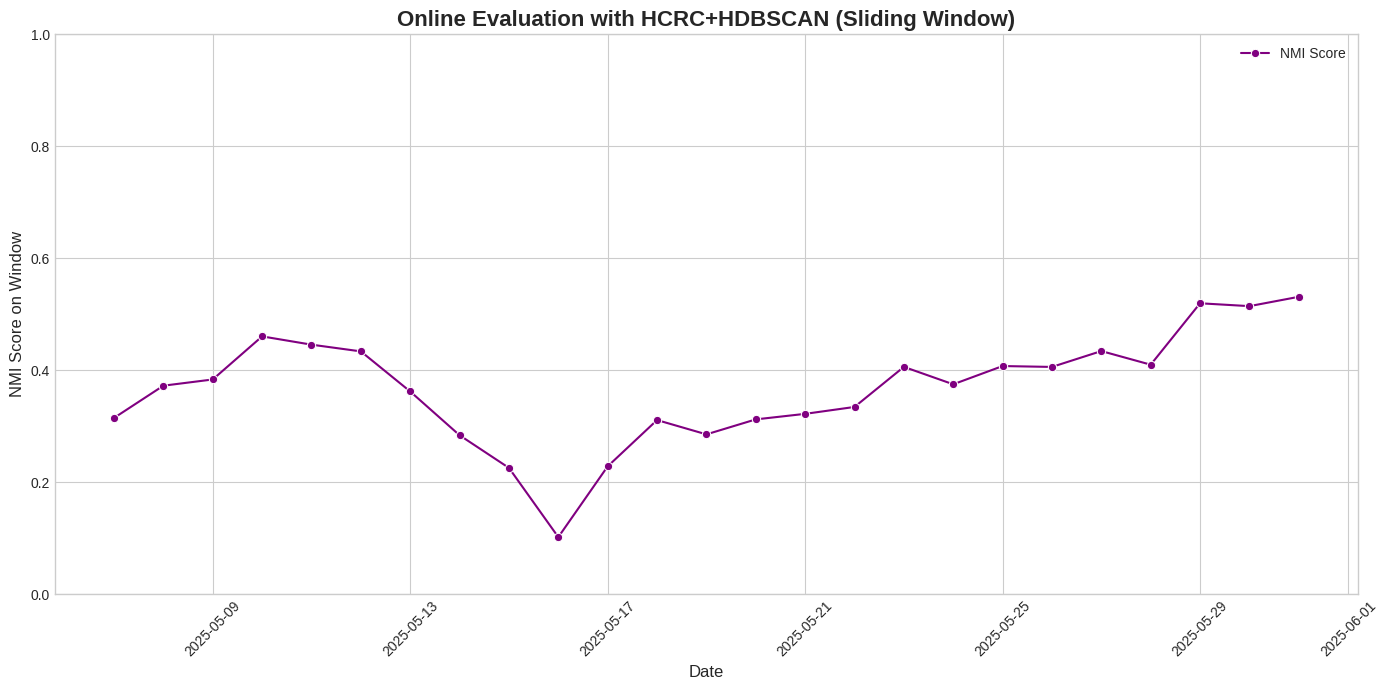

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_dbert_F.csv


In [ ]:
#@title Online Evaluation with HCRC + Full
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...")

# Define which embedding column to use
EMBEDDING_CHOICE = 'distilled_embeddings'

# Train models on the tuning set
args, unknown = parse_args()
# Pass the embedding_column parameter to the trainers
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
# Pass the embedding_column parameter to the inference functions
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)

hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function (No changes needed here) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is already correct and doesn't need changes)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                      min_samples=min_samples,
                                      metric='cosine',
                                      algorithm='generic',
                                      core_dist_n_jobs=-1)
            # predicted = clusterer.fit_predict(np.array(window_embeddings))
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 6
MIN_SAMPLES = 5
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_dbert_F")

🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 384

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----

CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 384

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 6064 rows...

Building node-level social network for message block 0...
Done! It takes 2 seconds.
   Graph-level inferenc

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:03<00:00,  6.95it/s]



🚀 Step 3: Plotting the NMI results...


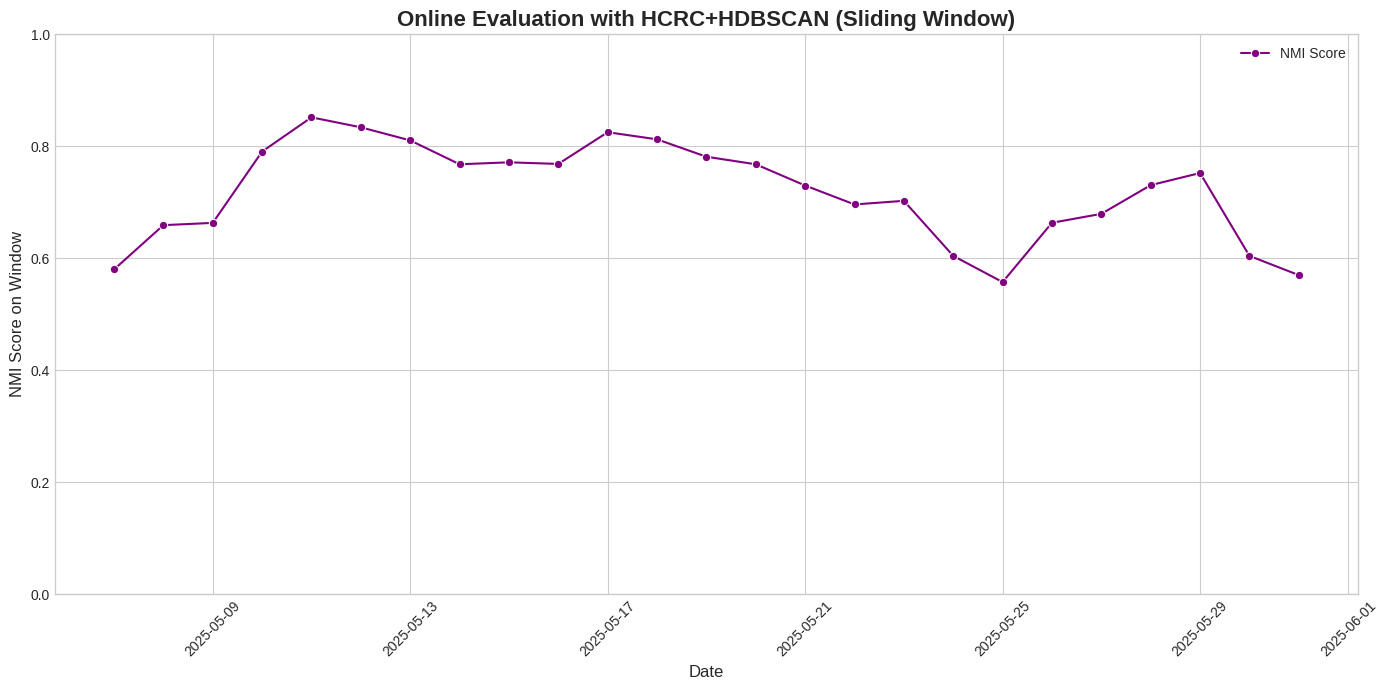

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_dbert_G.csv


In [ ]:
#@title Online Evaluation with HCRC  only graph
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
from hdbscan import HDBSCAN
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# --- 1. Prerequisite: Train HCRC Model and Generate Hybrid Embeddings ---
print("🚀 Step 1: Preparing data by generating hybrid embeddings using M-BERT...")

# Define which embedding column to use
EMBEDDING_CHOICE = 'distilled_embeddings'

# Train models on the tuning set
args, unknown = parse_args()
# Pass the embedding_column parameter to the trainers
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")

# Generate embeddings for the TUNING set (to preload the window)
# Pass the embedding_column parameter to the inference functions
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)

hybrid_tune_embeddings = graph_tune_embeddings#np.concatenate((graph_tune_embeddings, node_tune_embeddings), axis=1)
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())

# Generate embeddings for the EVALUATION set
node_eval_embeddings, eval_true_labels = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
graph_eval_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
hybrid_eval_embeddings = graph_eval_embeddings#np.concatenate((graph_eval_embeddings, node_eval_embeddings), axis=1)
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print("✅ Hybrid embeddings generated for both tuning and evaluation sets.")


# --- 2. The Sliding Window Function (No changes needed here) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is already correct and doesn't need changes)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []

    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()

    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)

        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())

        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered:
            window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else:
            window_embeddings, window_labels, window_dates = [], [], []

        if len(window_embeddings) > window_size:
            window_embeddings = window_embeddings[-window_size:]
            window_labels = window_labels[-window_size:]
            window_dates = window_dates[-window_size:]

        if len(set(window_labels)) > 1:
            clusterer = HDBSCAN(min_cluster_size=min_cluster_size,
                                      min_samples=min_samples,
                                      metric='cosine',
                                      algorithm='generic',
                                      core_dist_n_jobs=-1)
            # predicted = clusterer.fit_predict(np.array(window_embeddings))
            embedding_matrix = np.array(window_embeddings).astype(np.float64)
            predicted = clusterer.fit_predict(embedding_matrix)

            if len(set(predicted)) > 1:
                nmi = normalized_mutual_info_score(window_labels, predicted)
                ari = adjusted_rand_score(window_labels, predicted)
                ami = adjusted_mutual_info_score(window_labels, predicted)
            else:
                nmi, ari, ami = 0.0, 0.0, 0.0
        else:
            nmi, ari, ami = 0.0, 0.0, 0.0

        results.append({'date': date, 'nmi': nmi, 'ari': ari, 'ami': ami})
    return pd.DataFrame(results)

# --- 3. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")

daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 6
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')

    plt.title('Online Evaluation with HCRC+HDBSCAN (Sliding Window)', fontsize=16, weight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NMI Score on Window', fontsize=12)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_dbert_G")

🚀 Step 1: Preparing data...

Training Graph-Level model using 'distilled_embeddings'...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 384

Building node-level social network for message block 0...
Done! It takes 1 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ Graph model trained.

Applying trained model to the tuning set...
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
Reducing tuning T-BERT dimension from 384 to 256...

Applying trained model to the evaluation set...
   Graph-level inference running on 6064 rows...

Building graph-level social network for message block 0...
Done! It takes 3 seconds.
Reducing evaluation T-BERT dimension from 384 to 256...
✅ Hybrid embeddings created with shape: (6064, 384)

🚀 Step 2: Running online evaluation with a sliding window...


Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:07<00:00,  3.32it/s]



🚀 Step 3: Plotting the NMI results...


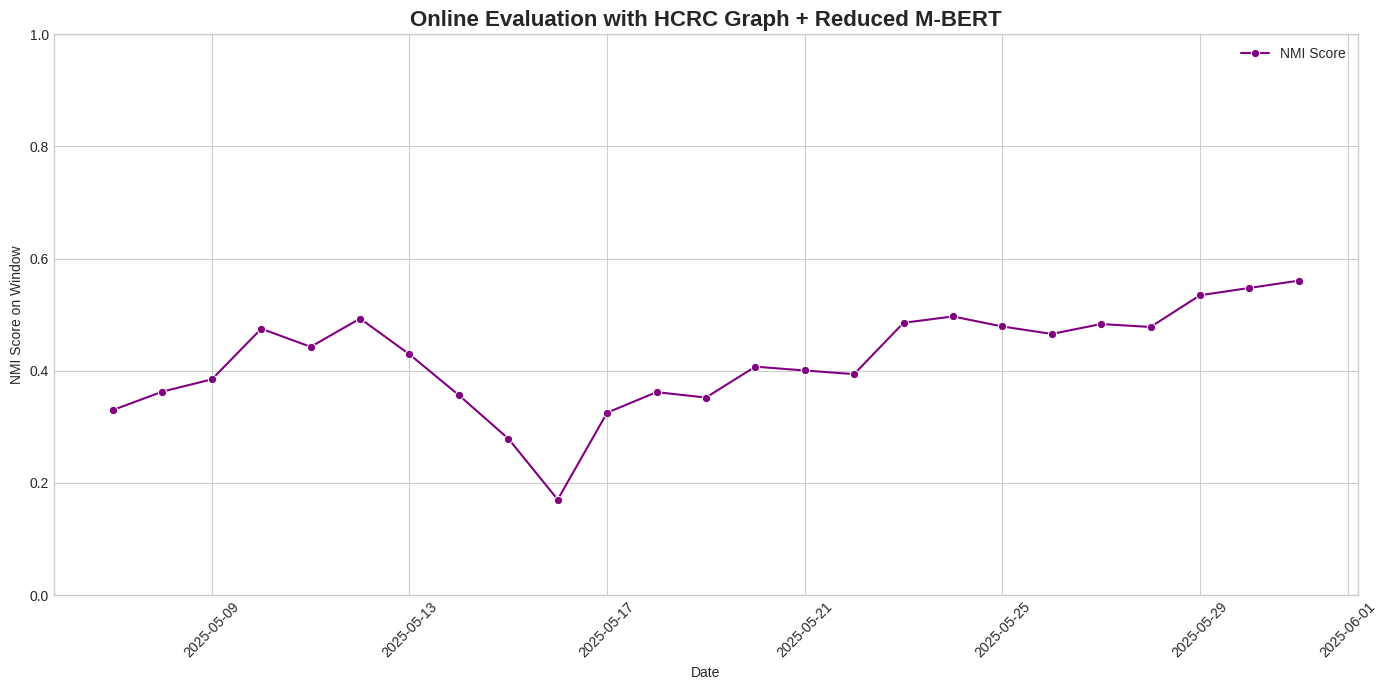

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_dbert_GT.csv


In [ ]:
#@title Online Evaluation with HCRC Graph Level + Reduced distill-BERT
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

# --- 1. Train Model and Generate Embeddings ---
print("🚀 Step 1: Preparing data...")

# Define which embedding column to use as the base feature
EMBEDDING_CHOICE = 'distilled_embeddings'

# Train only the Graph-Level model on the tuning set
args, unknown = parse_args()
print(f"\nTraining Graph-Level model using '{EMBEDDING_CHOICE}'...")
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ Graph model trained.")

# --- 2. Generate Embeddings for the TUNING set ---
print("\nApplying trained model to the tuning set...")
# Get Graph GNN output
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
# Get the raw T-BERT embeddings
tbert_tune_embeddings = np.vstack(tuning_df[EMBEDDING_CHOICE].values)
# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing tuning T-BERT dimension from {tbert_tune_embeddings.shape[1]} to 256...")
pca = PCA(n_components=128, random_state=42)
reduced_tbert_tune_embeddings = pca.fit_transform(tbert_tune_embeddings)
# Concatenate them
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, reduced_tbert_tune_embeddings), axis=1)
# Add to the tuning dataframe
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())


# --- 3. Generate Embeddings for the EVALUATION set ---
print("\nApplying trained model to the evaluation set...")
# Get Graph GNN output
graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
# Get the raw T-BERT embeddings
tbert_eval_embeddings = np.vstack(evaluation_df[EMBEDDING_CHOICE].values)
# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing evaluation T-BERT dimension from {tbert_eval_embeddings.shape[1]} to 256...")
# IMPORTANT: Use the SAME pca object trained on the tuning data
reduced_tbert_eval_embeddings = pca.transform(tbert_eval_embeddings)
# Concatenate them
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, reduced_tbert_eval_embeddings), axis=1)
# Add to the evaluation dataframe
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels

print(f"✅ Hybrid embeddings created with shape: {hybrid_eval_embeddings.shape}")


# --- 4. The Sliding Window Function (No changes needed) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is correct)
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='cosine',algorithm='generic', core_dist_n_jobs=-1)
            predicted_labels = clusterer.fit_predict(np.array(window_embeddings).astype(np.float64))
            nmi = normalized_mutual_info_score(window_labels, predicted_labels) if len(set(predicted_labels)) > 1 else 0.0
        else: nmi = 0.0
        results.append({'date': date, 'nmi': nmi})
    return pd.DataFrame(results)


# --- 5. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 6
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')
    plt.title('Online Evaluation with HCRC Graph + Reduced M-BERT', fontsize=16, weight='bold')
    plt.xlabel('Date')
    plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_dbert_GT")

🚀 Step 1: Training HCRC models...

Training Node-Level model using 'distilled_embeddings'...
CUDA not available, using cpu
Detected Node-Level input embedding dimension: 384

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
----Node-Level Training Start! ----


----Node-Level Training Done! ----


Training Graph-Level model using 'distilled_embeddings'...
CUDA not available, using cpu
Detected Graph-Level input embedding dimension: 384

Building node-level social network for message block 0...
Done! It takes 0 seconds.
----Graph-Level Training Start! ----


----Graph-Level Training Done! ----
✅ All models trained.

Applying trained models to the tuning set...
   Graph-level inference running on 934 rows...

Building graph-level social network for message block 0...
Done! It takes 0 seconds.
   Node-level inference running on 934 rows...

Building node-level social network for message block 0...
Done! It takes 0 seconds.
Reducing tuning M-BERT dimensi

Running HDBSCAN Sliding Window: 100%|██████████| 25/25 [00:03<00:00,  6.44it/s]



🚀 Step 3: Plotting the NMI results...


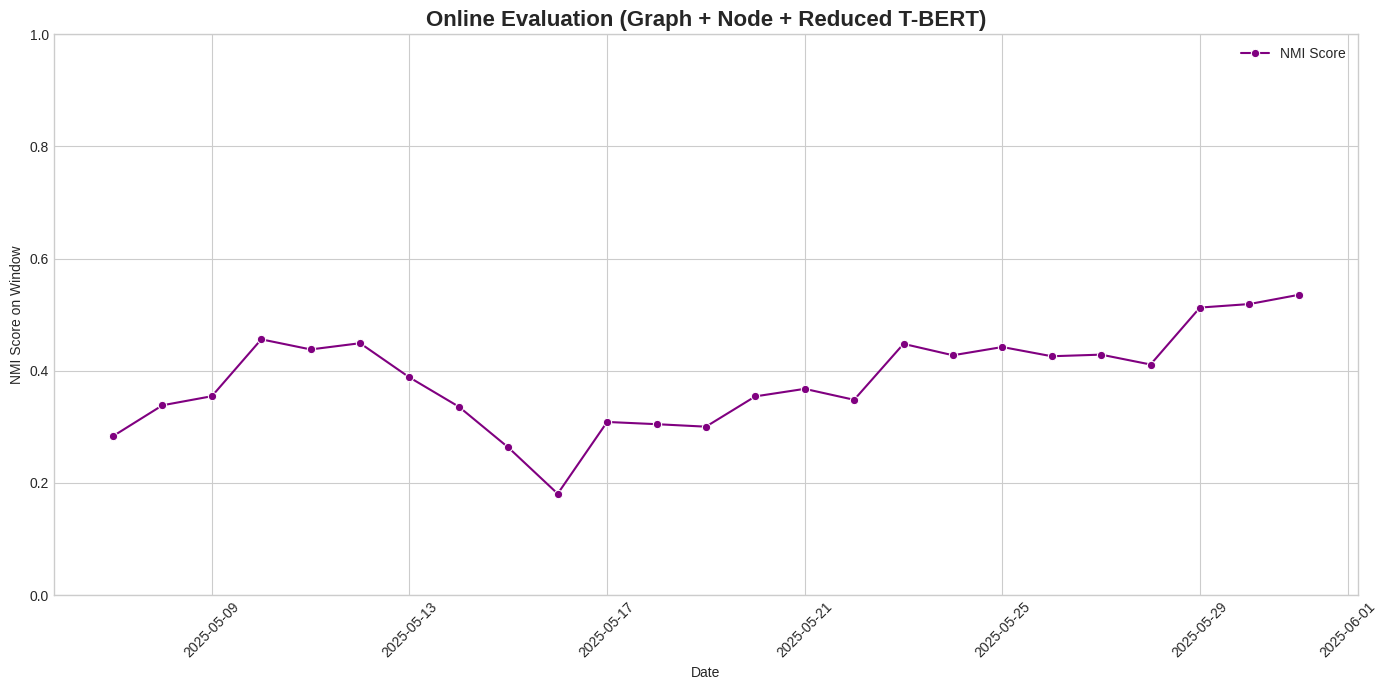

Results saved to drive/MyDrive/results/HCRC_HDBSCAN_dbert_NGT.csv


In [ ]:
#@title Online Evaluation with HCRC (Node + Graph + Reduced distilli-BERT)
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta
import hdbscan
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

# --- 1. Train Both HCRC Models ---
print("🚀 Step 1: Training HCRC models...")

# Define which embedding column to use as the base feature
EMBEDDING_CHOICE = 'distilled_embeddings'
args, unknown = parse_args()

# --- Re-enabled Node-Level model training ---
print(f"\nTraining Node-Level model using '{EMBEDDING_CHOICE}'...")
trainer_N = Node_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_node_model = trainer_N._model

print(f"\nTraining Graph-Level model using '{EMBEDDING_CHOICE}'...")
trainer_G = Graph_ModelTrainer(args, 0, tuning_df, embedding_column=EMBEDDING_CHOICE)
trained_graph_model = trainer_G._model
print("✅ All models trained.")


# --- 2. Generate and Combine Embeddings for the TUNING Set ---
print("\nApplying trained models to the tuning set...")
# --- Generate all THREE embedding components ---
graph_tune_embeddings, _ = get_graph_embeddings_from_trained_model(trained_graph_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
node_tune_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, tuning_df, embedding_column=EMBEDDING_CHOICE)
tbert_tune_embeddings = np.vstack(tuning_df[EMBEDDING_CHOICE].values)

# Reduce T-BERT embeddings dimension with PCA
print(f"Reducing tuning M-BERT dimension from {tbert_tune_embeddings.shape[1]} to 256...")
pca = PCA(n_components=256, random_state=42)
reduced_tbert_tune_embeddings = pca.fit_transform(tbert_tune_embeddings)

# --- Concatenate all THREE components for the final vector ---
hybrid_tune_embeddings = np.concatenate((graph_tune_embeddings, node_tune_embeddings, reduced_tbert_tune_embeddings), axis=1)

# Add to the tuning dataframe
tuning_df_with_embs = tuning_df.copy()
tuning_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_tune_embeddings), p=2, dim=1).numpy())


# --- 3. Generate and Combine Embeddings for the EVALUATION Set ---
print("\nApplying trained models to the evaluation set...")
graph_eval_embeddings, eval_true_labels = get_graph_embeddings_from_trained_model(trained_graph_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
node_eval_embeddings, _ = get_node_embeddings_from_trained_model(trained_node_model, evaluation_df, embedding_column=EMBEDDING_CHOICE)
tbert_eval_embeddings = np.vstack(evaluation_df[EMBEDDING_CHOICE].values)
reduced_tbert_eval_embeddings = pca.transform(tbert_eval_embeddings) # Use the same PCA fit

# --- Concatenate all THREE components ---
hybrid_eval_embeddings = np.concatenate((graph_eval_embeddings, node_eval_embeddings, reduced_tbert_eval_embeddings), axis=1)

# Add to the evaluation dataframe
eval_df_with_embs = evaluation_df.copy()
eval_df_with_embs['hybrid_embedding'] = list(F.normalize(torch.tensor(hybrid_eval_embeddings), p=2, dim=1).numpy())
eval_df_with_embs['event_label'] = eval_true_labels
print(f"✅ Final hybrid embeddings created with shape: {hybrid_eval_embeddings.shape}")


# --- 4. The Sliding Window Function (No changes needed) ---
def run_hdbscan_sliding(daily_blocks, window_size, time_window_days,
                        min_cluster_size=15, min_samples=5,
                        initial_df=None,
                        embedding_column='hybrid_embedding'):
    # ... (This function is correct) ...
    window_embeddings, window_labels, window_dates = [], [], []
    results = []
    if initial_df is not None and not initial_df.empty:
        window_embeddings = list(np.vstack(initial_df[embedding_column].values))
        window_labels = list(initial_df['event_label'].values)
        window_dates = pd.to_datetime(initial_df['Date']).tolist()
    for date, block in tqdm(sorted(daily_blocks.items()), desc="Running HDBSCAN Sliding Window"):
        block_embeddings = np.vstack(block[embedding_column].values)
        window_embeddings.extend(block_embeddings)
        window_labels.extend(block['event_label'].values)
        window_dates.extend(pd.to_datetime(block['Date']).tolist())
        time_cutoff = pd.to_datetime(date) - timedelta(days=time_window_days)
        filtered = [(e, l, d) for e, l, d in zip(window_embeddings, window_labels, window_dates) if d >= time_cutoff]
        if filtered: window_embeddings, window_labels, window_dates = map(list, zip(*filtered))
        else: window_embeddings, window_labels, window_dates = [], [], []
        if len(window_embeddings) > window_size:
            window_embeddings, window_labels, window_dates = window_embeddings[-window_size:], window_labels[-window_size:], window_dates[-window_size:]
        if len(set(window_labels)) > 1:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='cosine',algorithm='generic', core_dist_n_jobs=-1)
            predicted_labels = clusterer.fit_predict(np.array(window_embeddings).astype(np.float64))
            nmi = normalized_mutual_info_score(window_labels, predicted_labels) if len(set(predicted_labels)) > 1 else 0.0
        else: nmi = 0.0
        results.append({'date': date, 'nmi': nmi})
    return pd.DataFrame(results)


# --- 5. Execute the Sliding Window Evaluation and Plot ---
print(f"\n🚀 Step 2: Running online evaluation with a sliding window...")
daily_blocks = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

# --- Parameters to Tune ---
MIN_CLUSTER_SIZE = 6
MIN_SAMPLES = 3
WINDOW_MAX_TWEETS = 1000
WINDOW_MAX_DAYS = 3
# -------------------------

results_df = run_hdbscan_sliding(
    daily_blocks=daily_blocks,
    initial_df=tuning_df_with_embs,
    embedding_column='hybrid_embedding',
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    window_size=WINDOW_MAX_TWEETS,
    time_window_days=WINDOW_MAX_DAYS
)

# Plot the results
if not results_df.empty:
    print("\n🚀 Step 3: Plotting the NMI results...")
    results_df['date'] = pd.to_datetime(results_df['date'])
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=results_df, x='date', y='nmi', marker='o', color='purple', label='NMI Score')
    plt.title('Online Evaluation (Graph + Node + Reduced T-BERT)', fontsize=16, weight='bold')
    plt.xlabel('Date')
    plt.ylabel('NMI Score on Window')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

save_results(results_df, model_name="drive/MyDrive/results/HCRC_HDBSCAN_dbert_NGT")

In [ ]:
#@title Interactive t-SNE for a Specific Day in the Sliding Window
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta, date
from sklearn.manifold import TSNE
import hdbscan
import plotly.express as px

def plot_interactive_tsne_for_sliding_window(
    date_to_plot,
    initial_df,
    daily_blocks,
    window_size,
    time_window_days,
    min_cluster_size,
    embedding_column='hybrid_embedding'
):
    """
    Reconstructs the sliding window for a specific date, runs HDBSCAN,
    and creates an interactive t-SNE plot.
    """
    print(f"🚀 Reconstructing sliding window for date: {date_to_plot}...")

    # --- 1. Reconstruct the window state for the chosen date ---
    window_df = initial_df.copy()

    # Add all blocks up to and including the target date
    for date_key, block in sorted(daily_blocks.items()):
        if date_key <= date_to_plot:
            window_df = pd.concat([window_df, block], ignore_index=True)
        else:
            break

    # Apply the time and size filters to get the exact window
    time_cutoff = pd.to_datetime(date_to_plot) - timedelta(days=time_window_days)
    window_df['Date'] = pd.to_datetime(window_df['Date'])
    window_df = window_df[window_df['Date'] >= time_cutoff]

    if len(window_df) > window_size:
        window_df = window_df.tail(window_size)

    if window_df.empty:
        print("❌ Window is empty for this date. Nothing to plot.")
        return

    print(f"✅ Window reconstructed with {len(window_df)} tweets.")

    # --- 2. Run HDBSCAN and t-SNE on the window ---
    embeddings = np.vstack(window_df[embedding_column].values)

    print("   Running HDBSCAN on the window...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='cosine',algorithm='generic', core_dist_n_jobs=-1)
    predicted_labels = clusterer.fit_predict(embeddings.astype(np.float64))

    print("   Running t-SNE (this may take a few minutes)...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
    tsne_projections = tsne.fit_transform(embeddings)

    # --- 3. Prepare data and create the interactive plot ---
    viz_df = pd.DataFrame({
        'tsne_x': tsne_projections[:, 0],
        'tsne_y': tsne_projections[:, 1],
        'tweet_text': window_df['Old Tweet Text'].values,
        'cluster_id': predicted_labels.astype(str)
    })

    print("\n🚀 Generating interactive plot...")
    fig = px.scatter(
        viz_df,
        x='tsne_x',
        y='tsne_y',
        color='cluster_id',
        hover_data={'tweet_text': True, 'tsne_x': False, 'tsne_y': False},
        title=f'Interactive t-SNE of Sliding Window on {date_to_plot}'
    )
    fig.update_layout(width=950, height=800, legend_title_text='Cluster ID')
    fig.show()

# --- Parameters for Visualization ---
# !!! CHOOSE THE DATE YOU WANT TO VISUALIZE HERE !!!
# It must be a date within your evaluation period.
DATE_TO_PLOT = date(2025, 5, 18)

# Use the same parameters as your online evaluation script
MIN_CLUSTER_SIZE_VIZ = 8
WINDOW_MAX_TWEETS_VIZ = 1000
WINDOW_MAX_DAYS_VIZ = 3

# --- Execute the Visualization ---
# This assumes 'tuning_df_with_embs' and 'eval_df_with_embs' are available
if 'tuning_df_with_embs' in locals() and 'eval_df_with_embs' in locals():
    daily_blocks_viz = dict(tuple(eval_df_with_embs.groupby(eval_df_with_embs['Date'].dt.date)))

    plot_interactive_tsne_for_sliding_window(
        date_to_plot=DATE_TO_PLOT,
        initial_df=tuning_df_with_embs,
        daily_blocks=daily_blocks_viz,
        window_size=WINDOW_MAX_TWEETS_VIZ,
        time_window_days=WINDOW_MAX_DAYS_VIZ,
        min_cluster_size=MIN_CLUSTER_SIZE_VIZ
    )
else:
    print("❌ Error: Please run the main evaluation script first to generate the necessary dataframes.")

🚀 Reconstructing sliding window for date: 2025-05-18...
✅ Window reconstructed with 509 tweets.
   Running HDBSCAN on the window...
   Running t-SNE (this may take a few minutes)...

🚀 Generating interactive plot...


## old

In [ ]:
#@title main_offline with fixed threshold
import torch
import gc
import torch.nn.functional as F
gc.collect()
torch.cuda.empty_cache()
import random
random.seed(0)
import numpy as np
np.random.seed(0)

def main_offline(df, fixed_threshold=0.7):
    """
    Run the model in an offline mode on the entire dataset with a fixed threshold.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        fixed_threshold (float): The fixed similarity threshold for SinglePass clustering.
    """
    args, unknown = parse_args()

    print("************Running in Offline Mode (Single Pass with Fixed Threshold)************")

    # Treat the entire dataset as a single block (block_num = 0)
    # Modify get_Node_Dataset and get_Graph_Dataset to accept df and message_number
    # Need to adjust the logic in getData within process.py to handle this single block correctly,
    # ensuring 'start' is 0 and 'tweet_sum' is the length of the df when message_number is 0
    # and M is adjusted or bypassed for this mode.
    # For now, let's assume get_Node_Dataset and get_Graph_Dataset are adapted
    # to handle block_num=0 meaning the whole dataset.

    # Node-level learning for the entire dataset
    # Pass df to the trainers
    embedder_N = Node_ModelTrainer(args, 0, df) # Pass df to Node_ModelTrainer
    Node_emb, label = embedder_N.get_embedding()
    del embedder_N # Release memory

    # Graph-level learning for the entire dataset
    # embedder_G = Graph_ModelTrainer(args, 0, df) # Pass df to Graph_ModelTrainer
    # Graph_emb, label = embedder_G.get_embedding()
    # del embedder_G # Release memory

    # Combining vectors
    # all_embeddings = np.concatenate((Graph_emb, Node_emb), axis=1)
    all_embeddings = Node_emb
    all_embeddings = torch.tensor(all_embeddings)
    all_embeddings = F.normalize(all_embeddings, dim=-1, p=2).detach().cpu().numpy()

    print(f"\nRunning SinglePass clustering with fixed threshold: {fixed_threshold:.2f}")

    # Apply SinglePass clustering to the entire dataset with the fixed threshold
    # flag=2 is for evaluation mode using previous labels (which is the ground truth here)
    # size = len(all_embeddings) to process all data in one go
    # pred_label = None initially as we are generating initial clusters
    sp_clusterer = SinglePass(sim_threshold=fixed_threshold,
                              data=all_embeddings,
                              flag=0, # Use flag 0 for initial clustering on entire data
                              label=label, # Use true labels for evaluation later
                              size=len(all_embeddings),
                              agent=None,
                              para=0,
                              sim_init=0,
                              sim=False)
    predicted_labels = sp_clusterer.cluster_result

    print("\nEvaluating results:")
    # Evaluate the clustering results using the true labels
    # Use the evaluate function, setting block_num to 0 and pred_label to None or a dummy
    # As evaluate might be structured for blocks, we might need a simplified evaluation here
    # Or modify evaluate to handle a single full dataset.
    # For simplicity, let's calculate scores directly
    try:
        nmi = normalized_mutual_info_score(label, predicted_labels, average_method='arithmetic')
        ami = adjusted_mutual_info_score(label, predicted_labels, average_method='arithmetic')
        ari = adjusted_rand_score(label, predicted_labels)

        print(f'** NMI: {nmi:.2f} **')
        print(f'** AMI: {ami:.2f} **')
        print(f'** ARI: {ari:.2f} **')

    except Exception as e:
        print(f"Error during evaluation: {e}")
        print("Could not compute evaluation metrics. This might happen if clustering resulted in a single cluster or no clusters.")

    print("\n************Offline Mode Finished!************")

# To run this offline mode, you would call:
# main_offline(df, fixed_threshold=0.7) # You can change the threshold

In [ ]:
main_offline(df, fixed_threshold=0.55) # You can change the threshold

************Running in Offline Mode (Single Pass with Fixed Threshold)************
CUDA not available, using cpu

Building node-level social network...
Done! It takes 0 seconds.

----Node-Level Training Start! ----


----Node-Level Training Done! ----


Running SinglePass clustering with fixed threshold: 0.55

Evaluating results:
** NMI: 0.17 **
** AMI: 0.04 **
** ARI: 0.01 **

************Offline Mode Finished!************


In [ ]:
def get_embeddings_from_trained_model(model, df_to_infer):
    """Applies a pre-trained GNN model to a dataframe to get embeddings."""
    print(f"   Inference running on {len(df_to_infer)} rows...")
    model.eval() # Ensure model is in evaluation mode

    # Prepare the dataset from the new dataframe
    # We use block_num=0 and the corrected getData to process the whole df
    dataloader, true_labels = get_Node_Dataset(0, df_to_infer)

    all_embeddings = []
    with torch.no_grad(): # Disable gradient calculations for inference
        for batch in dataloader:
            # The NodeLevel.forward pass returns (emb, loss). We only need emb.
            emb, _ = model(batch)
            all_embeddings.extend(emb)

    print(f"   Generated {len(all_embeddings)} embeddings.")
    return np.array(all_embeddings), np.array(true_labels)

print("\n🚀 Step 2: Generating embeddings for the evaluation dataset using the trained model...")

evaluation_df = evaluation_df_aug.copy()
eval_embeddings, eval_labels = get_embeddings_from_trained_model(trained_gnn_model, evaluation_df)

# Add the generated embeddings back to the dataframe
if len(eval_embeddings) == len(evaluation_df):
    evaluation_df['embedding'] = list(eval_embeddings)
    print("✅ Evaluation embeddings generated and added to the DataFrame.")
else:
    raise ValueError(f"Mismatch: {len(eval_embeddings)} embeddings for {len(evaluation_df)} rows. Check the getData fix.")


🚀 Step 2: Generating embeddings for the evaluation dataset using the trained model...


NameError: name 'trained_gnn_model' is not defined

In [ ]:
#@title DRL Utilities
import torch
import numpy as np

def make_transition(trans, *items):
    """Creates a transition dictionary for the replay buffer."""
    transition = {}
    for key, item in zip(trans, items):
        if isinstance(item, list):
            item = torch.stack(item)
            transition[key] = item
        elif isinstance(item, np.ndarray):
            item = torch.from_numpy(item)
            transition[key] = item
        elif isinstance(item, torch.Tensor):
            transition[key] = item
        else:
            transition[key] = torch.Tensor([item])
    return transition

def calculate_nature_cnn_out_dim(height, weight):
    """Calculates the output dimension of a Nature-style CNN."""
    size_h = np.floor((height - 8) / 4) + 1
    size_h = np.floor((size_h - 4) / 2) + 1
    size_h = np.floor((size_h - 3) / 1) + 1
    size_w = np.floor((weight - 8) / 4) + 1
    size_w = np.floor((size_w - 4) / 2) + 1
    size_w = np.floor((size_w - 3) / 1) + 1
    return size_h, size_w

In [ ]:
#@title PPO Agent Implementation
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.distributions import Categorical, MultivariateNormal

# --- Placeholder for the missing BaseBuffer class ---
class BaseBuffer:
    def __init__(self, trans, max_size):
        self.trans = trans
        self.max_size = max_size
        self.buffer = []
    def add(self, transition):
        if len(self.buffer) >= self.max_size:
            self.buffer.pop(0)
        self.buffer.append(transition)
    def get_data(self):
        data = {key: [] for key in self.trans}
        for transition in self.buffer:
            for key, item in transition.items():
                data[key].append(item)
        return data, len(self.buffer)
    def clear(self):
        self.buffer = []
    def __len__(self):
        return len(self.buffer)

# --- Network Components ---
class MLPEncoder(nn.Module):
    def __init__(self, state_dim, layer_dim: list, feature_dim: int):
        super(MLPEncoder, self).__init__()
        layers = [nn.Linear(state_dim, layer_dim[0]), nn.ReLU(inplace=True)]
        for i in range(len(layer_dim) - 1):
            layers.append(nn.Linear(layer_dim[i], layer_dim[i + 1]))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Linear(layer_dim[-1], feature_dim, bias=False))
        self.encoder = nn.Sequential(*layers)
        self.out_dim = feature_dim
    def forward(self, x):
        return self.encoder(x)
    def get_dim(self):
        return self.out_dim

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, actor_layer, critic_layer, encoder=None, encoder_layer=None,
                 feature_dim=None, continuous=False, std_init=0.6):
        super(ActorCritic, self).__init__()
        self.continuous = continuous
        if continuous:
            self.action_var = torch.full((action_dim,), std_init * std_init)
        self.encoder = encoder
        if encoder is None:
            input_dim = state_dim
        elif encoder == "mlp":
            self.encoder = MLPEncoder(state_dim, encoder_layer, feature_dim)
            input_dim = self.encoder.get_dim()
        else:
            raise NotImplementedError
        if self.continuous:
            layers = [nn.Linear(input_dim, actor_layer[0]), nn.ReLU(inplace=True)]
            for i in range(len(actor_layer) - 1):
                layers.append(nn.Linear(actor_layer[i], actor_layer[i + 1]))
                layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Linear(actor_layer[-1], action_dim))
            self.actor = nn.Sequential(*layers)
        else:
            layers = [nn.Linear(input_dim, actor_layer[0]), nn.ReLU(inplace=True)]
            for i in range(len(actor_layer) - 1):
                layers.append(nn.Linear(actor_layer[i], actor_layer[i + 1]))
                layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Linear(actor_layer[-1], action_dim))
            layers.append(nn.Softmax(dim=-1))
            self.actor = nn.Sequential(*layers)
        layers = [nn.Linear(input_dim, critic_layer[0]), nn.ReLU(inplace=True)]
        for i in range(len(critic_layer) - 1):
            layers.append(nn.Linear(critic_layer[i], critic_layer[i + 1]))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Linear(critic_layer[-1], 1))
        self.critic = nn.Sequential(*layers)
        self.__network_init()
    def __network_init(self):
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight)
                if layer.bias is not None:
                    layer.bias.data.zero_()
    def act(self, state):
        if self.encoder is not None:
            state = self.encoder(state)
        if self.continuous:
            mu = self.actor(state)
            cov_mat = torch.diag(self.action_var).to(state.device)
            dist = MultivariateNormal(mu, cov_mat)
        else:
            action_prob = self.actor(state)
            dist = Categorical(action_prob)
        action = dist.sample()
        action_log_prob = dist.log_prob(action)
        return action.detach(), action_log_prob.detach()
    def evaluate(self, state, action):
        if self.encoder is not None:
            state = self.encoder(state)
        if self.continuous:
            mu = self.actor(state)
            action_var = self.action_var.expand_as(mu).to(state.device)
            cov_mat = torch.diag_embed(action_var)
            dist = MultivariateNormal(mu, cov_mat)
        else:
            action_prob = self.actor(state)
            dist = Categorical(action_prob)
        action_log_prob = dist.log_prob(action)
        dist_entropy = dist.entropy()
        value = self.critic(state)
        return action_log_prob, value, dist_entropy

# --- Main PPO Agent Class ---
class PPO_Config:
    def __init__(self):
        self.max_buffer = 1024
        self.use_cuda = torch.cuda.is_available()
        self.trans = ["state", "action", "reward", "next_state", "done", "log_prob"]
        self.lr = 0.0003
        self.gamma = 0.99
        self.train_epoch = 80
        self.clip_ratio = 0.2
        self.actor_layer = [64, 64]
        self.critic_layer = [64, 64]
        self.encoder = "mlp"
        self.encoder_layer = [128, 64]
        self.feature_dim = 64
        self.action_std_init = 0.6

class PPO:
    def __init__(self, state_dim, action_dim, continuous=True, args=None):
        if args is None:
            self.args = PPO_Config()
        self.buffer = BaseBuffer(self.args.trans, self.args.max_buffer)
        self.model = ActorCritic(state_dim[0], action_dim, self.args.actor_layer, self.args.critic_layer,
                                 self.args.encoder, self.args.encoder_layer, self.args.feature_dim, continuous,
                                 self.args.action_std_init)
        if self.args.use_cuda:
            self.model = self.model.cuda()
        self.model.eval()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.args.lr)
    def select_action(self, state):
        state = torch.Tensor(state).float()
        if self.args.use_cuda:
            state = state.cuda()
        action, action_log_prob = self.model.act(state)
        return action.detach().cpu(), action_log_prob.detach().cpu()
    def add_buffer(self, transition):
        self.buffer.add(transition)
    def learn(self):
        self.model.train()
        data, size = self.buffer.get_data()
        states = data["state"]
        actions = data["action"]
        rewards = data["reward"]
        dones = data["done"]
        old_log_probs = data["log_prob"]
        returns = []
        discounted_reward = 0
        for reward, done in zip(reversed(rewards), reversed(dones)):
            if done:
                discounted_reward = 0
            discounted_reward = reward + (self.args.gamma * discounted_reward)
            returns.insert(0, discounted_reward)
        returns = torch.tensor(returns, dtype=torch.float32)
        returns = (returns - returns.mean()) / (returns.std() + 1e-7)
        states = torch.stack(states).float()
        actions = torch.stack(actions)
        old_log_probs = torch.stack(old_log_probs)
        if self.args.use_cuda:
            states, actions, old_log_probs, returns = states.cuda(), actions.cuda(), old_log_probs.cuda(), returns.cuda()
        for _ in range(self.args.train_epoch):
            log_probs, values, dist_entropy = self.model.evaluate(states, actions)
            values = values.squeeze(-1)
            ratios = torch.exp(log_probs - old_log_probs.detach())
            advantages = returns - values.detach()
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.args.clip_ratio, 1 + self.args.clip_ratio) * advantages
            actor_loss = -torch.min(surr1, surr2)
            critic_loss = nn.MSELoss()(values, returns)
            loss = actor_loss + 0.5 * critic_loss - 0.01 * dist_entropy
            self.optimizer.zero_grad()
            loss.mean().backward()
            self.optimizer.step()
        self.model.eval()
        self.buffer.clear()

In [ ]:
#@title DRL Training for DBSCAN Threshold
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.cluster import DBSCAN
import numpy as np
from tqdm import tqdm

# --- 1. Define the DRL Environment ---
def get_dbscan_state(embeddings, labels):
    """Calculates a state vector describing the clustering quality."""
    core_samples_mask = (labels != -1)
    if len(set(labels[core_samples_mask])) > 1:
        s_score = silhouette_score(embeddings[core_samples_mask], labels[core_samples_mask])
    else:
        s_score = 0.0
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.sum(labels == -1) / len(labels) if len(labels) > 0 else 1.0
    return np.array([s_score, num_clusters, noise_ratio])

def get_dbscan_reward(embeddings, labels):
    """Calculates the reward for a clustering result."""
    if len(set(labels)) > 1:
        return calinski_harabasz_score(embeddings, labels)
    else:
        return 0.0

# --- 2. The Training Loop ---
if 'final_hybrid_embeddings' not in locals():
    print("❌ Error: Please generate embeddings first and store them in 'final_hybrid_embeddings'")
else:
    embeddings = final_hybrid_embeddings
    STATE_DIM = 3
    ACTION_DIM = 1
    CONTINUOUS = True

    agent = PPO(state_dim=[STATE_DIM], action_dim=ACTION_DIM, continuous=CONTINUOUS)

    NUM_EPISODES = 100
    best_reward = -np.inf
    best_eps = 0.0

    print(f"🚀 Starting DRL training for {NUM_EPISODES} episodes...")

    initial_labels = DBSCAN(eps=0.5, min_samples=15).fit_predict(embeddings)
    state = get_dbscan_state(embeddings, initial_labels)

    for episode in tqdm(range(NUM_EPISODES)):
        raw_action, log_prob = agent.select_action(state)

        # Scale the raw action to a valid 'eps' range [0.1, 1.5]
        chosen_eps = 0.1 + (raw_action.item() + 1) * 0.7

        labels = DBSCAN(eps=chosen_eps, min_samples=15, n_jobs=-1).fit_predict(embeddings)

        reward = get_dbscan_reward(embeddings, labels)
        next_state = get_dbscan_state(embeddings, labels)

        transition = make_transition(agent.args.trans, state, raw_action, reward, next_state, False, log_prob)
        agent.add_buffer(transition)

        if len(agent.buffer) >= agent.args.max_buffer:
            agent.learn()

        state = next_state

        if reward > best_reward:
            best_reward = reward
            best_eps = chosen_eps

    print("\n" + "="*40)
    print("🏆 DRL Training Finished!")
    print(f"   The agent learned the best eps to be: {best_eps:.4f}")
    print(f"   This resulted in a max reward (Calinski-Harabasz Score) of: {best_reward:.2f}")
    print("="*40)

❌ Error: Please generate embeddings first and store them in 'final_hybrid_embeddings'


In [ ]:
#@title DRL Training, Plotting, and Comparison
from sklearn.metrics import silhouette_score, calinski_harabasz_score, normalized_mutual_info_score
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define the DRL Environment (Same as before) ---
def get_dbscan_state(embeddings, labels):
    core_samples_mask = (labels != -1)
    if len(set(labels[core_samples_mask])) > 1:
        s_score = silhouette_score(embeddings[core_samples_mask], labels[core_samples_mask])
    else:
        s_score = 0.0
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.sum(labels == -1) / len(labels) if len(labels) > 0 else 1.0
    return np.array([s_score, num_clusters, noise_ratio])

def get_dbscan_reward(embeddings, labels):
    if len(set(labels)) > 1:
        return calinski_harabasz_score(embeddings, labels)
    else:
        return 0.0

# --- 2. The Training Loop (Updated to store history) ---
if 'final_hybrid_embeddings' not in locals():
    print("❌ Error: Please generate embeddings first and store them in 'final_hybrid_embeddings'")
else:
    embeddings = final_hybrid_embeddings
    true_labels = final_true_labels # We need this for the final NMI comparison

    STATE_DIM, ACTION_DIM, CONTINUOUS = 3, 1, True
    agent = PPO(state_dim=[STATE_DIM], action_dim=ACTION_DIM, continuous=CONTINUOUS)

    NUM_EPISODES = 100
    best_reward, best_eps = -np.inf, 0.0

    # List to store the history of each episode for plotting
    history = []

    print(f"🚀 Starting DRL training for {NUM_EPISODES} episodes...")

    initial_labels = DBSCAN(eps=0.5, min_samples=15).fit_predict(embeddings)
    state = get_dbscan_state(embeddings, initial_labels)

    for episode in tqdm(range(NUM_EPISODES)):
        raw_action, log_prob = agent.select_action(state)
        chosen_eps = 0.1 + (raw_action.item() + 1) * 0.7
        labels = DBSCAN(eps=chosen_eps, min_samples=15, n_jobs=-1).fit_predict(embeddings)
        reward = get_dbscan_reward(embeddings, labels)
        next_state = get_dbscan_state(embeddings, labels)

        transition = make_transition(agent.args.trans, state, raw_action, reward, next_state, False, log_prob)
        agent.add_buffer(transition)

        if len(agent.buffer) >= agent.args.max_buffer:
            agent.learn()

        state = next_state

        history.append({'episode': episode, 'reward': reward, 'chosen_eps': chosen_eps})

        if reward > best_reward:
            best_reward = reward
            best_eps = chosen_eps

    print("\n✅ DRL Training Finished!")
    history_df = pd.DataFrame(history)

    # --- 3. Plot the Learning Process ---
    print("\n📊 Plotting Agent's Learning Progress...")
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # Plot 1: Reward per Episode
    sns.lineplot(data=history_df, x='episode', y='reward', ax=axes[0], label='Reward per Episode', color='royalblue', alpha=0.7)
    history_df['reward_ma'] = history_df['reward'].rolling(window=10).mean()
    sns.lineplot(data=history_df, x='episode', y='reward_ma', ax=axes[0], label='Moving Average (10 episodes)', color='orangered', linewidth=2)
    axes[0].set_title('Agent Reward Over Time', fontsize=16, weight='bold')
    axes[0].set_ylabel('Reward (Calinski-Harabasz Score)', fontsize=12)
    axes[0].legend()

    # Plot 2: Epsilon Chosen per Episode
    sns.scatterplot(data=history_df, x='episode', y='chosen_eps', ax=axes[1], color='forestgreen', alpha=0.6)
    axes[1].axhline(y=best_eps, color='red', linestyle='--', label=f'Best Eps Found ({best_eps:.3f})')
    axes[1].set_title('Epsilon (Action) Chosen by Agent Over Time', fontsize=16, weight='bold')
    axes[1].set_xlabel('Episode', fontsize=12)
    axes[1].set_ylabel('DBSCAN Epsilon', fontsize=12)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- 4. Compare Final NMI Scores to Prove Learning ---
    print("\n🏆 Comparing Final NMI Scores...")

    # DRL Agent's Result
    drl_labels = DBSCAN(eps=best_eps, min_samples=15, n_jobs=-1).fit_predict(embeddings)
    drl_nmi = normalized_mutual_info_score(true_labels, drl_labels)

    # Random Search Baseline
    random_search_results = []
    for _ in range(20): # Try 20 random eps values
        random_eps = np.random.uniform(0.1, 1.5)
        random_labels = DBSCAN(eps=random_eps, min_samples=15, n_jobs=-1).fit_predict(embeddings)
        random_reward = get_dbscan_reward(embeddings, random_labels)
        random_search_results.append({'eps': random_eps, 'reward': random_reward, 'labels': random_labels})

    best_random = max(random_search_results, key=lambda x: x['reward'])
    random_nmi = normalized_mutual_info_score(true_labels, best_random['labels'])

    # Fixed Default Baseline
    default_labels = DBSCAN(eps=0.7, min_samples=15, n_jobs=-1).fit_predict(embeddings)
    default_nmi = normalized_mutual_info_score(true_labels, default_labels)

    print("\n" + "="*50)
    print("         PERFORMANCE COMPARISON")
    print("="*50)
    print(f"DRL Agent        | NMI: {drl_nmi:.4f}  (using learned eps={best_eps:.3f})")
    print(f"Random Search    | NMI: {random_nmi:.4f}  (using best of 20 random eps={best_random['eps']:.3f})")
    print(f"Fixed Default    | NMI: {default_nmi:.4f}  (using fixed eps=0.7)")
    print("="*50)

In [ ]:
#@title Create Filtered Words Column
import nltk
from nltk.corpus import stopwords
import re

print("Preparing to create the 'filtered_words' column...")

# --- Step 1: Download and prepare the stop words lists ---
try:
    # Check if stopwords are already downloaded
    stopwords.words('arabic')
    stopwords.words('english')
    print("✅ Stopwords already available.")
except LookupError:
    # Download them if not found
    print("Downloading stopwords from NLTK...")
    nltk.download('stopwords')
    print("✅ Stopwords downloaded.")

# Create a combined set of Arabic and English stop words for efficient lookup
arabic_stopwords = set(stopwords.words('arabic'))
english_stopwords = set(stopwords.words('english'))
combined_stopwords = arabic_stopwords.union(english_stopwords)


# --- Step 2: Define the filtering function ---
def create_filtered_words(text, stopwords_set):
    """
    Takes a text string and returns a list of meaningful words
    after removing stop words and short tokens.
    """
    if not isinstance(text, str):
        return []

    # Simple tokenization by splitting on spaces
    words = text.split()

    # Use a list comprehension to filter out stop words and very short words
    filtered = [word for word in words if word.lower() not in stopwords_set and len(word) > 1]

    return filtered


# --- Step 3: Apply the function to your DataFrame ---
# This assumes your cleaned text is in the 'Tweet Text' column
if 'Tweet Text' in df.columns:
    print("\nApplying the filter to the 'Tweet Text' column...")
    df['filtered_words'] = df['Tweet Text'].apply(lambda text: create_filtered_words(text, combined_stopwords))

    print("\n✅ 'filtered_words' column successfully created.")
    # Display the first few rows to show the result
    print("Example of original text vs. filtered words:")
    print(df[['Tweet Text', 'filtered_words']].head().to_string())
else:
    print("❌ Error: 'Tweet Text' column not found in the dataframe.")